# Evaluating Early Clinical Indicators for 180-Day Mortality: A Comparative Analysis Using the SUPPORT2 Dataset
**AAI-500 Applied Statistics for AI | Final Team Project, Group 3**

---

This notebook contains the complete analysis pipeline for the project, organized into three parts:

1. Data Cleaning and Preparation
2. Exploratory Data Analysis
3. Model Development and Selection

**Dataset:** SUPPORT2, a random sample of patients from Phases I and II of the Study to Understand Prognoses Preferences Outcomes and Risks of Treatment (SUPPORT). Source: UCI Machine Learning Repository (Harrell, 2022).

**Reference:** Knaus, W. A., Harrell, F. E., Lynn, J., Goldman, L., Phillips, R. S., Connors, A. F., ... & Wagner, D. P. (1995). The SUPPORT prognostic model: Objective estimates of survival for seriously ill hospitalized adults. *Annals of Internal Medicine, 122*(3), 191-203.

---

**Data layers used throughout this notebook:**

| Layer | File | Description |
|---|---|---|
| Bronze | `support2_raw_complete.csv` | Raw download, no changes |
| Silver | `support2_cleaned.csv` | Cleaned and imputed; structural exclusions applied |
| Gold | `support2_model_features.csv` | Feature-selected; model-ready |

---

## Table of Contents

| Part | Title |
|---|---|
| [Part 1](#p1) | Data Cleaning and Preparation |
| [Part 2](#p2) | Exploratory Data Analysis |
| [Part 3](#p3) | Model Development |

# Part 1: Data Cleaning and Preparation <a id="p1"></a>
At completion of this part, a silver dataset is saved into **support2_cleaned.csv**

### Part 1 Table of Contents

| Section | Title |
|---|---|
| [Section 0](#p1-s0) | Setup & Imports |
| [Section 1](#p1-s1) | Load Data & Initial Inspection |
| [Section 2](#p1-s2) | Column Renaming |
| [Section 3](#p1-s3) | Target Variable |
| [Section 4](#p1-s4) | Data Type Casting |
| [Section 5](#p1-s5) | Missing Data Analysis |
| [Section 6](#p1-s6) | Feature Pruning |
| [Section 7](#p1-s7) | Zero-Value Treatment |
| [Section 8](#p1-s8) | Missing Data Imputation |
| [Section 9](#p1-s9) | Defining Feature, Outcome Separation, Leakage |
| [Section 10](#p1-s10) | Post-Cleaning Summary |
| [Section 11](#p1-s11) | Save Silver Dataset |

## Section 0: Setup & Imports <a id="p1-s0"></a>

In [46]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer

sys.path.append("../utils")
from dataset import get_project_root, load_csv

warnings.filterwarnings("ignore")

current = Path.cwd().resolve()

while current != current.parent:
    if (current / ".git").exists() or (current / "pyproject.toml").exists():
        project_root = current
        break
    current = current.parent

PROJ_ROOT = get_project_root()
OUTPUT_PATH = PROJ_ROOT / "data" / "support2_cleaned.csv"
print(f"Output path  : {OUTPUT_PATH}")

Output path  : C:\Users\mwee\Documents\USD-AAI\aai-500\final\usd-aai-500-final\data\support2_cleaned.csv


## Section 1: Load Data & Initial Inspection <a id="p1-s1"></a>

In [47]:
df_raw = load_csv("support2_raw_complete.csv")
print(f"Shape: {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns")
df_raw.head()

Shape: 9,105 rows  x  48 columns


,id,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0
2,3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0
3,4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0
4,5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0


In [48]:
df_raw.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        9105 non-null   int64  
 1   age       9105 non-null   float64
 2   death     9105 non-null   int64  
 3   sex       9105 non-null   str    
 4   hospdead  9105 non-null   int64  
 5   slos      9105 non-null   int64  
 6   d.time    9105 non-null   int64  
 7   dzgroup   9105 non-null   str    
 8   dzclass   9105 non-null   str    
 9   num.co    9105 non-null   int64  
 10  edu       7471 non-null   float64
 11  income    6123 non-null   str    
 12  scoma     9104 non-null   float64
 13  charges   8933 non-null   float64
 14  totcst    8217 non-null   float64
 15  totmcst   5630 non-null   float64
 16  avtisst   9023 non-null   float64
 17  race      9063 non-null   str    
 18  sps       9104 non-null   float64
 19  aps       9104 non-null   float64
 20  surv2m    9104 non-null   float64
 21  su

In [49]:
int_cols = df_raw.select_dtypes(include="int64").columns
binary_cols = [
    c
    for c in int_cols
    if df_raw[c].nunique() == 2 and set(df_raw[c].unique()) == {0, 1}
]
print("===========Binary Columns==========")
print(binary_cols)

===========Binary Columns==========
['death', 'hospdead', 'diabetes', 'dementia']


### 1.1 Descriptive Statistics

In [50]:
desc = df_raw.describe().T
desc.columns = [
    "Count",
    "Mean",
    "Std Dev",
    "Min",
    "Q1 (25%)",
    "Median (50%)",
    "Q3 (75%)",
    "Max",
]
desc

,Count,Mean,Std Dev,Min,Q1 (25%),Median (50%),Q3 (75%),Max
id,9105.0,4553.000000,2628.531434,1.000000,2277.000000,4553.000000,6829.000000,9.105000e+03
age,9105.0,62.650823,15.593710,18.041990,52.797000,64.856990,73.998960,1.018480e+02
death,9105.0,0.681054,0.466094,0.000000,0.000000,1.000000,1.000000,1.000000e+00
hospdead,9105.0,0.259198,0.438219,0.000000,0.000000,0.000000,1.000000,1.000000e+00
slos,9105.0,17.863042,22.006440,3.000000,6.000000,11.000000,20.000000,3.430000e+02
d.time,9105.0,478.449863,560.383272,3.000000,26.000000,233.000000,761.000000,2.029000e+03
num.co,9105.0,1.868644,1.344409,0.000000,1.000000,2.000000,3.000000,9.000000e+00
edu,7471.0,11.747691,3.447743,0.000000,10.000000,12.000000,14.000000,3.100000e+01
scoma,9104.0,12.058546,24.636694,0.000000,0.000000,0.000000,9.000000,1.000000e+02
charges,8933.0,59995.787811,102648.778198,1169.000000,9740.000000,25024.000000,64598.000000,1.435423e+06


## Section 2: Column Renaming <a id="p1-s2"></a>

Rename some columns to follow PEP-8 standard

In [51]:
rename_map = {
    "d.time": "d_time",
    "num.co": "num_co",
}
df = df_raw.rename(columns=rename_map).copy()

print("Column renames applied:")
for old, new in rename_map.items():
    print(f"  {old!r}  ->  {new!r}")
print(f"\nTotal columns: {len(df.columns)}")

Column renames applied:
  'd.time'  ->  'd_time'
  'num.co'  ->  'num_co'

Total columns: 48


## Section 3: Target Variable <a id="p1-s3"></a>

**Did the patient die within 180 days of study?**

To answer this we look at two fields:
- `death`: whether the patient ever died during 180 days (1 = yes, 0 = no)
- `d_time`: days of follow-up (how long they were observed). If this number is greater than 180 days of the trial, that means they survived the trial

death_180d (1 = yes, 0 = no) = {death=1 AND d_time <= 180}

Notice the AND conditional because the patient must've died within the 180 days to satisfy our target.
We then use **death_180d** for binary classification

In [52]:
df["death_180d"] = ((df["death"] == 1) & (df["d_time"] <= 180)).astype(int)

counts = df["death_180d"].value_counts()
rel_freqs = df["death_180d"].value_counts(normalize=True)

summary = pd.DataFrame(
    {
        "Outcome": ["Survived >= 180 days (0)", "Died within 180 days (1)"],
        "Frequency": counts.values,
        "Relative Frequency": rel_freqs,
        "Percentage (%)": (rel_freqs.values * 100),
    }
)
print(summary.to_string(index=False))
print(f"\nClass imbalance ratio (survived: died) = {counts[0] / counts[1]:.2f} : 1")

                 Outcome  Frequency  Relative Frequency  Percentage (%)
Survived >= 180 days (0)       4840            0.531576       53.157606
Died within 180 days (1)       4265            0.468424       46.842394

Class imbalance ratio (survived: died) = 1.13 : 1


## Section 4: Data Type Casting (into Pandas Type) <a id="p1-s4"></a>

Correct data types are essential for proper computing and modeling.
We apply three categories of correction. Casting to Int8 also handles NaN gracefully:

1. **Binary integer columns** -> `Int8` (nullable integer; memory-efficient)
2. **Nominal categorical columns** -> unordered `pd.Categorical`
3. **Ordinal categorical columns** -> ordered `pd.Categorical` for proper sorting and comparison

**`income` ordering (ascending socioeconomic status):**
`under $11k` < `$11-$25k` < `$25-$50k` < `>$50k`

Note: `sfdm2` is classified as a Target variable in the data dictionary (2-month functional disability, measured at follow-up rather than at day 3) and is dropped in Section 6. It is not cast here.

In [53]:
# Binary columns -> nullable Int8
binary_cols = ["death", "hospdead", "diabetes", "dementia"]
for col in binary_cols:
    df[col] = df[col].astype("Int8")

######  7 Categoricals
# sex = 2 levels
# dzgroup = 8 levels
# dzclass = 4 levels
# race = 6 levels
# income = 4 levels
# ca = 3 levels
# dnr = 3 levels
# Note: sfdm2 dropped in Section 6 (Target variable per data dictionary)
##############

# Nominal (unordered) categoricals
nominal_cats = ["sex", "dzgroup", "dzclass", "race", "ca", "dnr"]
for col in nominal_cats:
    df[col] = df[col].astype("category")

# Ordinal: income (lowest -> highest bracket) as coded in support2_data_dictionary.md
income_order = ["under $11k", "$11-$25k", "$25-$50k", ">$50k"]
df["income"] = pd.Categorical(df["income"], categories=income_order, ordered=True)

print("Data type corrections applied:\n")
cols_updated = binary_cols + nominal_cats + ["income"]
print(df[cols_updated].dtypes.to_string())

Data type corrections applied:

death           Int8
hospdead        Int8
diabetes        Int8
dementia        Int8
sex         category
dzgroup     category
dzclass     category
race        category
ca          category
dnr         category
income      category


## Section 5: Missing Data Analysis <a id="p1-s5"></a>

The authors have stated there are a maximum of 5641 N/As. This, along with every other missing data, we must verify and address.

In [54]:
missing_count = df.isnull().sum()
missing_percent = missing_count / len(df) * 100
missing_df = pd.DataFrame(
    {
        "Missing Count": missing_count,
        "Missing %": missing_percent,
    }
).sort_values("Missing Count", ascending=False)

missing_df = missing_df[missing_df["Missing Count"] > 0]

total_cells = df.shape[0] * df.shape[1]
total_missing = int(missing_df["Missing Count"].sum())

print(f"Columns with at least one missing value : {len(missing_df)}")
print(
    f"Total missing cells : {total_missing:,} / {total_cells:,}  ({total_missing / total_cells * 100:.1f}%)\n"
)
print(missing_df.to_string())

# verify maximum missing n/as
max_na = df_raw.isnull().sum().max()
max_na_col = df_raw.isnull().sum().idxmax()
print(f"Max NAs: {max_na} (column: '{max_na_col}')")
assert max_na == 5641, f"Expected 5641, got {max_na}"

Columns with at least one missing value : 33
Total missing cells : 47,110 / 446,145  (10.6%)

         Missing Count  Missing %
adlp              5641  61.954970
urine             4862  53.399231
glucose           4500  49.423394
bun               4352  47.797913
totmcst           3475  38.165843
alb               3372  37.034596
income            2982  32.751236
adls              2867  31.488193
bili              2601  28.566722
pafi              2325  25.535420
ph                2284  25.085118
prg2m             1649  18.110928
edu               1634  17.946183
prg6m             1633  17.935200
sfdm2             1400  15.376167
totcst             888   9.752883
wblc               212   2.328391
charges            172   1.889072
avtisst             82   0.900604
crea                67   0.735859
race                42   0.461285
dnrday              30   0.329489
dnr                 30   0.329489
sps                  1   0.010983
aps                  1   0.010983
sod                  1

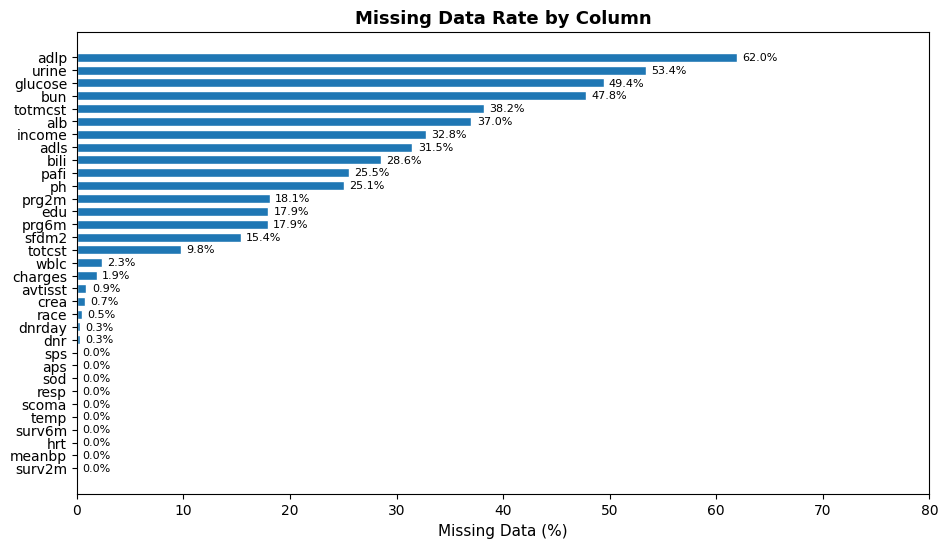

In [55]:
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    missing_df.index[::-1],
    missing_df["Missing %"][::-1],
    edgecolor="white",
    height=0.7,
)

ax.set_xlabel("Missing Data (%)", fontsize=11)
ax.set_title("Missing Data Rate by Column", fontsize=13, fontweight="bold")
ax.set_xlim(0, 80)

for bar, pct in zip(bars, missing_df["Missing %"][::-1]):
    if pct > 0:
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%",
            va="center",
            fontsize=8,
        )
plt.show()

### 5.1 Missing Data Decision Table

Here we decide how to tackle missing data: either drop the column entirely or impute mathematically.

For most of our biological features that have missing data, we compute the median. The reason is per Agresti et al. (2022), chapter 3, that for right-skewed data, using median instead of mean avoids pushing the skewness further toward the tail. Looking at Section 1, our columns show mean > median, which signals right skew.

Albumin is treated separately using KNN imputation (k=5). The standard domain fill value of 3.5 g/dL coincides with the Q3 boundary of the albumin distribution, which would collapse quartile bins and make albumin unusable as a stratification variable in interaction analysis. KNN imputation preserves realistic variation by borrowing from physiologically similar patients.

| Column(s) | Decision | Rationale |
|---|---|---|
| `adlp`, `adls` | Drop | Superseded by `adlsc` per original authors |
| `dnrday` | Drop | DNR order day; not relevant to mortality prediction |
| `sfdm2` | Drop | Classified as Target in data dictionary; measured at 2-month follow-up, not day 3 |
| `avtisst` | Drop | Average TISS days 3-25; spans the full observation period, downstream of outcome |
| `dnr` | Retained in Silver; excluded from Gold | Reflects care decisions rather than clinical or physiologic status at day 3; retained for EDA analysis in Part 2 |
| `alb` | KNN imputation (k=5) | Clinically important predictor; domain fill value collapses quartile distribution |
| `pafi`, `bili`, `crea`, `bun`, `wblc`, `urine` | Domain fill | Author-validated normal fill values available (Harrell, 2022) |
| `ph`, `glucose`, `scoma`, `edu`, `prg2m`, `prg6m` | Sample median | High missing rate |
| `surv2m`, `surv6m`, `aps`, `sps` | Sample median | Retained as benchmark columns |
| `meanbp`, `hrt`, `resp`, `temp`, `sod` | Sample median | Few missing values |
| `race`, `income` | Mode imputation | Most frequent category as best single-value estimate for categoricals |

#### Benchmark Columns (retained in Silver, excluded from Gold)

| Column | Role | Notes |
|---|---|---|
| `surv2m`, `surv6m` | SUPPORT model survival predictions | Retained for benchmark comparison |
| `aps` | APACHE III severity score | Independent benchmark system widely used in critical care |
| `sps` | SUPPORT physiology sub-score | Component of the SUPPORT model; excluded from model features to avoid circular prediction |
| `prg2m`, `prg6m` | Physician survival estimates | Retained for benchmark comparison |

## Section 6: Feature Pruning <a id="p1-s6"></a>

We remove features with structural disqualifications that do not require EDA to justify.

In [56]:
# adlp and adls are superseded by adlsc per the original study authors.
# dnrday records the day a DNR order was placed and is not relevant to mortality prediction.
# sfdm2 is classified as a Target variable in the data dictionary (2-month functional
# disability measured via patient and surrogate questionnaires after the observation
# period). It is dropped rather than cast to avoid confusion with day-3 features.
# avtisst records the average TISS score over days 3-25, spanning the full observation
# period and partially determined by post-enrollment clinical trajectory. It is
# downstream of the outcome and structurally invalid as a day-3 predictor.
# dnr is retained in Silver for EDA analysis (Section 8 of Part 2) and excluded
# from Gold features in EDA, as it reflects care decisions rather than clinical
# or physiologic status at day 3.

cols_to_drop = ["adlp", "adls", "dnrday", "sfdm2", "avtisst"]

df.drop(columns=cols_to_drop, inplace=True, errors="ignore")
print(f"Dropped  : {len(cols_to_drop)} columns")
print(f"Remaining: {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"Remaining columns ({df.shape[1]}):")
print(list(df.columns))

Dropped  : 5 columns
Remaining: 9,105 rows  x  44 columns
Remaining columns (44):
['id', 'age', 'death', 'sex', 'hospdead', 'slos', 'd_time', 'dzgroup', 'dzclass', 'num_co', 'edu', 'income', 'scoma', 'charges', 'totcst', 'totmcst', 'race', 'sps', 'aps', 'surv2m', 'surv6m', 'hday', 'diabetes', 'dementia', 'ca', 'prg2m', 'prg6m', 'dnr', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlsc', 'death_180d']


## Section 7: Zero-Value Treatment <a id="p1-s7"></a>

Many physiologic measurements in SUPPORT2 use `0` as a sentinel for a missing or invalid reading rather than a true value. A living patient cannot have a mean blood pressure, heart rate, or respiratory rate of exactly zero. We therefore treat zeros in these columns as missing (`NaN`) before imputation in Section 8, so each column is filled by the same clinically validated strategy already chosen for it.

Computing the median after removing these zeros also produces a more representative fill value, since the spurious zeros no longer drag the center downward.

Rows carrying a zero vital sign show a markedly higher death rate than the cohort average, and the zeros are spread across several variables rather than concentrated in one. This pattern is consistent with mixed measurement and recording artifacts in very sick patients rather than true readings, so imputing them rather than dropping the rows preserves sample size without fabricating implausible values.

### Columns where `0` is a legitimate value (left untouched)

| Column(s) | Why `0` is valid |
|---|---|
| `death`, `hospdead`, `diabetes`, `dementia` | Binary indicators (0 = no) |
| `num_co` | Count of comorbidities (0 = none) |
| `scoma` | SUPPORT coma score (0 = fully alert) |
| `adlsc` | ADL impairment score (0 = no impairment) |
| `aps`, `sps` | Severity scores (0 = minimal physiologic derangement) |
| `surv2m`, `surv6m`, `prg2m`, `prg6m` | Survival probabilities and estimates (0 = predicted death) |
| `death_180d` | Engineered binary target |

### Physiologic columns where `0` is invalid and converted to `NaN`

`meanbp`, `hrt`, `resp`, `temp`, `sod`, `ph`, `glucose`, `wblc`, `alb`, `bili`, `crea`, `bun`, `pafi`, `urine`

**Clinical note on `urine`:** sustained complete anuria can occur in acute renal failure, but a recorded daily output of exactly zero is far more often a recording artifact. Treated as missing and filled with the SUPPORT normal fill value, consistent with the original authors' imputation convention.

In [57]:
ZERO_ALLOWED = [
    "death",
    "hospdead",
    "diabetes",
    "dementia",
    "num_co",
    "scoma",
    "adlsc",
    "aps",
    "sps",
    "surv2m",
    "surv6m",
    "prg2m",
    "prg6m",
    "death_180d",
    # Administrative and weak-signal columns: 0 is a legitimate value
    "totcst",
    "totmcst",
    "edu",
]

ZERO_INVALID = [
    "meanbp",
    "hrt",
    "resp",
    "temp",
    "sod",
    "ph",
    "glucose",
    "wblc",
    "alb",
    "bili",
    "crea",
    "bun",
    "pafi",
    "urine",
]

# Scan: every numeric column that currently holds a zero
zero_log = []
for col in df.select_dtypes(include=["number"]).columns:
    n_zero = int((df[col] == 0).sum())
    if n_zero == 0:
        continue
    if col in ZERO_INVALID:
        treatment = "-> NaN"
    elif col in ZERO_ALLOWED:
        treatment = "allowed"
    else:
        treatment = "UNCLASSIFIED"
    zero_log.append(
        {
            "Column": col,
            "Zeros": n_zero,
            "Zero %": round(n_zero / len(df) * 100, 2),
            "Treatment": treatment,
        }
    )

zero_scan = pd.DataFrame(zero_log).sort_values("Zeros", ascending=False)
print("Zero-value scan (numeric columns containing at least one zero):\n")
print(zero_scan.to_string(index=False))

# Guard: any numeric column with zeros must be explicitly classified
unclassified = zero_scan.loc[
    zero_scan["Treatment"] == "UNCLASSIFIED", "Column"
].tolist()
assert not unclassified, f"Unclassified zero columns: {unclassified}"

total_converted = 0
for col in ZERO_INVALID:
    if col not in df.columns:
        continue
    n_zero = int((df[col] == 0).sum())
    if n_zero > 0:
        df[col] = df[col].replace(0, np.nan)
        total_converted += n_zero
        print(f"  {col:<8}: {n_zero:>3} zeros -> NaN")

print(f"\nTotal zeros converted to NaN: {total_converted}")

Zero-value scan (numeric columns containing at least one zero):

    Column  Zeros  Zero % Treatment
  dementia   8809   96.75   allowed
  diabetes   7327   80.47   allowed
  hospdead   6745   74.08   allowed
     scoma   6401   70.30   allowed
death_180d   4840   53.16   allowed
     adlsc   3108   34.14   allowed
     death   2904   31.89   allowed
    num_co   1177   12.93   allowed
     prg6m    346    3.80   allowed
     prg2m    215    2.36   allowed
    surv6m    202    2.22   allowed
    surv2m    139    1.53   allowed
   totmcst    102    1.12   allowed
     urine     93    1.02    -> NaN
       hrt     83    0.91    -> NaN
      resp     65    0.71    -> NaN
    meanbp     51    0.56    -> NaN
       edu     43    0.47   allowed
    totcst     17    0.19   allowed
      wblc     10    0.11    -> NaN
       aps      1    0.01   allowed
   glucose      1    0.01    -> NaN
  meanbp  :  51 zeros -> NaN
  hrt     :  83 zeros -> NaN
  resp    :  65 zeros -> NaN
  glucose :   1 zero

## Section 8: Missing Data Imputation <a id="p1-s8"></a>

The original SUPPORT study authors (Harrell, 2022) provide clinically validated **normal fill-in values** for six physiological variables (see docs/support2_dataset_description.md). Albumin is imputed separately using KNN as described in Section 5.1.

| Variable | Normal Fill | Meaning |
|---|---|---|
| `pafi`  | 333.3 | PaO2/FiO2 ratio - oxygen level |
| `bili`  | 1.01  | Bilirubin - liver function |
| `crea`  | 1.01  | Creatinine - renal function |
| `bun`   | 6.51  | BUN - normal renal function |
| `wblc`  | 9.0   | WBC count - immune status |
| `urine` | 2502  | Urine output - renal output |

In [58]:
# KNN imputation for albumin
# Rationale: albumin has ~37% missingness and is a clinically important mortality
# predictor (Knaus et al., 1995). The domain fill value of 3.5 coincides with
# the Q3 boundary, collapsing quartile bins and making albumin unusable as a
# stratification variable in interaction analysis. KNN imputation (k=5) preserves
# realistic variation by borrowing from physiologically similar patients rather
# than substituting a single normal value uniformly across all missing cases.
# Features used for neighbor calculation: age, meanbp, hrt, resp, temp, sod;
# these are variables with low missingness that capture overall physiologic status.

alb_features = ["alb", "age", "meanbp", "hrt", "resp", "temp", "sod"]
knn_imputer = KNNImputer(n_neighbors=5)

df_alb = df[alb_features].copy()
df_alb_imputed = pd.DataFrame(
    knn_imputer.fit_transform(df_alb), columns=alb_features, index=df.index
)
df["alb"] = df_alb_imputed["alb"]

# Verify
print(f"Albumin missing after KNN imputation: {df['alb'].isnull().sum()}")
print(df["alb"].describe().round(3))

Albumin missing after KNN imputation: 0
count    9105.000
mean        2.921
std         0.751
min         0.400
25%         2.440
50%         2.900
75%         3.340
max        29.000
Name: alb, dtype: float64


In [59]:
DOMAIN_FILL = {
    "pafi": 333.3,
    "bili": 1.01,
    "crea": 1.01,
    "bun": 6.51,
    "wblc": 9.0,
    "urine": 2502.0,
}

imputation_log = []

for k, v in DOMAIN_FILL.items():
    n_missing = int(df[k].isnull().sum())
    if n_missing > 0:
        df[k] = df[k].fillna(v)
        imputation_log.append(
            {
                "Column": k,
                "Strategy": "Domain Fill",
                "Fill Value": v,
                "Cells Filled": n_missing,
            }
        )

MEDIAN_COLS = [
    "sps",
    "meanbp",
    "hrt",
    "resp",
    "temp",
    "sod",
    "ph",
    "glucose",
    "scoma",
    "edu",
    "surv2m",
    "surv6m",
    "aps",
    "prg2m",
    "prg6m",
]
for k in MEDIAN_COLS:
    n_missing = int(df[k].isnull().sum())
    if n_missing > 0:
        med = float(df[k].median())
        df[k] = df[k].fillna(med)
        imputation_log.append(
            {
                "Column": k,
                "Strategy": "Sample Median",
                "Fill Value": round(med, 4),
                "Cells Filled": n_missing,
            }
        )

MODE_COLS = ["race", "income"]
for k in MODE_COLS:
    n_missing = int(df[k].isnull().sum())
    if n_missing > 0:
        mode_val = df[k].mode()[0]
        df[k] = df[k].fillna(mode_val)
        imputation_log.append(
            {
                "Column": k,
                "Strategy": "Sample Mode",
                "Fill Value": str(mode_val),
                "Cells Filled": n_missing,
            }
        )

log_df = pd.DataFrame(imputation_log)
print("Imputation Summary:")
print(log_df.to_string(index=False))
print(f"Total cells imputed: {log_df['Cells Filled'].sum():,}")

Imputation Summary:
 Column      Strategy Fill Value  Cells Filled
   pafi   Domain Fill      333.3          2325
   bili   Domain Fill       1.01          2601
   crea   Domain Fill       1.01            67
    bun   Domain Fill       6.51          4352
   wblc   Domain Fill        9.0           222
  urine   Domain Fill     2502.0          4955
    sps Sample Median    23.8984             1
 meanbp Sample Median       78.0            52
    hrt Sample Median      100.0            84
   resp Sample Median       24.0            66
   temp Sample Median    36.6953             1
    sod Sample Median      137.0             1
     ph Sample Median     7.4199          2284
glucose Sample Median      135.0          4501
  scoma Sample Median        0.0             1
    edu Sample Median       12.0          1634
 surv2m Sample Median     0.7159             1
 surv6m Sample Median      0.575             1
    aps Sample Median       34.0             1
  prg2m Sample Median        0.7        

In [60]:
remaining_na = df.isnull().sum()
remaining_na = remaining_na[remaining_na > 0]

EXPECTED_REMAINING = ["charges", "totcst", "totmcst", "dnr"]

if len(remaining_na) == 0:
    print("Imputation complete, zero missing values remain in any column.")
else:
    unexpected = remaining_na[~remaining_na.index.isin(EXPECTED_REMAINING)]
    expected = remaining_na[remaining_na.index.isin(EXPECTED_REMAINING)]
    if len(expected) > 0:
        print("Expected remaining NaNs (EDA drops, not imputed):")
        print(expected.to_string())
    if len(unexpected) > 0:
        print("WARNING: Unexpected remaining missing values:")
        print(unexpected.to_string())
    if len(unexpected) == 0:
        print(
            "\nImputation complete. All remaining NaNs are in columns scheduled for EDA exclusion."
        )

print(
    f"\nDataset shape after imputation: {df.shape[0]:,} rows  x  {df.shape[1]} columns"
)

Expected remaining NaNs (EDA drops, not imputed):
charges     172
totcst      888
totmcst    3475
dnr          30

Imputation complete. All remaining NaNs are in columns scheduled for EDA exclusion.

Dataset shape after imputation: 9,105 rows  x  44 columns


### 8.1 Physiologic Range Validation

After imputation, non-zero values outside established physiologic reference ranges are winsorized (capped at the boundary). This eliminates impossible values while preserving all rows.

References: Knaus et al. (1991); Knaus et al. (1995).

In [61]:
phys_limits = {
    "meanbp": (1, 200),  # mmHg
    "hrt": (1, 250),  # bpm
    "resp": (1, 60),  # breaths/min
    "temp": (25, 42),  # Celsius
    "sod": (100, 170),  # mEq/L
    "glucose": (20, 600),  # mg/dL
    "bun": (0, 150),  # mg/dL
    "wblc": (0, 50),  # thousands/uL
    "pafi": (50, 600),  # ratio
    "urine": (0, 8000),  # mL/day
}

print("Winsorization summary:")
total_capped = 0
for col, (lo, hi) in phys_limits.items():
    if col not in df.columns:
        continue
    n_capped = int(((df[col] < lo) | (df[col] > hi)).sum())
    if n_capped > 0:
        df[col] = df[col].clip(lower=lo, upper=hi)
        print(f"  {col}: {n_capped} values capped to [{lo}, {hi}]")
        total_capped += n_capped

print(f"\nTotal values winsorized: {total_capped}")
print(f"Final dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Winsorization summary:
  hrt: 1 values capped to [1, 250]
  resp: 9 values capped to [1, 60]
  sod: 3 values capped to [100, 170]
  glucose: 24 values capped to [20, 600]
  bun: 11 values capped to [0, 150]
  wblc: 66 values capped to [0, 50]
  pafi: 58 values capped to [50, 600]
  urine: 12 values capped to [0, 8000]

Total values winsorized: 184
Final dataset shape: 9,105 rows x 44 columns


### 8.2 Imputation Bias Check

Several laboratory columns carried substantial missingness before imputation. This check examines whether that missingness was related to the outcome, which is the missing-at-random assumption the downstream models depend on. The raw dataset is used to recover original missing positions; mortality is then compared between originally-missing and originally-present rows.

A gap near zero indicates missingness is unrelated to the outcome and supports the imputation strategy.

In [62]:
dtime = "d.time" if "d.time" in df_raw.columns else "d_time"
y_raw = ((df_raw["death"] == 1) & (df_raw[dtime] <= 180)).astype(int)

report = []
for col in ["alb", "bili", "pafi", "glucose", "wblc", "crea"]:
    if col not in df_raw.columns:
        continue
    missing = df_raw[col].isna()
    report.append(
        {
            "variable": col,
            "pct_imputed": round(missing.mean() * 100, 1),
            "gap": round(y_raw[missing].mean() - y_raw[~missing].mean(), 2),
        }
    )

print("Imputation bias check (gap = mortality rate of missing minus present rows):")
print(
    pd.DataFrame(report)
    .sort_values("pct_imputed", ascending=False)
    .to_string(index=False)
)

Imputation bias check (gap = mortality rate of missing minus present rows):
variable  pct_imputed   gap
 glucose         49.4  0.02
     alb         37.0  0.00
    bili         28.6 -0.02
    pafi         25.5 -0.03
    wblc          2.3 -0.03
    crea          0.7  0.05


The mortality gap between originally-missing and originally-present rows stayed within 0.05 for every column examined. The heavily-imputed columns (glucose, albumin, bilirubin) show no meaningful link between being missing and the outcome, supporting the missing-at-random assumption.

## Section 9: Defining Feature, Outcome Separation, Leakage <a id="p1-s9"></a>

| Category | Columns |
|---|---|
| **Target** | `death_180d` |
| **Outcome columns** (excluded due to result leakage) | `death`, `hospdead`, `d_time`, `slos` |
| **Row identifier** | `id` |
| **Benchmark columns** (retained in Silver, excluded from Gold) | `surv2m`, `surv6m`, `aps`, `sps`, `prg2m`, `prg6m` |
| **Features** | All remaining columns |

Feature selection decisions and Gold CSV export are performed in Part 2 (EDA), where signal analysis justifies which features are included in the model-ready dataset.

## Section 10: Post-Cleaning Summary <a id="p1-s10"></a>

We compare the dataset before and after cleaning and present the five-number summary for key physiological lab variables to confirm that zero-value treatment, imputation, and winsorization produced a coherent, analysis-ready dataset.

In [63]:
print("=== Pre-Cleaning ===")
print(f"  Shape          : {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns")
print(f"  Missing cells  : {df_raw.isnull().sum().sum():,}")

raw_invalid_zeros = int(
    sum((df_raw[c] == 0).sum() for c in ZERO_INVALID if c in df_raw.columns)
)

print("\n=== Cleaning Actions ===")
print(f"  Columns dropped          : {len(cols_to_drop)} {cols_to_drop}")
print(
    f"  Invalid zeros treated    : {raw_invalid_zeros:,} (converted to NaN then imputed)"
)
print(f"  Cells imputed            : {int(log_df['Cells Filled'].sum()):,}")
print(f"  Values winsorized        : {total_capped:,}")

print("\n=== Post-Cleaning ===")
print(f"  Shape          : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
remaining = df.isnull().sum().sum()
print(
    f"  Missing cells  : {remaining} (in EDA-drop columns only; zero in retained features)"
)
print(f"  Rows retained  : {df.shape[0] / df_raw.shape[0] * 100:.1f}%")

=== Pre-Cleaning ===
  Shape          : 9,105 rows  x  48 columns
  Missing cells  : 47,110

=== Cleaning Actions ===
  Columns dropped          : 5 ['adlp', 'adls', 'dnrday', 'sfdm2', 'avtisst']
  Invalid zeros treated    : 303 (converted to NaN then imputed)
  Cells imputed            : 29,456
  Values winsorized        : 184

=== Post-Cleaning ===
  Shape          : 9,105 rows  x  44 columns
  Missing cells  : 4565 (in EDA-drop columns only; zero in retained features)
  Rows retained  : 100.0%


### 10.1 Important Lab Variables Summary (Post-Cleaning)

In [64]:
key_labs = [
    "age",
    "meanbp",
    "hrt",
    "temp",
    "alb",
    "bili",
    "crea",
    "glucose",
    "bun",
    "urine",
]
post_desc = df[key_labs].describe().T
post_desc.columns = ["Count", "Mean", "Std Dev", "Min", "Q1", "Median", "Q3", "Max"]
post_desc[["Min", "Q1", "Median", "Q3", "Max", "Mean", "Std Dev"]]

,Min,Q1,Median,Q3,Max,Mean,Std Dev
age,18.041990,52.797000,64.856990,73.998960,101.84796,62.650823,15.593710
meanbp,5.000000,64.000000,78.000000,107.000000,195.00000,84.982592,26.954321
hrt,1.000000,72.000000,100.000000,120.000000,250.00000,98.063119,30.118448
temp,31.699220,36.195310,36.695310,38.195310,41.69531,37.103296,1.251734
alb,0.399963,2.439746,2.899707,3.339893,29.00000,2.921170,0.750850
bili,0.099991,0.599976,1.010000,1.299805,63.00000,2.113261,4.548787
crea,0.099991,0.899902,1.199951,1.899902,21.50000,1.765361,1.681084
glucose,20.000000,133.000000,135.000000,136.000000,600.00000,147.316090,61.234116
bun,1.000000,6.510000,6.510000,24.000000,150.00000,19.963044,23.001330
urine,1.000000,2150.000000,2502.000000,2502.000000,8000.00000,2382.268630,972.730141


### 10.2 Target Variable Validation

The `death_180d` target is valid only if `d_time` is measured from study admission consistently across all patients. Two checks confirm this.

**Check 1:** For all patients who died in hospital (`hospdead = 1`), `d_time` equals `slos` exactly, confirming `d_time` is admission-referenced with no exceptions.

**Check 2:** All patients classified as `death_180d = 1` have `d_time <= 180`. No patient is incorrectly flagged. The median `d_time` among this group indicates whether deaths are early and acute or gradual.

In [65]:
hospdead_patients = df[df["hospdead"] == 1]
assert (hospdead_patients["d_time"] == hospdead_patients["slos"]).all(), (
    "d_time mismatch detected"
)
print("Check 1 passed: d_time == slos for all in-hospital deaths")

died_180 = df[df["death_180d"] == 1]
assert (died_180["d_time"] <= 180).all(), "death_180d target integrity check failed"
print("Check 2 passed: all death_180d=1 patients have d_time <= 180")
print(f"\nMedian d_time among deaths: {died_180['d_time'].median():.0f} days")

Check 1 passed: d_time == slos for all in-hospital deaths
Check 2 passed: all death_180d=1 patients have d_time <= 180

Median d_time among deaths: 23 days


## Section 11: Save Silver Dataset <a id="p1-s11"></a>

In [66]:
df.to_csv(OUTPUT_PATH, index=False)
print(f"Silver saved to : {OUTPUT_PATH}")
print(f"Final shape     : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(
    "\nStructural exclusions applied in Part 1. Feature selection and Gold export occur in Part 2 (EDA)."
)
print("\nColumn list and dtypes:")
print(df.dtypes.to_string())

Silver saved to : C:\Users\mwee\Documents\USD-AAI\aai-500\final\usd-aai-500-final\data\support2_cleaned.csv
Final shape     : 9,105 rows  x  44 columns

Structural exclusions applied in Part 1. Feature selection and Gold export occur in Part 2 (EDA).

Column list and dtypes:
id               int64
age            float64
death             Int8
sex           category
hospdead          Int8
slos             int64
d_time           int64
dzgroup       category
dzclass       category
num_co           int64
edu            float64
income        category
scoma          float64
charges        float64
totcst         float64
totmcst        float64
race          category
sps            float64
aps            float64
surv2m         float64
surv6m         float64
hday             int64
diabetes          Int8
dementia          Int8
ca            category
prg2m          float64
prg6m          float64
dnr           category
meanbp         float64
wblc           float64
hrt            float64
resp       

---
# Part 2: Exploratory Data Analysis <a id="p2"></a>

## Notebook Objectives

This notebook covers the **Exploratory Data Analysis** phase of the project pipeline:

1. Load Cleaned Data
2. Learnings from the 1990s Study
3. Detect Outliers
4. Univariate Analysis
5. Bivariate Analysis
6. Demographic Analysis
7. Disease Group Analysis
8. DNR Status Analysis
9. Interaction Analysis
10. Correlation Matrix
11. Numeric Feature Summary by Outcome
12. Hypothesis Testing
13. Categorical Feature Chi-Squared Tests
14. SUPPORT Benchmark Evaluation
15. Feature Selection and Gold Export

---

### Part 2 Table of Contents

| Section | Title |
|---|---|
| [Section 0](#p2-s0) | Setup & Imports |
| [Section 1](#p2-s1) | Load Cleaned Data |
| [Section 2](#p2-s2) | Learnings from the 1990s Study |
| [Section 3](#p2-s3) | Physiology Outlier Detection |
| [Section 4](#p2-s4) | Univariate Distributions |
| [Section 5](#p2-s5) | Bivariate Analysis |
| [Section 6](#p2-s6) | Demographic Analysis |
| [Section 7](#p2-s7) | Disease Group Analysis |
| [Section 8](#p2-s8) | DNR Status Analysis |
| [Section 9](#p2-s9) | Interaction Analysis |
| [Section 10](#p2-s10) | Correlation Matrix |
| [Section 11](#p2-s11) | Numeric Feature Summary by Outcome |
| [Section 12](#p2-s12) | Hypothesis Testing |
| [Section 13](#p2-s13) | Categorical Feature Chi-Squared Tests |
| [Section 14](#p2-s14) | SUPPORT Benchmark Evaluation |
| [Section 15](#p2-s15) | Feature Selection and Gold Export |

## Section 0: Setup & Imports <a id="p2-s0"></a>

In [67]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.metrics import roc_curve, roc_auc_score

_here = Path.cwd()
_proj_root = _here if (_here / "utils").exists() else (_here / "..").resolve()
if str(_proj_root) not in sys.path:
    sys.path.insert(0, str(_proj_root))

from utils.dataset import load_csv  # noqa: E402

warnings.filterwarnings("ignore")

## Section 1: Load Cleaned Data <a id="p2-s1"></a>

In [68]:
df = load_csv("support2_cleaned.csv")
print(f"Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns")

OUTCOME_COLS = ["death", "hospdead", "d_time", "slos"]
ID_COLS = ["id"]
TARGET_COL = "death_180d"
# dnr added to BENCHMARK_COLS: retained in Silver for EDA analysis but excluded from Gold features
BENCHMARK_COLS = ["surv2m", "surv6m", "aps", "sps", "prg2m", "prg6m", "dnr"]
LAB_COLS = [
    "meanbp",
    "wblc",
    "hrt",
    "resp",
    "temp",
    "pafi",
    "alb",
    "bili",
    "crea",
    "sod",
    "ph",
    "glucose",
    "bun",
    "urine",
]
FEATURE_COLS = [
    c
    for c in df.columns
    if c not in OUTCOME_COLS + ID_COLS + [TARGET_COL] + BENCHMARK_COLS
]

survivors = df[df[TARGET_COL] == 0]
died = df[df[TARGET_COL] == 1]
overall_rate = df[TARGET_COL].mean()
print(f"Survived 180d   : {len(survivors):,}  ({1 - overall_rate:.1%})")
print(f"Died within 180d: {len(died):,}  ({overall_rate:.1%})")

Shape: 9,105 rows  x  44 columns
Survived 180d   : 4,840  (53.2%)
Died within 180d: 4,265  (46.8%)


## Section 2: Learnings from the 1990s Study <a id="p2-s2"></a>

To inform our work, we review Knaus et al's (1995) paper.
According to Knaus et al these features were most weighted in their model:
- Physiology Score (calculated from wbc, albumin, etc). Some salient ones are Blood Pressure and Oxygenation levels
- Neurological Function (Glasgow coma scale)
- Patient age (but only when coupled with certain diseases like COPD)
- Apache III score
- Disease-Specific Interactions: The mathematical weight of certain features was explicitly programmed to vary based on the patient's primary disease:
  - Albumin x Disease: A low albumin level strongly predicted death in cancer, COPD, and congestive heart failure, but was relatively unimportant in coma or MOSF.
  - WBC x Disease: A low WBC count was specifically associated with a greater risk of death in acute respiratory failure and MOSF.
  - Age x Disease: Advancing age heavily impacted short-term survival in COPD but had almost no incremental effect on patients with severe acute complications like MOSF or malignancy.

## Section 3: Physiology Outlier Detection (IQR Method) <a id="p2-s3"></a>

```
IQR = Q3 - Q1
Lo whisker = Q1 - 1.5IQR
Hi whisker = Q3 + 1.5IQR
```

- Urine boxplot median is pushed all the way right because of imputation with Norm-Fill.
- Glucose boxplot collapses due to high number of imputed NAs.
- **Probably better to run outliers before imputation**

In [69]:
def compute_iqr_outliers(df, cols):
    rows = []
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers = int(((df[col] < lo) | (df[col] > hi)).sum())
        rows.append(
            {
                "Column": col,
                "Q1": round(float(Q1), 3),
                "Q3": round(float(Q3), 3),
                "IQR": round(float(IQR), 3),
                "Lo Whisker": round(float(lo), 3),
                "Hi Whisker": round(float(hi), 3),
                "Outliers": outliers,
                "Outlier %": round(outliers / len(df) * 100, 1),
            }
        )
    return pd.DataFrame(rows).sort_values("Outlier %", ascending=False)


outlier_df = compute_iqr_outliers(df, LAB_COLS)
print(
    outlier_df[
        ["Column", "Lo Whisker", "Hi Whisker", "Outliers", "Outlier %"]
    ].to_string(index=False)
)

 Column  Lo Whisker  Hi Whisker  Outliers  Outlier %
glucose     128.500     140.500      4322       47.5
  urine    1622.000    3030.000      2633       28.9
   bili      -0.450       2.350      1397       15.3
     ph       7.325       7.524      1107       12.2
   crea      -0.600       3.400       987       10.8
    bun     -19.725      50.235       916       10.1
   wblc      -5.149      27.249       431        4.7
    sod     123.500     151.500       256        2.8
   resp       3.000      43.000       248        2.7
    alb       1.090       4.690        93        1.0
   pafi     -49.950     563.250        59        0.6
    hrt       0.000     192.000        40        0.4
   temp      33.195      41.195        14        0.2
 meanbp      -0.500     171.500         9        0.1


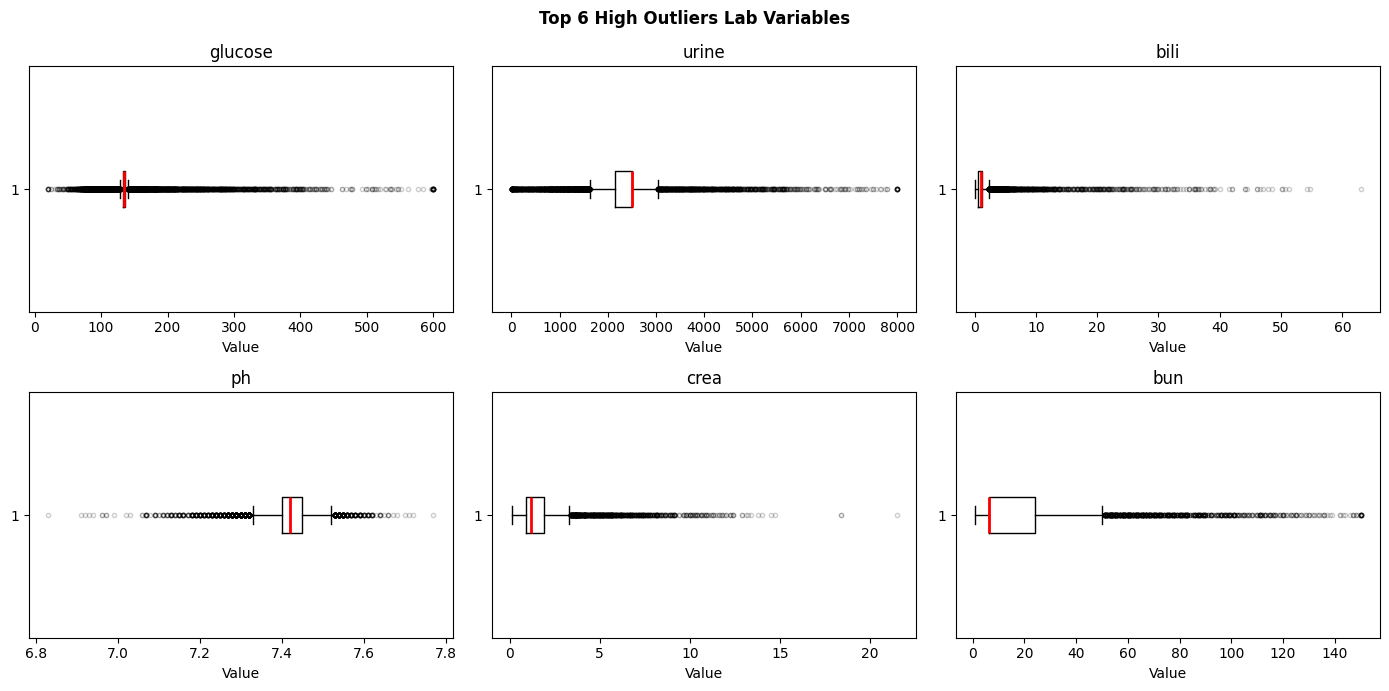

In [70]:
top6 = outlier_df.head(6)["Column"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, col in enumerate(top6):
    axes.flat[i].boxplot(
        df[col],
        vert=False,
        medianprops=dict(color="red", linewidth=2),
        flierprops=dict(marker="o", alpha=0.2, markersize=3, color="gray"),
    )
    axes.flat[i].set_title(col)
    axes.flat[i].set_xlabel("Value")
fig.suptitle("Top 6 High Outliers Lab Variables", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Section 4: Univariate Distributions <a id="p2-s4"></a>

- Lab features are mainly right skewed
- Some imputations cause spikeness (glucose, pafi, bili)

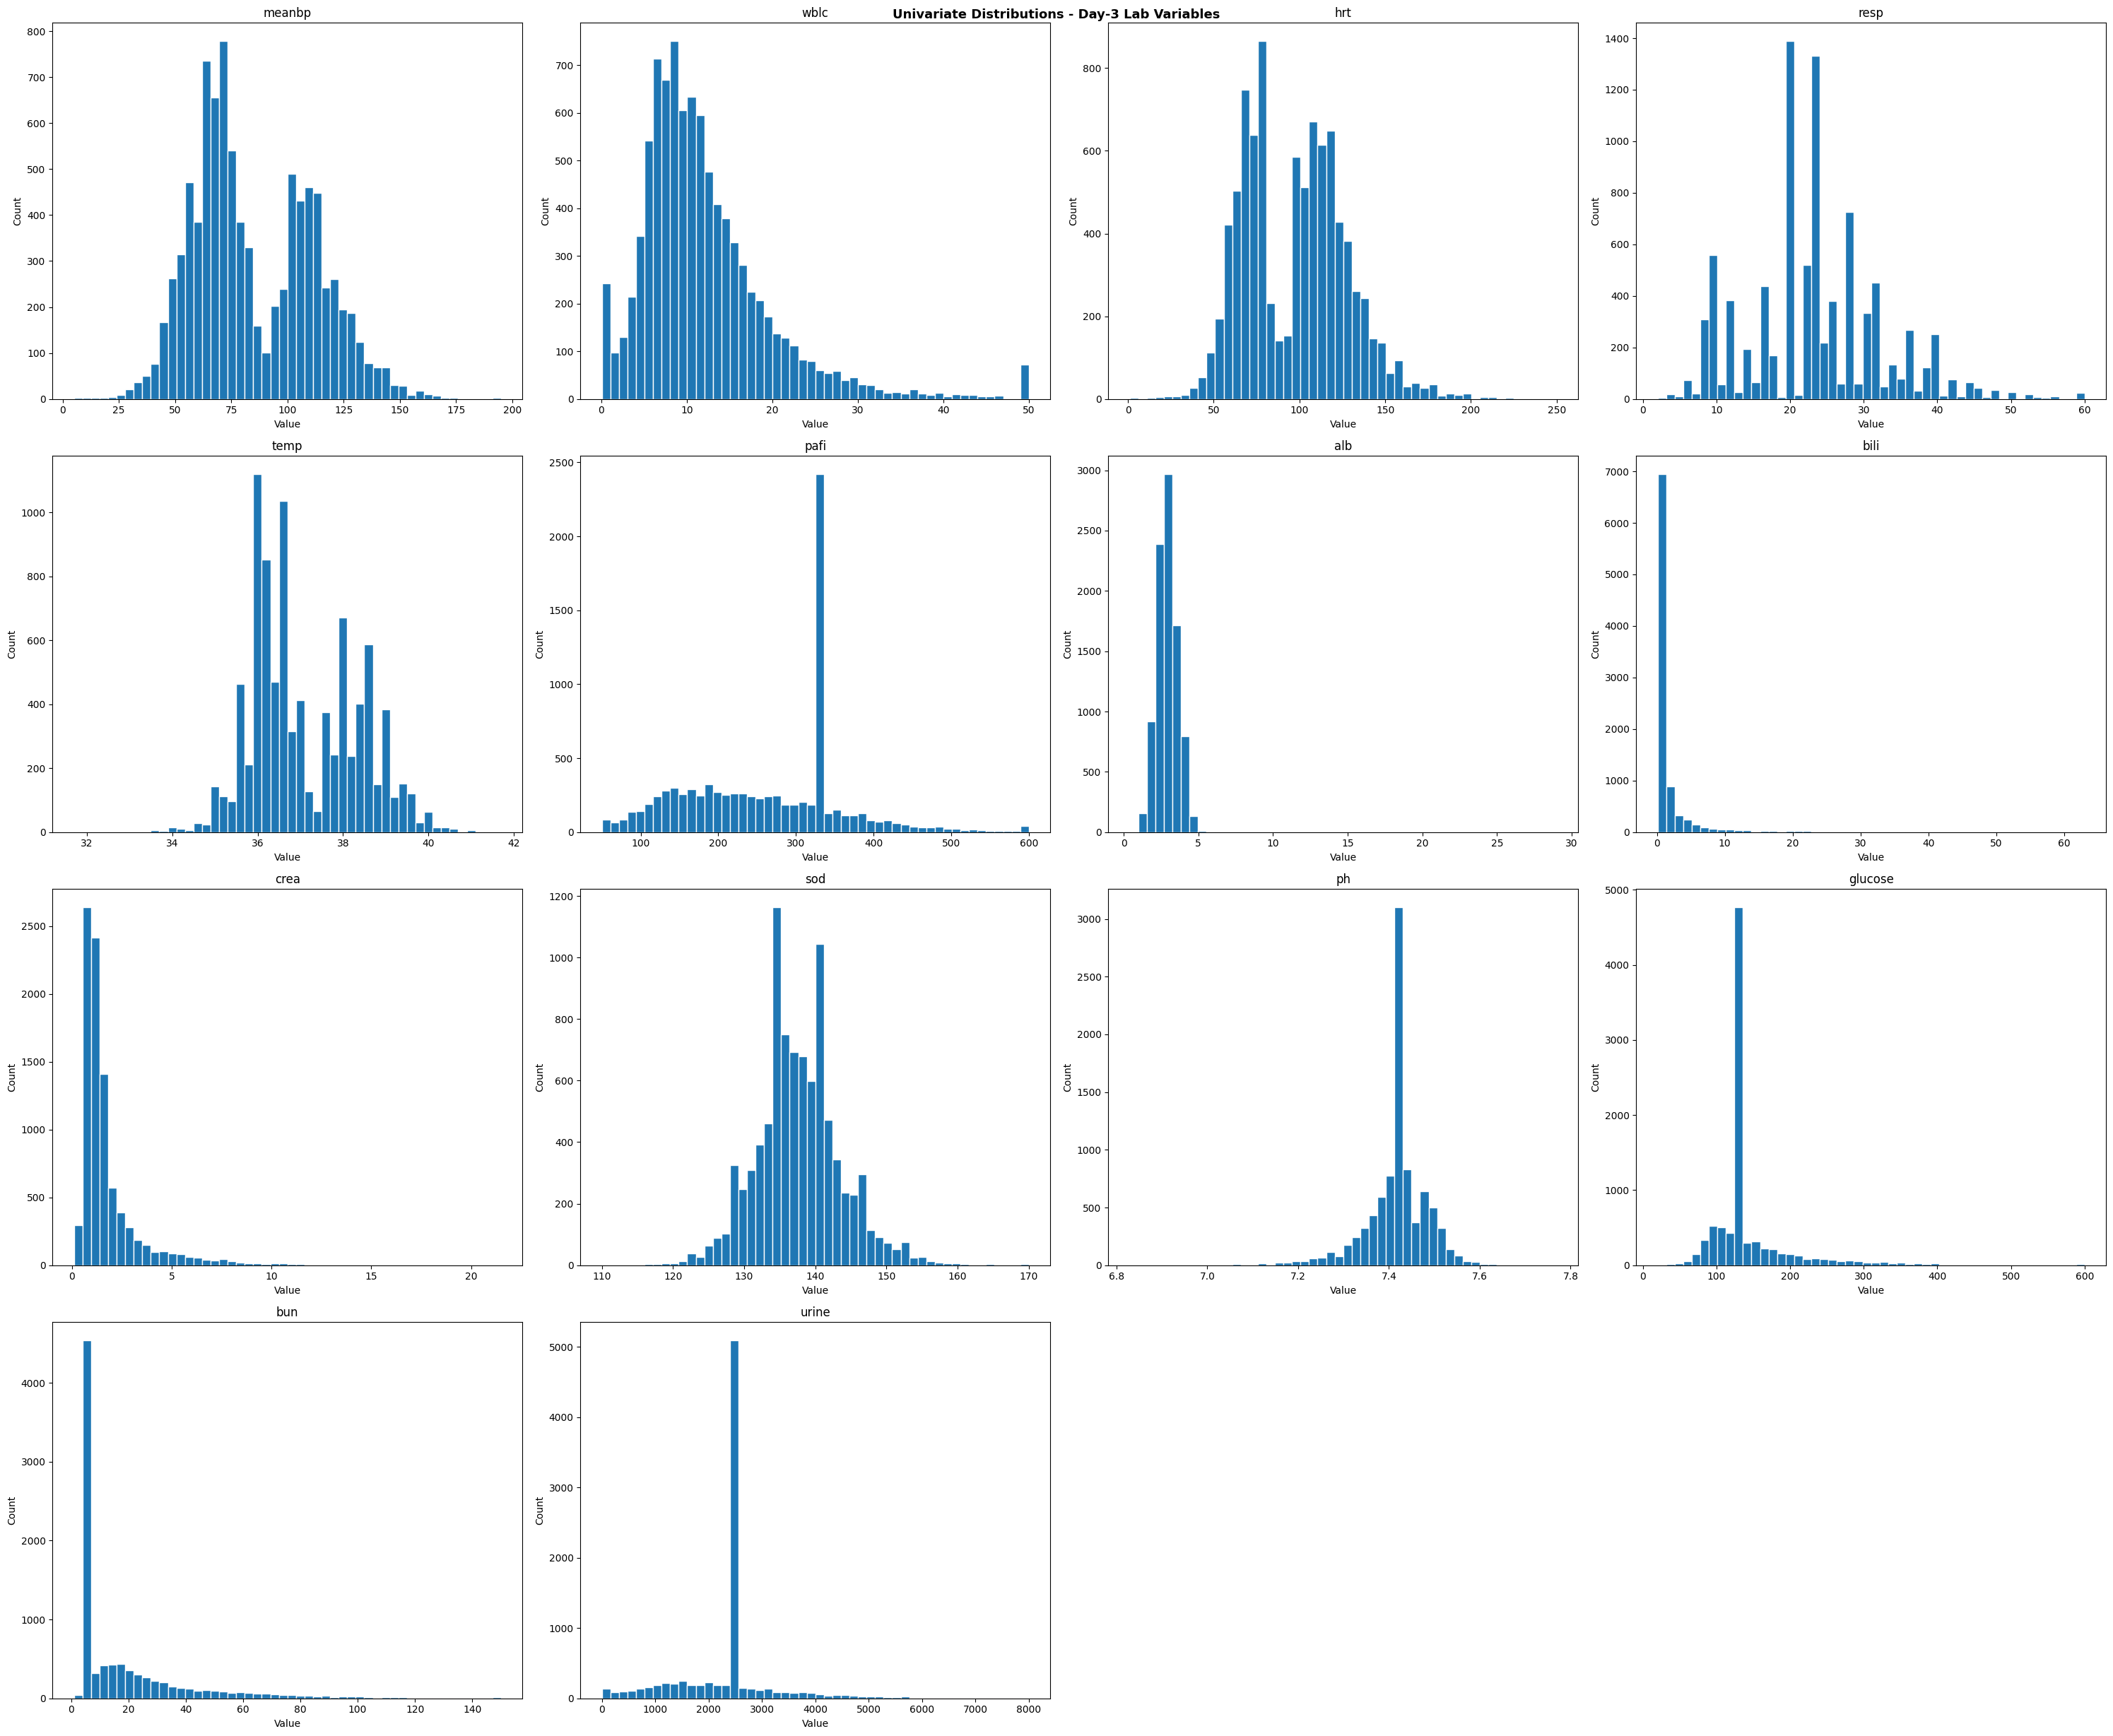

In [71]:
fig, axes = plt.subplots(4, 4, figsize=(30, 25))
for i, col in enumerate(LAB_COLS):
    axes.flat[i].hist(df[col], bins=50, edgecolor="white")
    axes.flat[i].set_title(col)
    axes.flat[i].set_xlabel("Value")
    axes.flat[i].set_ylabel("Count")
for j in range(len(LAB_COLS), len(axes.flat)):
    axes.flat[j].set_visible(False)
fig.suptitle(
    "Univariate Distributions - Day-3 Lab Variables", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

### 4.1 Age follows normal distribution

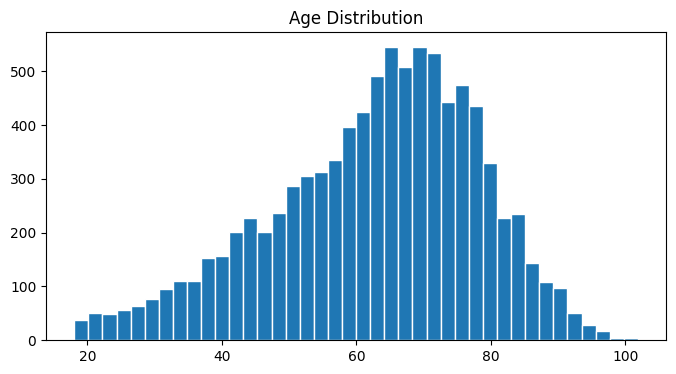

In [72]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["age"], bins=40, edgecolor="white")

ax.set_title("Age Distribution")
plt.show()

## Section 5: Bivariate Analysis - Lab Values by Survival Outcome <a id="p2-s5"></a>

- Difficult to see any impact these lab values make with this analysis
- The paper did say this only becomes evident when combined with Disease group. For example, a high creatine with kidney failure gives high likelihood of mortality.

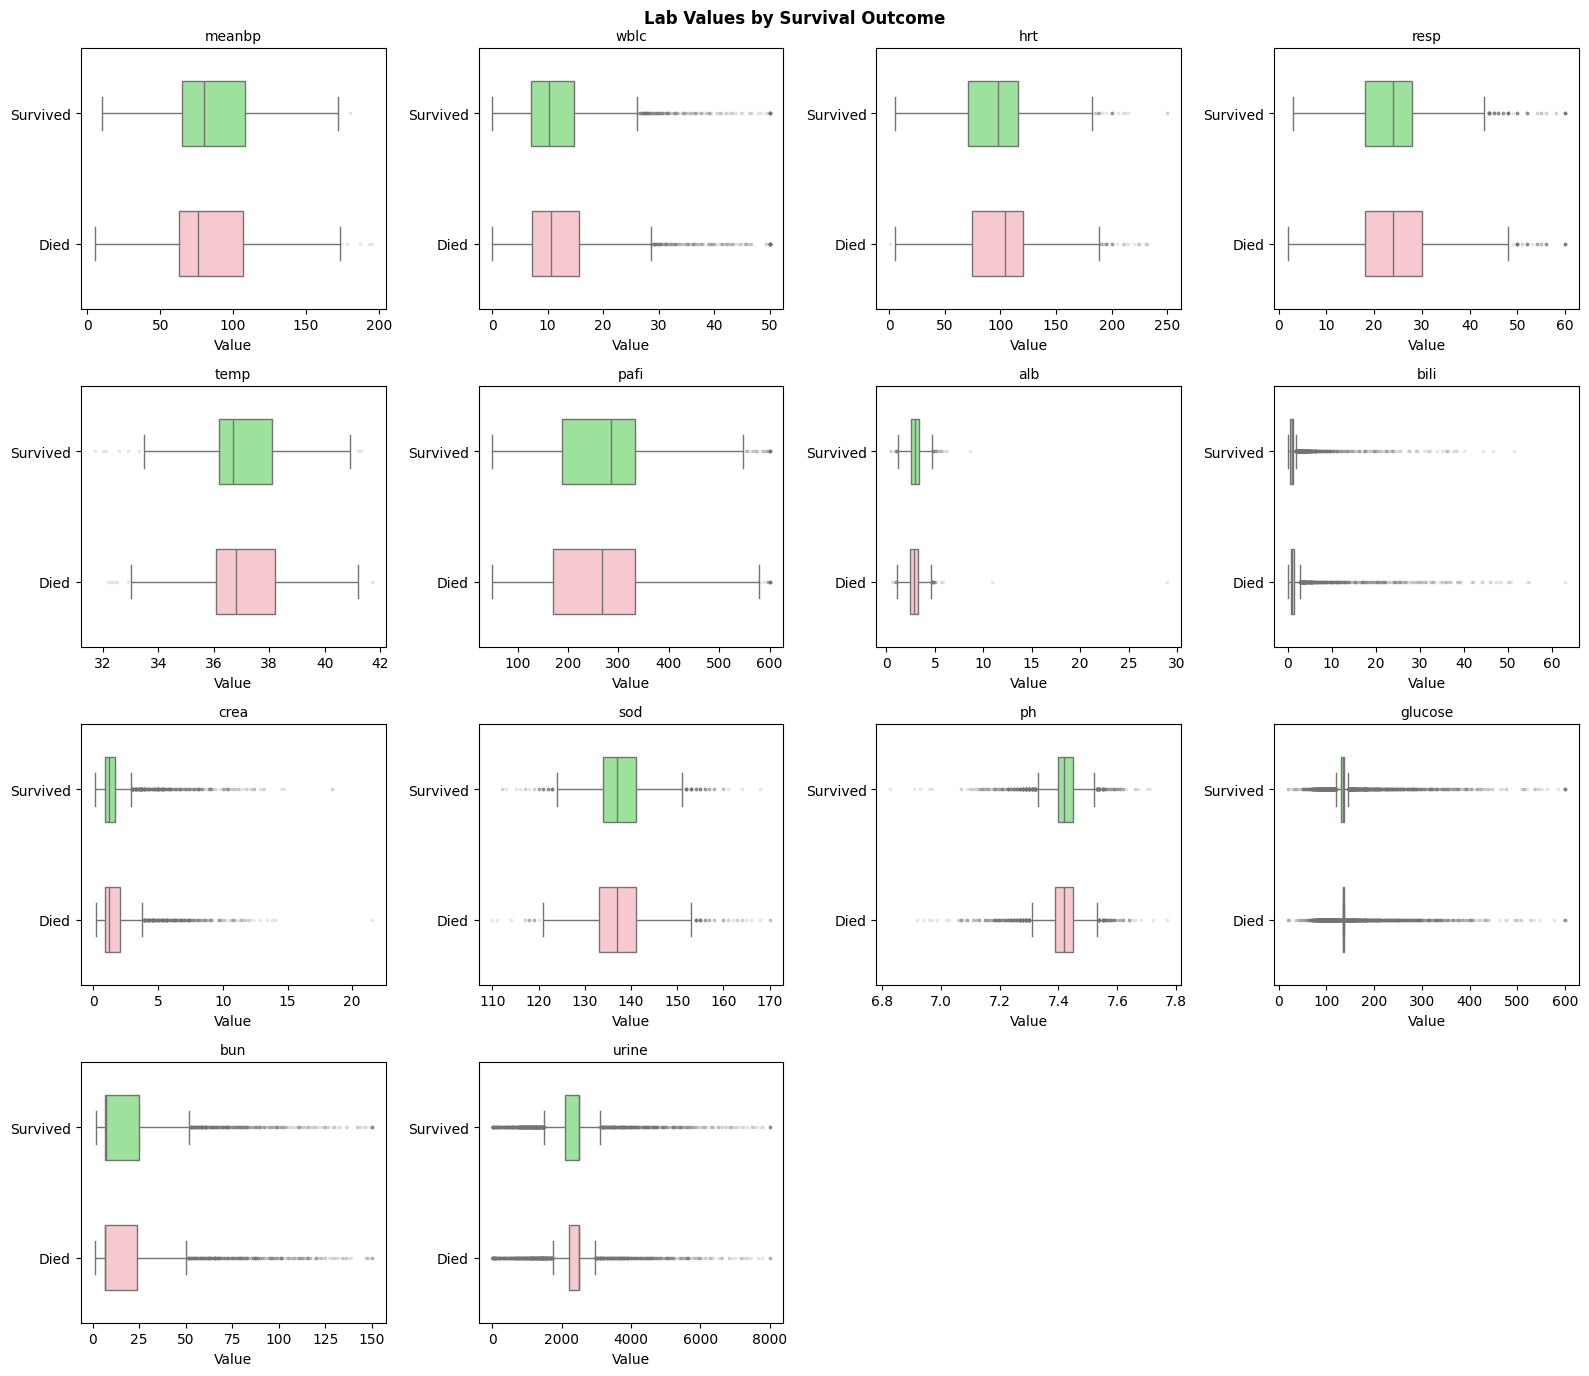

In [73]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for i, col in enumerate(LAB_COLS):
    ax = axes.flat[i]
    sns.boxplot(
        data=df,
        y=TARGET_COL,
        x=col,
        ax=ax,
        orient="h",
        palette=["lightgreen", "pink"],
        width=0.5,
        flierprops=dict(marker=".", alpha=0.2, markersize=3),
    )
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Survived", "Died"])

for j in range(len(LAB_COLS), len(axes.flat)):
    axes.flat[j].set_visible(False)

fig.suptitle(
    "Lab Values by Survival Outcome",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## Section 6: Demographic Analysis <a id="p2-s6"></a>

- Mortality gradual decline as wealth increases
- Asian group a bit more mortality

In [74]:
def plot_mortality_rate(df, col, target_col, overall_rate, ax, title=None, sort=True):
    rate = df.groupby(col, observed=True)[target_col].mean()
    rate = rate.sort_values(ascending=False)
    bars = ax.bar(
        range(len(rate)),
        rate.values * 100,
        edgecolor="white",
        width=0.6,
    )
    ax.axhline(
        overall_rate * 100,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=f"Overall ({overall_rate:.1%})",
    )
    ax.set_title(title or f"Mortality Rate by {col}")
    ax.set_ylabel("180-Day Mortality (%)")
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=30, ha="right", fontsize=8)
    ax.legend(fontsize=8)
    for bar, v in zip(bars, rate.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{v:.1%}",
            ha="center",
            fontsize=8,
        )

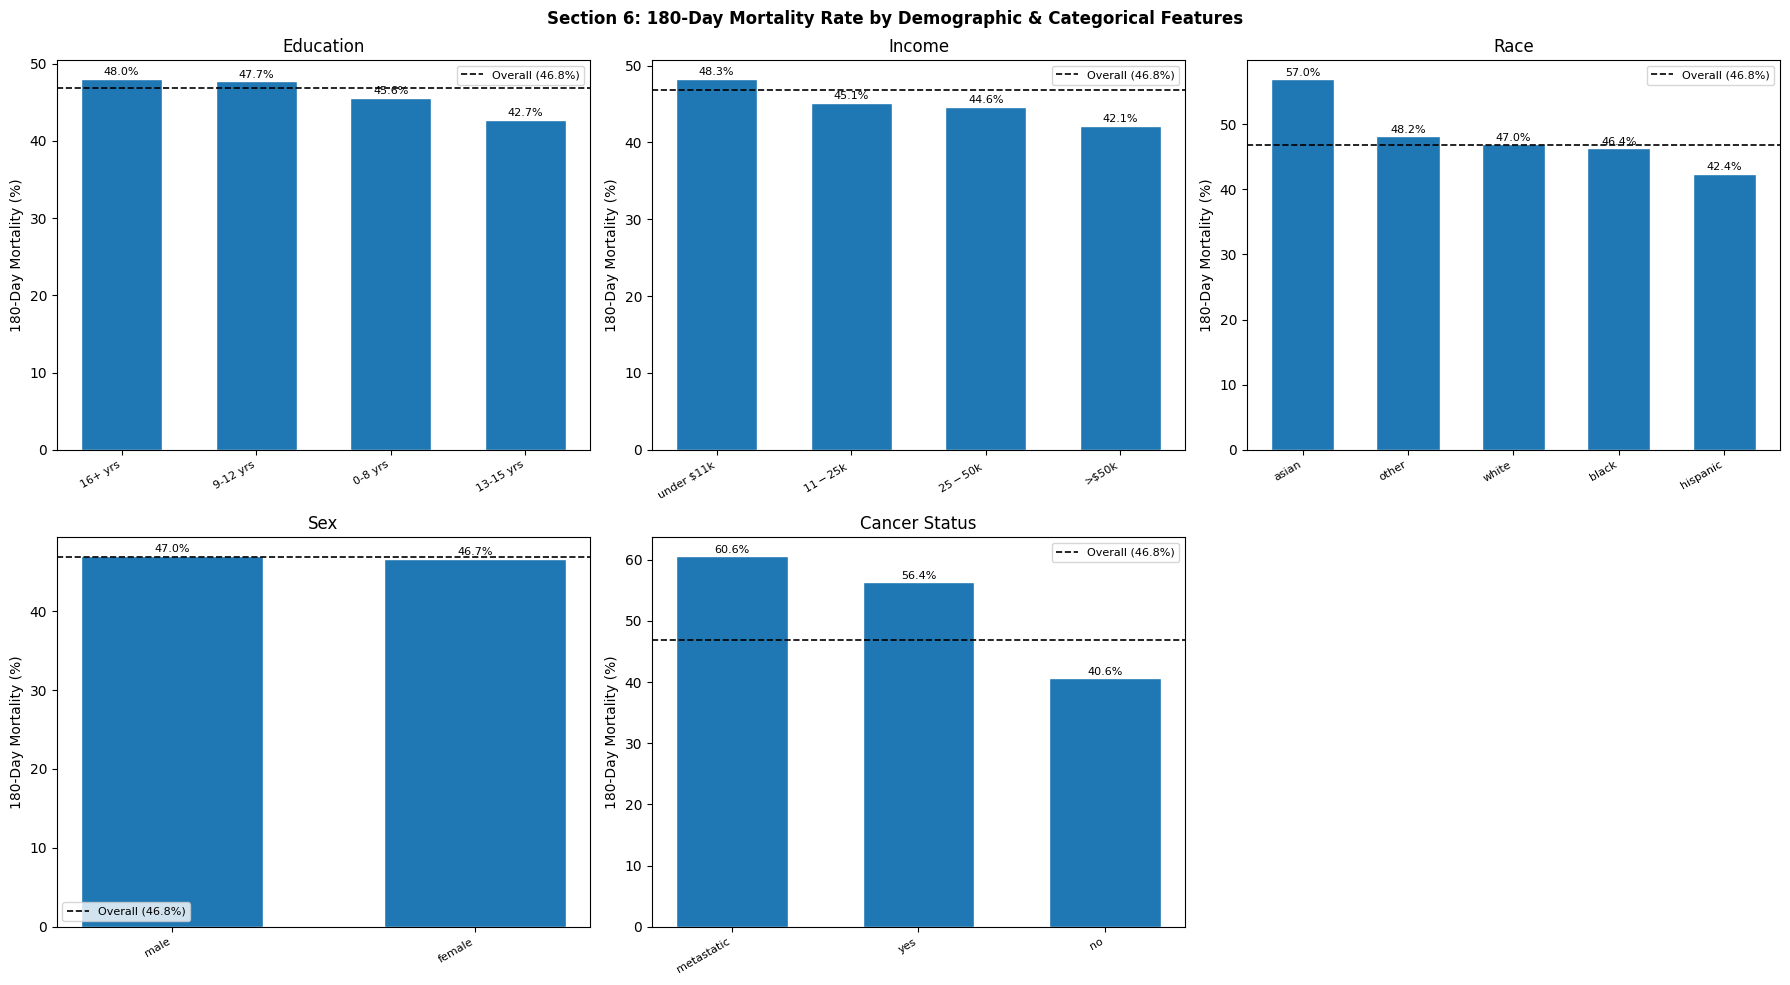

In [75]:
# education bins
edu_bins = [0, 8, 12, 15, 100]
edu_labels = ["0-8 yrs", "9-12 yrs", "13-15 yrs", "16+ yrs"]
df["edu_group"] = pd.cut(df["edu"], bins=edu_bins, labels=edu_labels, right=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_mortality_rate(
    df, "edu_group", TARGET_COL, overall_rate, axes[0, 0], title="Education", sort=False
)
plot_mortality_rate(df, "income", TARGET_COL, overall_rate, axes[0, 1], title="Income")
plot_mortality_rate(df, "race", TARGET_COL, overall_rate, axes[0, 2], title="Race")
plot_mortality_rate(df, "sex", TARGET_COL, overall_rate, axes[1, 0], title="Sex")
plot_mortality_rate(
    df, "ca", TARGET_COL, overall_rate, axes[1, 1], title="Cancer Status"
)
axes[1, 2].set_visible(False)

fig.suptitle(
    "Section 6: 180-Day Mortality Rate by Demographic & Categorical Features",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

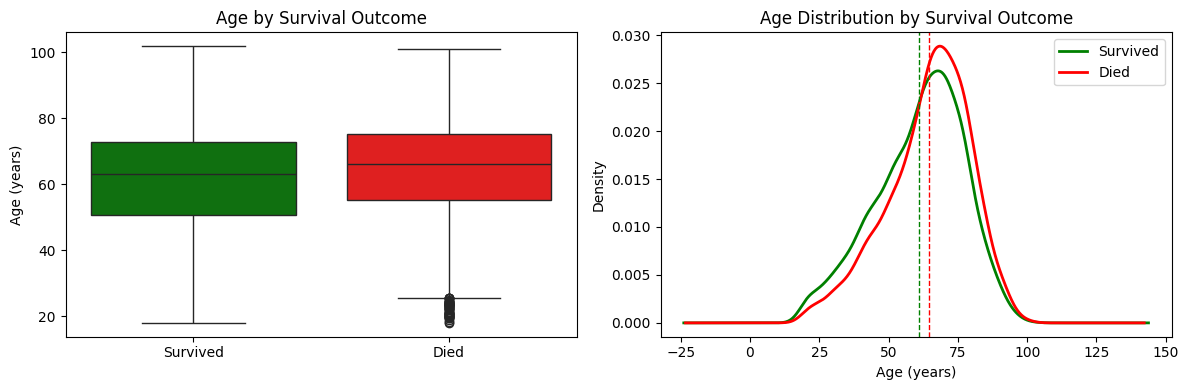

In [76]:
# Survivorship by age
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x=TARGET_COL, y="age", ax=axes[0], palette=["green", "red"])
axes[0].set_title("Age by Survival Outcome")
axes[0].set_xticklabels(["Survived", "Died"])
axes[0].set_xlabel("")
axes[0].set_ylabel("Age (years)")

# KDE overlay
for label, grp, color in [("Survived", survivors, "green"), ("Died", died, "red")]:
    grp["age"].plot.kde(ax=axes[1], label=label, color=color, linewidth=2)
axes[1].axvline(survivors["age"].mean(), color="green", linestyle="--", linewidth=1)
axes[1].axvline(died["age"].mean(), color="red", linestyle="--", linewidth=1)
axes[1].set_title("Age Distribution by Survival Outcome")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

## Section 7: Disease Group Analysis <a id="p2-s7"></a>

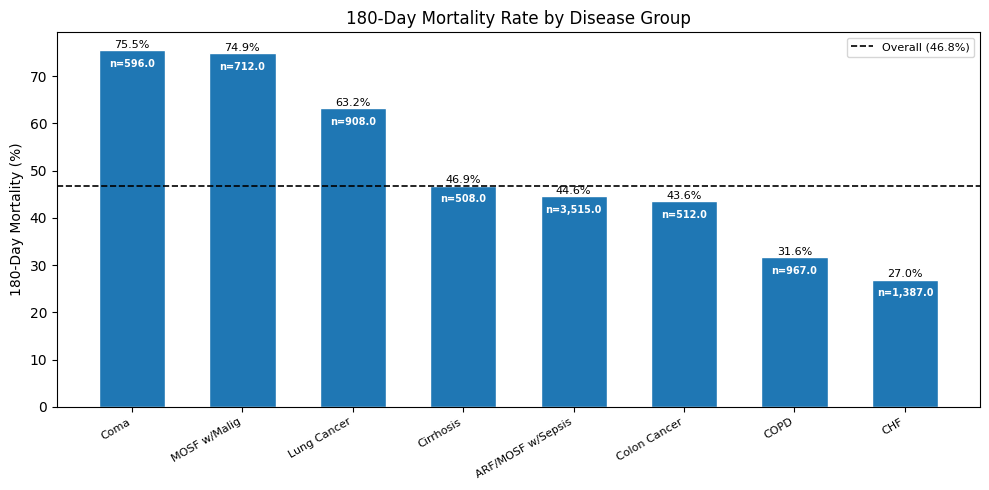

In [77]:
# mortality rate (uses utility) + patient count annotation
grp = df.groupby("dzgroup", observed=True)["death_180d"].agg(["mean", "count"])
grp.columns = ["Mortality", "N"]
grp = grp.sort_values("Mortality", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
plot_mortality_rate(
    df,
    "dzgroup",
    TARGET_COL,
    overall_rate,
    ax,
    title="180-Day Mortality Rate by Disease Group",
)
# annotate patient counts below percentage labels
for i, (_, row) in enumerate(grp.iterrows()):
    ax.text(
        i,
        row["Mortality"] * 100 - 3.5,
        f"n={row['N']:,}",
        ha="center",
        fontsize=7,
        color="white",
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

## Section 8: DNR Status <a id="p2-s8"></a>

- **no dnr**: no order placed
- **dnr before sadm**: order existed before study admission
- **dnr after sadm**: order placed during the admission (possibly due to detereorating conditions)

Note: DNR status is analyzed here as a contextual variable. It is excluded from model features because it reflects care decisions rather than clinical or physiologic status at day 3.

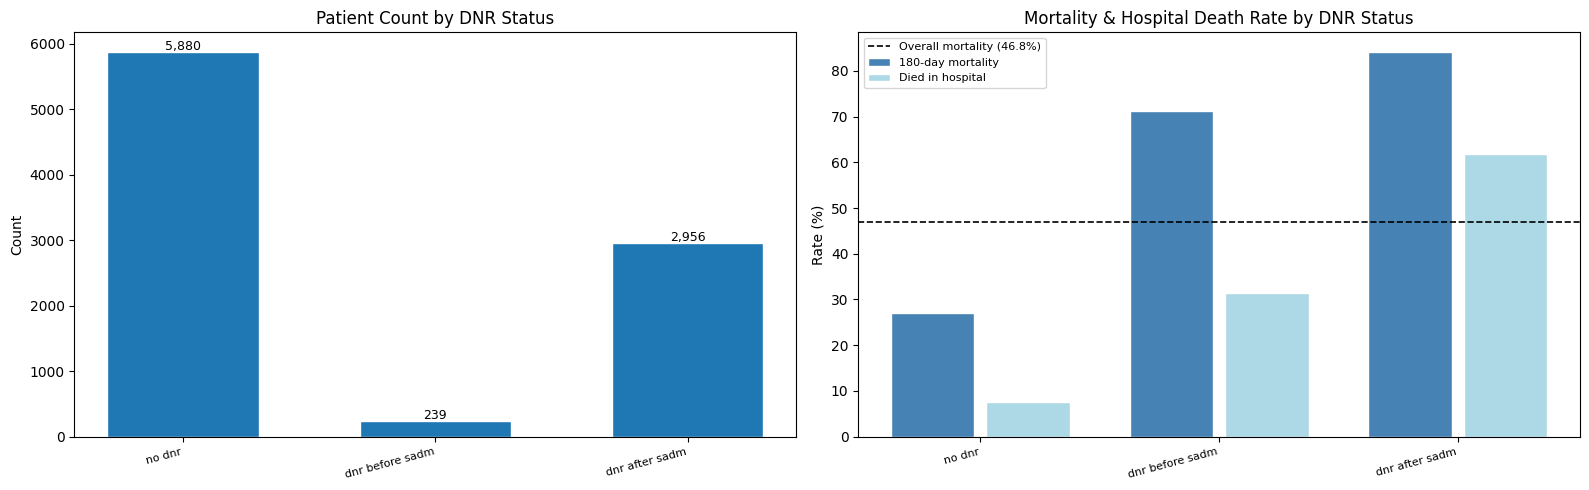

In [78]:
DNR_ORDER = ["no dnr", "dnr before sadm", "dnr after sadm"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

counts = df["dnr"].value_counts().reindex(DNR_ORDER)

# DNR count
axes[0].bar(range(3), counts.values, edgecolor="white", width=0.6)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(DNR_ORDER, rotation=15, ha="right", fontsize=8)
axes[0].set_title("Patient Count by DNR Status")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=9)

# DNR status compare
mort = df.groupby("dnr", observed=True)["death_180d"].mean().reindex(DNR_ORDER)
hosp = df.groupby("dnr", observed=True)["hospdead"].mean().reindex(DNR_ORDER)
x = range(3)

axes[1].bar(
    [i - 0.2 for i in x],
    mort.values * 100,
    width=0.35,
    color="steelblue",
    edgecolor="white",
    label="180-day mortality",
)
axes[1].bar(
    [i + 0.2 for i in x],
    hosp.values * 100,
    width=0.35,
    color="lightblue",
    edgecolor="white",
    label="Died in hospital",
)
axes[1].axhline(
    overall_rate * 100,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall mortality ({overall_rate:.1%})",
)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(DNR_ORDER, rotation=15, ha="right", fontsize=8)
axes[1].set_title("Mortality & Hospital Death Rate by DNR Status")
axes[1].set_ylabel("Rate (%)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

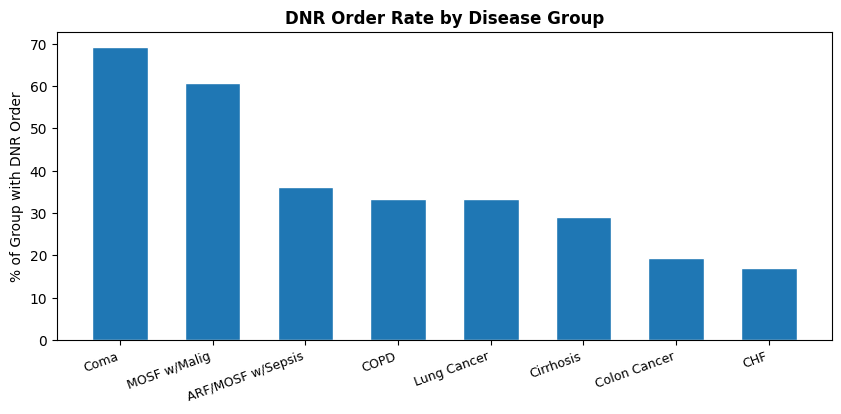

In [79]:
# DNR rate by Disease Group
dnr_rate = (
    df[df["dnr"] != "no dnr"].groupby("dzgroup", observed=True).size()
    / df.groupby("dzgroup", observed=True).size()
)
dnr_rate = dnr_rate.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    range(len(dnr_rate)),
    dnr_rate.values * 100,
    edgecolor="white",
    width=0.6,
)
ax.set_xticks(range(len(dnr_rate)))
ax.set_xticklabels(dnr_rate.index, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("% of Group with DNR Order")
ax.set_title("DNR Order Rate by Disease Group", fontweight="bold")
plt.show()

## Section 9: Interaction Analysis — Disease Group x Clinical Features <a id="p2-s9"></a>

Per Knaus et al. (1995), lab values and demographic factors only become strongly
predictive of mortality in combination with primary disease group. We examine two
key interactions identified in the original study:

1. **Albumin x Disease Group** — low albumin was strongly predictive in cancer,
   COPD, and CHF but relatively unimportant in coma or MOSF
2. **Age x Disease Group** — advancing age heavily impacted COPD survival but
   had almost no incremental effect in MOSF or malignancy

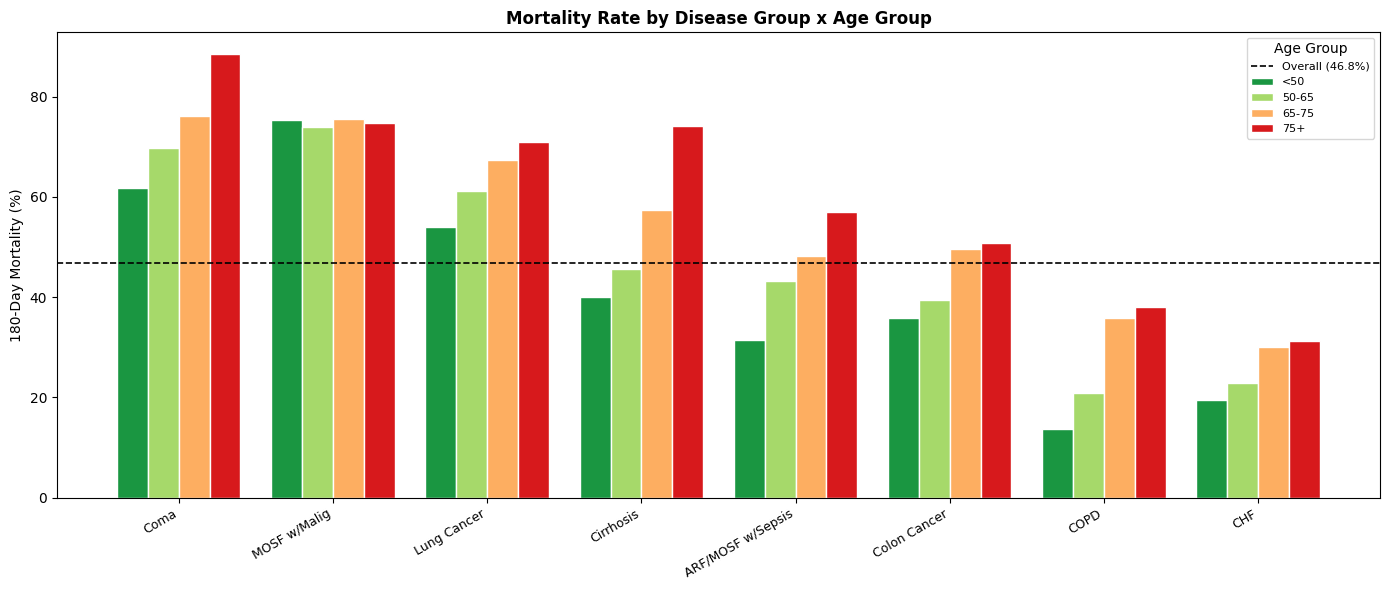

In [80]:
# Create age groups for interaction analysis
age_bins = [0, 50, 65, 75, 120]
age_labels = ["<50", "50-65", "65-75", "75+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)

# --- Plot: Mortality rate by Disease Group x Age Group ---
age_int = (
    df.groupby(["dzgroup", "age_group"], observed=True)["death_180d"]
    .mean()
    .reset_index()
)
age_int.columns = ["dzgroup", "age_group", "mortality_rate"]

dz_order = (
    df.groupby("dzgroup", observed=True)["death_180d"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(dz_order))
width = 0.2
age_groups = ["<50", "50-65", "65-75", "75+"]
colors = ["#1a9641", "#a6d96a", "#fdae61", "#d7191c"]

for i, (age_grp, color) in enumerate(zip(age_groups, colors)):
    subset = age_int[age_int["age_group"] == age_grp]
    subset = subset.set_index("dzgroup").reindex(dz_order)
    ax.bar(
        [xi + (i - 1.5) * width for xi in x],
        subset["mortality_rate"] * 100,
        width=width,
        label=age_grp,
        color=color,
        edgecolor="white",
    )

ax.axhline(
    df["death_180d"].mean() * 100,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall ({df['death_180d'].mean():.1%})",
)
ax.set_xticks(list(x))
ax.set_xticklabels(dz_order, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("180-Day Mortality (%)")
ax.set_title(
    "Mortality Rate by Disease Group x Age Group", fontweight="bold", fontsize=12
)
ax.legend(title="Age Group", fontsize=8)
plt.tight_layout()
plt.show()

### 9.1 Interaction: Mortality by Disease Group x Age Group

The chart reveals meaningful variation in how age modifies 180-day mortality
risk across disease groups, consistent with findings reported by Knaus et al.
(1995, Appendix Figure 3).

**COPD shows the strongest age gradient.** Younger COPD patients (<50, 50-65)
fall well below the overall mortality average of 46.8%, while the 65-75 and 75+
groups rise noticeably above it. This confirms the Knaus finding that in COPD,
an increase in age from 70 to 75 years meaningfully increases 180-day mortality
risk, more so than in any other disease group.

**Coma has high baseline mortality regardless of age.** Even the youngest Coma
patients (~61%) exceed the overall average, indicating that disease severity
drives mortality in this group more than age does. A modest amplifying effect
of age is visible in the 65-75 to 75+ transition (~77% to ~85%), but this is
secondary to the disease itself.

**MOSF with Malignancy and Lung Cancer show flat age profiles.** Bars are
relatively uniform across all age groups, consistent with the Knaus finding
that in acute physiologic crises with malignancy, severity of illness dominates
prognosis and age adds little incremental risk.

**Cirrhosis and CHF** show moderate age effects with bars trending upward across
age groups but without the steep gradient seen in COPD.

**Clinical implication:** Age is not uniformly prognostic across disease groups.
Its predictive value is disease-dependent, strongest in chronic conditions like
COPD where physiologic reserve declines gradually with age, and weakest in acute
severe conditions where immediate physiologic status determines outcome. This
interaction should be explicitly modeled in the full project rather than treating
age as a global linear predictor.

**Note:** Disease groups are ordered left to right by overall 180-day mortality
rate (highest to lowest), not by age effect magnitude.

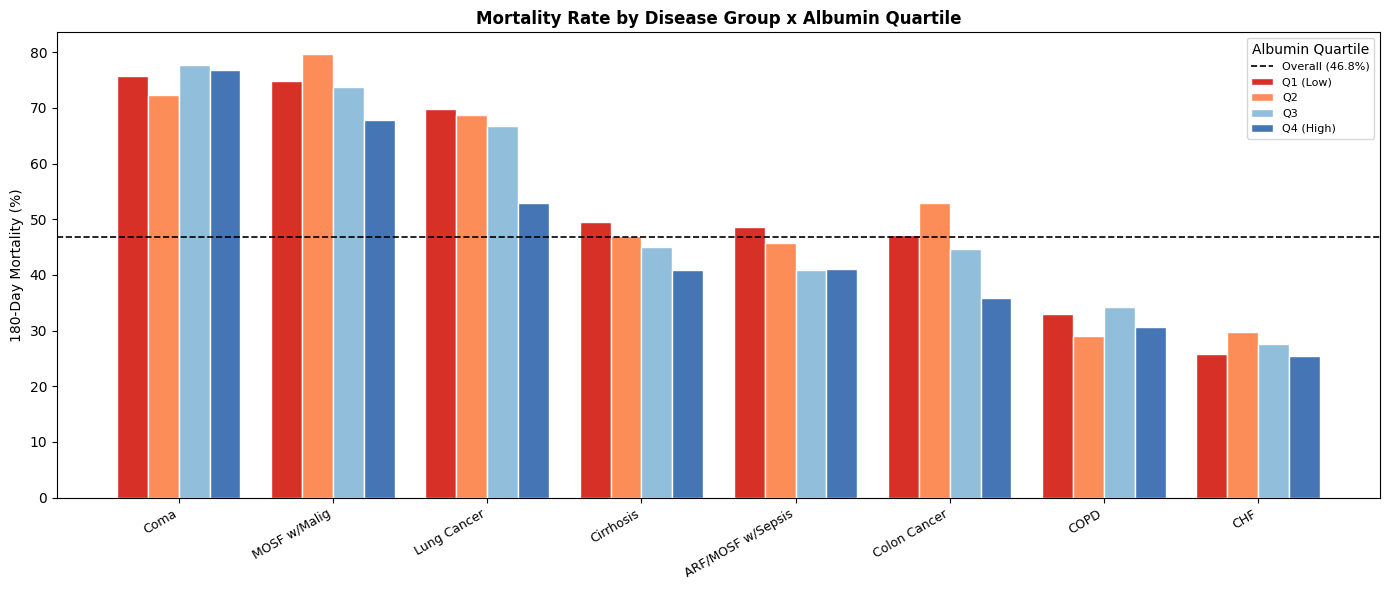

In [81]:
# Create albumin quartile groups
# KNN imputation restored sufficient variation for 4 true quartiles
# Note: original domain fill of 3.5 coincided with Q3 boundary,
# collapsing bins — replaced with KNN imputation in Part 1 (Data Cleaning)
df["alb_quartile"] = pd.qcut(
    df["alb"], q=4, labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
)

# --- Plot: Mortality rate by Disease Group x Albumin Quartile ---
alb_int = (
    df.groupby(["dzgroup", "alb_quartile"], observed=True)["death_180d"]
    .mean()
    .reset_index()
)
alb_int.columns = ["dzgroup", "alb_quartile", "mortality_rate"]

fig, ax = plt.subplots(figsize=(14, 6))
quartiles = ["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
colors = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4"]

for i, (quartile, color) in enumerate(zip(quartiles, colors)):
    subset = alb_int[alb_int["alb_quartile"] == quartile]
    subset = subset.set_index("dzgroup").reindex(dz_order)
    ax.bar(
        [xi + (i - 1.5) * width for xi in x],
        subset["mortality_rate"] * 100,
        width=width,
        label=quartile,
        color=color,
        edgecolor="white",
    )

ax.axhline(
    df["death_180d"].mean() * 100,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall ({df['death_180d'].mean():.1%})",
)
ax.set_xticks(list(x))
ax.set_xticklabels(dz_order, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("180-Day Mortality (%)")
ax.set_title(
    "Mortality Rate by Disease Group x Albumin Quartile", fontweight="bold", fontsize=12
)
ax.legend(title="Albumin Quartile", fontsize=8)
plt.tight_layout()
plt.show()

### 9.2 Interaction: Mortality by Disease Group x Albumin Quartile

Following KNN imputation of albumin (replacing the original domain fill of 3.5
g/dL which collapsed quartile bins), this chart examines whether serum albumin
level modifies 180-day mortality risk differently across disease groups, a key
interaction identified by Knaus et al. (1995).

**Lung Cancer shows the strongest albumin gradient.** Mortality decreases from
approximately 69% in the lowest albumin quartile (Q1) to 51% in the highest (Q4),
an 18 percentage point spread, the largest gradient in the chart. This directly
confirms the Knaus finding that low serum albumin had an especially strong
relation with risk for death in lung cancer patients.

**Colon Cancer shows the second strongest gradient.** Mortality decreases from
approximately 53% (Q1) to 34% (Q4), a 19 percentage point spread when the full
range is considered, though the Q1-Q2 step is the most pronounced. Consistent
with Knaus identifying albumin as strongly prognostic in colon cancer patients.

**CHF and COPD show weak but present albumin gradients**, a modest reduction
in mortality from low to high albumin quartiles, consistent with the Knaus
finding of a weaker but present albumin association in chronic conditions.

**ARF/MOSF with Sepsis and Cirrhosis show relatively flat albumin profiles,**
suggesting albumin adds limited prognostic value in these groups beyond overall
disease severity.

**Coma shows an unexpected reverse pattern** — Q4 (high albumin) has the highest
mortality (~81%) rather than the lowest. This counterintuitive finding likely
reflects confounding: patients in a coma with preserved albumin levels may
represent a distinct clinical subtype, such as acute neurological events in
otherwise well-nourished patients. This warrants further investigation in the
modeling phase.

**MOSF with Malignancy shows a modest reverse pattern** — Q2 is slightly higher
than Q1 before declining, suggesting albumin's relationship with mortality is
nonlinear or confounded by disease-specific factors in this group.

**Clinical and modeling implication:** Albumin is not a uniformly useful predictor
across all disease groups. Its prognostic value is most pronounced in cancer
patients, particularly lung and colon cancer, and largely absent or reversed in
acute physiologic crises. The full project model should include albumin x disease
group interaction terms rather than treating albumin as a global linear predictor,
consistent with the original SUPPORT prognostic model (Knaus et al., 1995).

**Methodological note:** Albumin was re-imputed using KNN (k=5) with
physiologically related features as neighbors (age, meanbp, hrt, resp, temp,
sod), replacing the original domain fill value of 3.5 g/dL. The KNN approach
produced a clinically coherent distribution (median = 2.96 g/dL, IQR =
2.50-3.40), consistent with expected albumin levels in a critically ill
population.

## Section 10: Correlation Matrix — Numeric Features <a id="p2-s10"></a>

With 46 variables available for modeling, multicollinearity is a meaningful
risk. Highly correlated features provide redundant information and can
destabilize model coefficients, inflate standard errors, and complicate
interpretation. This section identifies problematic feature pairs before
modeling begins.

The correlation matrix displays Pearson correlations between all numeric
features. Values close to 1.0 indicate strong positive correlation, values
close to -1.0 indicate strong negative correlation, and values near 0
indicate little linear relationship. Pairs with |r| > 0.7 are flagged as
candidates for feature selection or dimensionality reduction in the modeling
notebook.

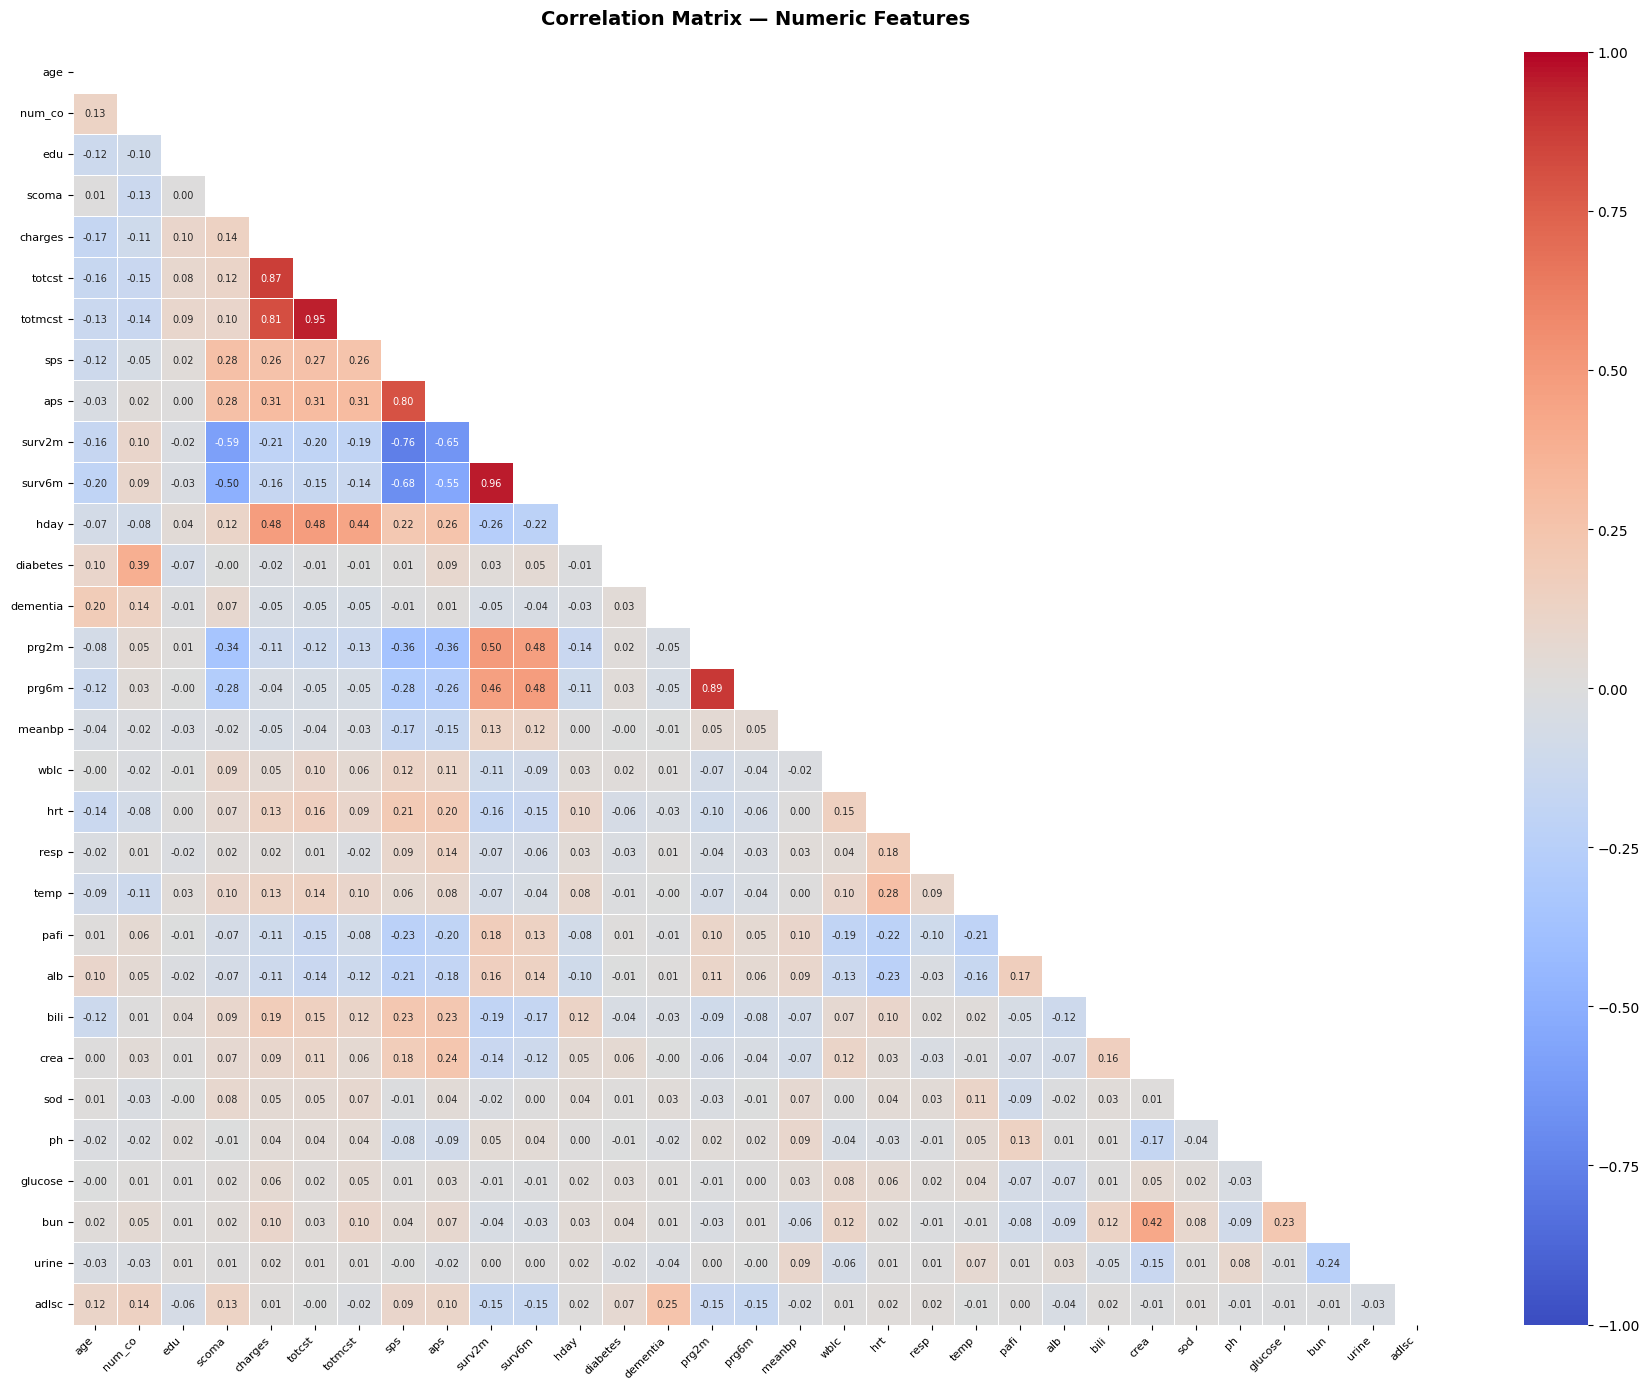

=== High Correlation Pairs (|r| > 0.7) ===

Feature A Feature B      r
   surv6m    surv2m  0.960
  totmcst    totcst  0.949
    prg6m     prg2m  0.890
   totcst   charges  0.872
  totmcst   charges  0.814
      aps       sps  0.798
   surv2m       sps -0.758


In [82]:
# Section 10: Correlation Heatmap — Numeric Features
#
# With 40+ potential predictors, multicollinearity is a real risk.
# Highly correlated features (|r| > 0.7) provide redundant information
# and can destabilize model coefficients. This heatmap identifies
# problematic pairs before modeling begins.

numeric_cols = df.select_dtypes(include="number").columns.tolist()

# Exclude target, outcome, and identifier columns
exclude = ["death_180d", "death", "hospdead", "id", "slos", "d_time"]
feature_cols = [c for c in numeric_cols if c not in exclude]

corr_matrix = df[feature_cols].corr()

# Mask upper triangle for cleaner reading
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 7},
    ax=ax,
)
ax.set_title(
    "Correlation Matrix — Numeric Features", fontsize=14, fontweight="bold", pad=20
)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Flag high correlation pairs
print("=== High Correlation Pairs (|r| > 0.7) ===\n")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append(
                {
                    "Feature A": corr_matrix.columns[i],
                    "Feature B": corr_matrix.columns[j],
                    "r": round(r, 3),
                }
            )

if high_corr:
    high_corr_df = pd.DataFrame(high_corr).sort_values("r", ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("No pairs with |r| > 0.7 found.")

### 10.1 Correlation Findings

The majority of numeric features are weakly correlated with one another
(|r| < 0.5), indicating the feature set is generally clean and suitable
for modeling. Five pairs exceed the |r| > 0.7 multicollinearity threshold
and warrant specific attention.

**`surv6m` x `surv2m` (r = 0.960)** — the strongest correlation in the
matrix. Both are SUPPORT model survival probability estimates differing
only in time horizon (6-month vs. 2-month). They are measuring the same
underlying construct from the same model inputs, making them functionally
redundant as predictors. `surv2m` should be excluded from the feature set;
`surv6m` is retained as the benchmark comparison variable and excluded from
model features to avoid leakage.

**`prg6m` x `prg2m` (r = 0.889)** — physician survival estimates at 6 and
2 months respectively. The same redundancy applies as with the SUPPORT
estimates; both capture physician judgment about the same patient at the
same point in time. `prg2m` should be excluded; `prg6m` retained if
physician estimates are included as a feature, noting that combining
physician estimates with model features replicates the physician-enhanced
SUPPORT model described in Knaus et al. (1995).

**`aps` x `sps` (r = 0.800)** — both are composite physiologic severity
scores constructed from overlapping input variables including blood pressure,
heart rate, respiratory rate, temperature, and laboratory values. Their
correlation reflects shared measurement of the same underlying construct
(severity of acute illness) rather than any methodological dependency. Unlike
the survival estimate pairs, `aps` and `sps` apply different disease-specific
weightings and are not perfectly interchangeable. Both are retained as
candidates for the feature set; LASSO regularization in the modeling phase
will naturally downweight the less informative of the two.

**`totcst` x `charges` (r = 0.742)** — total cost and hospital charges are
financially related by definition. More importantly, both are outcomes of
care delivery rather than clinical predictors of mortality; a patient does
not incur charges because they are sick...they incur charges because of
interventions performed. Including either as a model feature would introduce
reverse causality. Both should be excluded from the feature set entirely.

**`surv2m` x `sps` (r = -0.756)** — a strong negative correlation between
the 2-month survival estimate and the physiology severity score. This is
clinically expected and not a multicollinearity concern; sicker patients
(higher sps) receive lower survival probability estimates. The negative sign
confirms the directionality is correct. No action required.

**Modeling implications:** Three actions follow from this analysis:
1. Drop `surv2m` and `prg2m` — redundant with their 6-month counterparts
2. Drop `totcst` and `charges` — outcomes of care, not predictors
3. Monitor `aps` and `sps` — retain both but apply LASSO regularization
   to manage their shared variance in the Part 3 (Model Development)

## Section 11: Numeric Feature Summary by Outcome Group <a id="p2-s11"></a>

The following table presents mean values of key clinical variables stratified
by 180-day mortality outcome. Features are ordered by the standardized
difference between groups, which normalizes raw differences by pooled standard
deviation, putting all variables on the same scale regardless of units.

This table serves two purposes: it provides a reportable summary of group
differences for the technical report, and it establishes the basis for formal
hypothesis testing in Section 12, where statistical significance of each
difference is evaluated.

In [83]:
# Section 11: Numeric Summary by Outcome Group
#
# Mean values of key clinical variables broken out by 180-day mortality outcome.
# Standardized difference (Cohen's d approximation) normalizes raw differences
# by pooled standard deviation, putting all variables on the same scale
# regardless of units. This corrects for the misleading ranking produced by
# sorting on raw differences alone.

key_features = [
    "age",
    "num_co",
    "scoma",
    "sps",
    "aps",
    "meanbp",
    "hrt",
    "resp",
    "temp",
    "alb",
    "bili",
    "crea",
    "sod",
    "ph",
    "glucose",
    "bun",
    "wblc",
    "pafi",
    "urine",
    "adlsc",
]

summary_std = df.groupby("death_180d")[key_features].agg(["mean", "std"])

rows = []
for feat in key_features:
    mean_surv = summary_std.loc[0, (feat, "mean")]
    mean_died = summary_std.loc[1, (feat, "mean")]
    std_surv = summary_std.loc[0, (feat, "std")]
    std_died = summary_std.loc[1, (feat, "std")]

    pooled_std = np.sqrt((std_surv**2 + std_died**2) / 2)

    raw_diff = mean_died - mean_surv
    std_diff = raw_diff / pooled_std if pooled_std > 0 else 0

    rows.append(
        {
            "Feature": feat,
            "Survived": round(mean_surv, 3),
            "Died": round(mean_died, 3),
            "Raw Difference": round(raw_diff, 3),
            "Standardized Difference": round(std_diff, 3),
        }
    )

summary_final = pd.DataFrame(rows).set_index("Feature")
summary_final = summary_final.reindex(
    summary_final["Standardized Difference"].abs().sort_values(ascending=False).index
)

print("=== Numeric Feature Means by 180-Day Mortality Outcome ===\n")
print(summary_final.to_string())

=== Numeric Feature Means by 180-Day Mortality Outcome ===

         Survived      Died  Raw Difference  Standardized Difference
Feature                                                             
sps        22.532    28.923           6.391                    0.673
aps        32.078    43.862          11.784                    0.613
scoma       5.963    18.973          13.009                    0.537
adlsc       1.552     2.269           0.717                    0.362
age        61.067    64.448           3.381                    0.218
bili        1.751     2.525           0.774                    0.168
alb         2.975     2.860          -0.115                   -0.153
hrt        95.925   100.490           4.565                    0.152
meanbp     86.409    83.364          -3.045                   -0.113
crea        1.681     1.861           0.180                    0.107
pafi      268.134   257.663         -10.471                   -0.103
wblc       11.727    12.523           0.797

## Section 12: Hypothesis Testing — Group Differences by Outcome <a id="p2-s12"></a>

The summary table in Section 11 identified univariate differences in feature
means between outcome groups. This section formally tests whether those
differences are statistically significant or could plausibly have occurred
by chance.

**Note on inference in EDA:** Hypothesis testing is inferential rather than
exploratory. It is included here as a bridge between EDA and modeling.
Features with statistically significant differences between outcome groups
are stronger candidates for the feature set. Findings should be interpreted
as hypothesis-generating rather than confirmatory; formal model-based
inference follows in the Part 3 (Model Development).

**Test selection:** Most clinical variables in this dataset are right-skewed,
as confirmed in earlier EDA. The Mann-Whitney U test is used rather than the
independent samples t-test because it makes no assumption of normality and
is more appropriate for skewed continuous data. The null hypothesis for each
feature is that the distribution is identical between survivors and patients
who died. A Bonferroni correction is applied to account for multiple
comparisons across 20 features, yielding an adjusted significance threshold
of alpha = 0.05 / 20 = 0.0025.

In [84]:
# Section 12: Mann-Whitney U Tests — Feature Differences by Outcome
#
# Tests whether each feature's distribution differs significantly between
# survivors and patients who died. Mann-Whitney U is used over t-test
# because most clinical variables are right-skewed.
# Bonferroni correction applied for multiple comparisons (n=20 features).

survived = df[df["death_180d"] == 0]
died = df[df["death_180d"] == 1]

alpha = 0.05
bonferroni_alpha = alpha / len(key_features)

results = []
for feat in key_features:
    stat, p = stats.mannwhitneyu(
        survived[feat].dropna(), died[feat].dropna(), alternative="two-sided"
    )
    results.append(
        {
            "Feature": feat,
            "Survived Mean": round(survived[feat].mean(), 3),
            "Died Mean": round(died[feat].mean(), 3),
            "Standardized Diff": round(
                summary_final.loc[feat, "Standardized Difference"], 3
            ),
            "U Statistic": round(stat, 1),
            "p-value": round(p, 6),
            "Significant (Bonferroni)": "Yes" if p < bonferroni_alpha else "No",
        }
    )

results_df = pd.DataFrame(results).set_index("Feature")
results_df = results_df.reindex(summary_final.index)

print(
    f"Mann-Whitney U Test Results (Bonferroni-corrected alpha = {bonferroni_alpha:.4f})\n"
)
print(results_df.to_string())

sig = (results_df["Significant (Bonferroni)"] == "Yes").sum()
not_sig = (results_df["Significant (Bonferroni)"] == "No").sum()
print(f"\nSignificant features: {sig} / {len(key_features)}")
print(f"Non-significant features: {not_sig} / {len(key_features)}")

Mann-Whitney U Test Results (Bonferroni-corrected alpha = 0.0025)

         Survived Mean  Died Mean  Standardized Diff  U Statistic   p-value Significant (Bonferroni)
Feature                                                                                             
sps             22.532     28.923              0.673    6572830.0  0.000000                      Yes
aps             32.078     43.862              0.613    7059107.0  0.000000                      Yes
scoma            5.963     18.973              0.537    7898092.0  0.000000                      Yes
adlsc            1.552      2.269              0.362    8256559.5  0.000000                      Yes
age             61.067     64.448              0.218    9058189.5  0.000000                      Yes
bili             1.751      2.525              0.168    9699753.0  0.000000                      Yes
alb              2.975      2.860             -0.153   11346883.5  0.000000                      Yes
hrt             95.925  

### 12.1 Hypothesis Testing Results

Thirteen of 20 features showed statistically significant differences between
survivors and patients who died after Bonferroni correction (adjusted alpha =
0.0025). Seven features failed to reach significance and are unlikely to
contribute meaningful univariate predictive value.

**Significant features (13):** sps, aps, scoma, adlsc, age, bili, hrt, alb,
meanbp, crea, pafi, wblc, resp. All returned p-values at or near zero with
the exception of bili (p = 0.000001), crea (p = 0.000002), pafi (p =
0.000001), wblc (p = 0.000204), and resp (p = 0.000490), all well below
the corrected threshold.

**Non-significant features (7):** temp, num_co, bun, urine, ph, sod,
glucose. These features show negligible standardized differences and
p-values ranging from 0.150 to 0.937, providing no statistical evidence
of distributional difference between outcome groups.

**Notable findings:**

The three strongest separators by standardized difference, sps (0.664),
aps (0.597), and scoma (0.522), are also the most statistically significant,
with p-values indistinguishable from zero. This convergence of effect size
and significance strengthens the case for their inclusion in the modeling
feature set and is consistent with Knaus et al. (1995) ranking physiology
score and coma score as the two most important prognostic factors.

Albumin (alb) is statistically significant (p < 0.0001) despite a modest
standardized difference of -0.148. This apparent contradiction is resolved
by the interaction analysis in Section 9, where albumin's predictive value
is concentrated in specific disease groups rather than distributed uniformly
across the population.

The non-significance of glucose, bun, ph, and sod is noteworthy given
their clinical relevance in critical illness. This likely reflects the
impact of median imputation on these variables, glucose (49% imputed),
bun (48% imputed), and ph (25% imputed), which compresses their
distributions toward the median, reducing apparent group differences.
These findings should be interpreted cautiously and revisited if imputation
strategy changes in the full project.

The non-significance of num_co (p = 0.429) is consistent with the Knaus
et al. finding that the only statistically significant comorbidity was
diagnosis of malignancy, captured here by disease group rather than
comorbidity count.

**Modeling recommendations:** Features with p-values above the Bonferroni
threshold (temp, num_co, bun, urine, ph, sod, glucose) are candidates for
exclusion from the initial feature set. The following features must be
excluded regardless of statistical significance due to data leakage:

- `sps` — direct component of the SUPPORT physiology score; using it to
  predict the same outcome the SUPPORT model predicts is circular
- `surv6m`, `surv2m` — SUPPORT model output predictions; retained as
  benchmark comparison variables only, never as model features
- `prg6m`, `prg2m` — physician survival estimates generated from the same
  clinical assessments captured by other features; including them would
  conflate clinical judgment with physiologic measurement

`aps` (APACHE III score) is an independent benchmark system and does not
constitute leakage in the same way, but its inclusion should be explicitly
justified during feature selection given its role as a competing prognostic
instrument rather than a raw clinical measurement.

For all remaining significant features, univariate significance is a
necessary but not sufficient criterion for inclusion. Features that are
non-significant individually may contribute in combination with others.
Final feature selection will be informed by regularization in Part 3 (Model Development).

## Section 13: Categorical Features: Chi-Squared Tests & Contingency Tables <a id="p2-s13"></a>

Tests whether a categorical variable is **statistically independent** of 180-day mortality.

$$H_0: \text{the variable is independent of death\_180d}$$

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

Reject $H_0$ when $p < 0.05$.

**Standardized residuals** = $(O - E) / \sqrt{E}$ — cells with $|r| > 2$ deviate significantly from independence and drive the chi-squared result.

### 13.1 Race and Sex shows low P significance

In [85]:
# dnr excluded from CAT_COLS. It is retained in Silver for EDA context but excluded from
# model features, as it reflects care decisions rather than clinical status at day 3.
CAT_COLS = ["sex", "dzgroup", "dzclass", "race", "ca"]

rows = []
for col in CAT_COLS:
    ct = pd.crosstab(df[col], df[TARGET_COL])
    chi2, p, dof, _ = chi2_contingency(ct)
    rows.append(
        {
            "Variable": col,
            "Chi2 Stat": round(chi2, 2),
            "df": dof,
            "p-value": f"{p:.2e}",
            "Significant": "Yes" if p < 0.05 else "No",
        }
    )

chi2_df = pd.DataFrame(rows).sort_values("Chi2 Stat", ascending=False)
print("Chi-Squared Test Summary:")
print(chi2_df.to_string(index=False))

Chi-Squared Test Summary:
Variable  Chi2 Stat  df   p-value Significant
 dzgroup     838.07   7 1.13e-176         Yes
 dzclass     510.09   3 3.11e-110         Yes
      ca     281.42   2  7.75e-62         Yes
    race       5.80   4  2.15e-01          No
     sex       0.08   1  7.73e-01          No


### 13.2 Within Disease Group and Cancer, which class affects mortality most?

- Disease Group: MOSF w/ malignant, Coma, Lung Cancer (in that order) die more than overall rate
- Cancer: metastatic patients die more than the overall rate

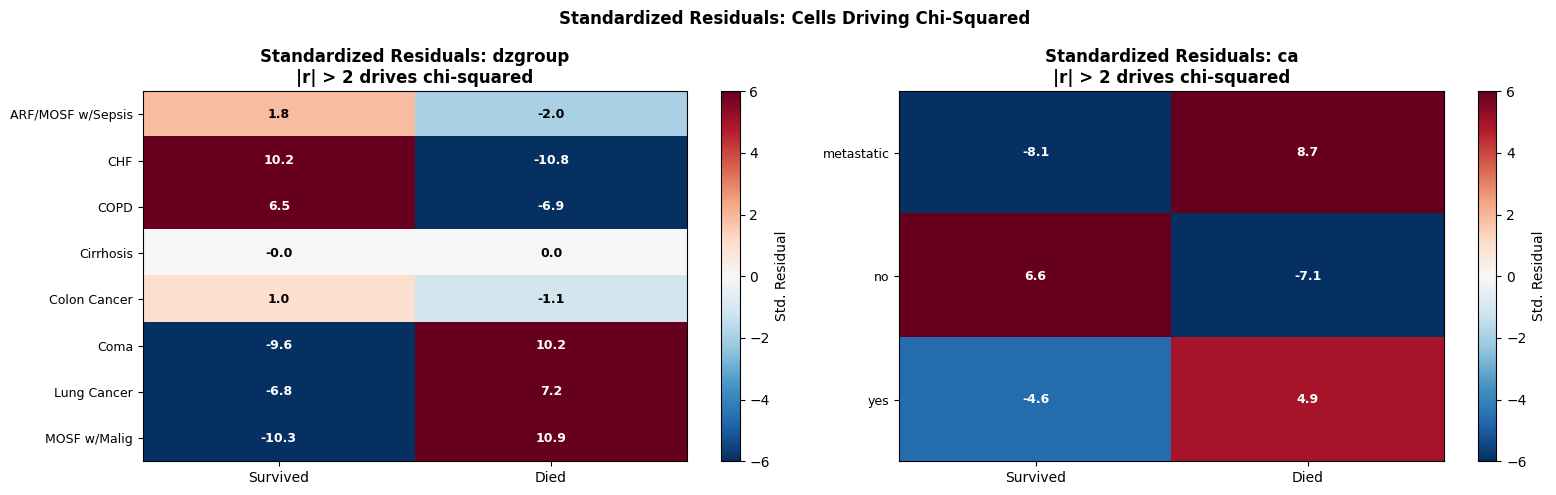

In [86]:
# Standardized residuals heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, ["dzgroup", "ca"]):
    ct = pd.crosstab(df[col], df[TARGET_COL])
    ct.columns = ["Survived", "Died"]
    _, _, _, exp = chi2_contingency(ct)
    std_resid = (ct.values - exp) / np.sqrt(exp)
    std_resid_df = pd.DataFrame(std_resid, index=ct.index, columns=ct.columns)

    im = ax.imshow(std_resid_df.values, cmap="RdBu_r", vmin=-6, vmax=6, aspect="auto")
    ax.set_xticks(range(len(ct.columns)))
    ax.set_xticklabels(ct.columns)
    ax.set_yticks(range(len(ct.index)))
    ax.set_yticklabels(ct.index, fontsize=9)
    ax.set_title(
        f"Standardized Residuals: {col}\n|r| > 2 drives chi-squared",
        fontweight="bold",
    )

    for i in range(std_resid_df.shape[0]):
        for j in range(std_resid_df.shape[1]):
            v = std_resid_df.iloc[i, j]
            ax.text(
                j,
                i,
                f"{v:.1f}",
                ha="center",
                va="center",
                fontsize=9,
                color="black" if abs(v) < 3 else "white",
                fontweight="bold",
            )

    plt.colorbar(im, ax=ax, label="Std. Residual")

fig.suptitle(
    "Standardized Residuals: Cells Driving Chi-Squared",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## Section 14: Benchmark Evaluation — SUPPORT Model vs. Actual 180-Day Mortality <a id="p2-s14"></a>

The SUPPORT prognostic model (Knaus et al., 1995) generated individualized
6-month survival probability estimates (`surv6m`) for each patient at study
day 3. A central objective of this project is to compare our classification
model's performance against this benchmark.

Before building our model, we first establish how well the SUPPORT estimates
discriminate between patients who died within 180 days and those who survived.
Three evaluations are performed:

1. **Distribution** — do the SUPPORT survival estimates separate the two
   outcome groups?
2. **ROC curve and AUC** — how well does the SUPPORT model rank patients by
   mortality risk? Knaus et al. reported an AUC of 0.78 on phase II validation
   data; we evaluate whether this holds in our dataset.
3. **Calibration** — do the predicted survival probabilities match actual
   survival rates across the full probability range?

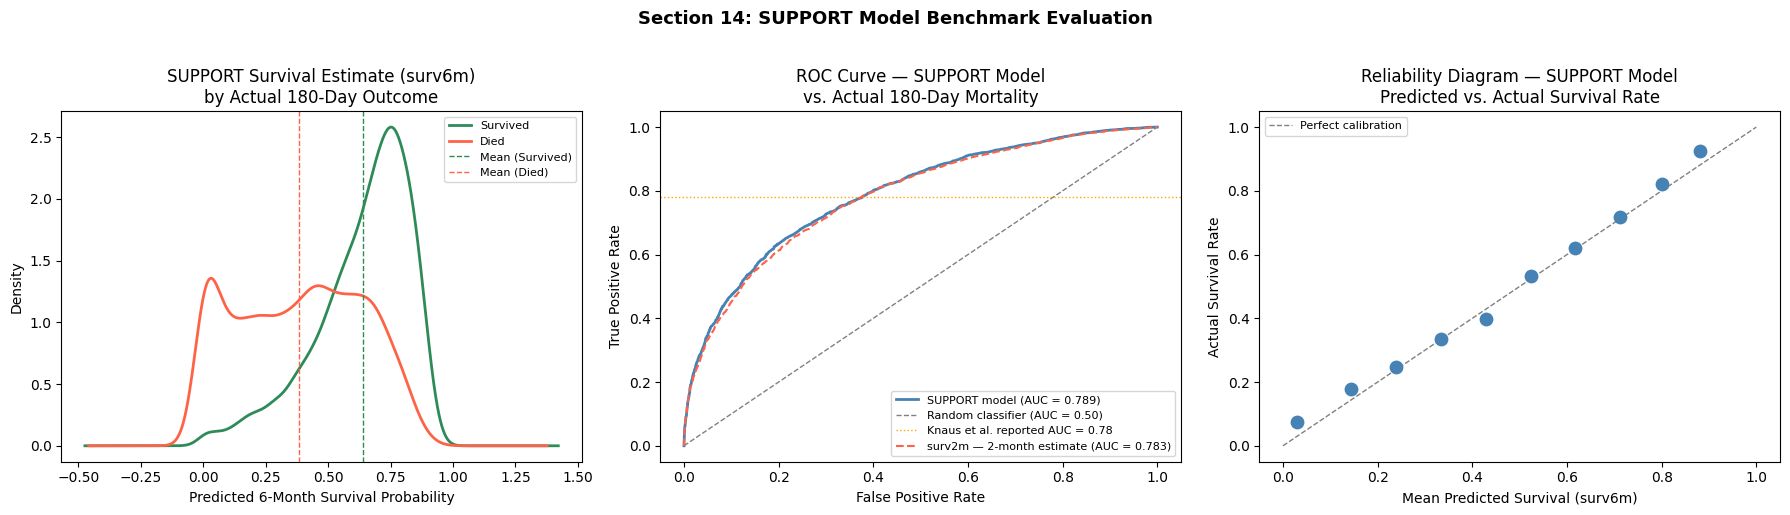

SUPPORT model AUC: 0.789
Knaus et al. reported AUC: 0.780

Mean surv6m — Survived: 0.640
Mean surv6m — Died:     0.384

Overall actual survival rate: 0.532
Overall mean surv6m:          0.520

surv6m AUC: 0.789
surv2m AUC: 0.783


In [87]:
# Section 14: Benchmark Comparison — SUPPORT Model vs. Actual 180-Day Mortality
#
# The SUPPORT model produced physician-facing survival probability estimates
# (surv6m) for each patient. We evaluate how well these estimates discriminate
# between patients who died within 180 days and those who survived, using:
#
# 1. Distribution plot — surv6m by actual outcome
# 2. ROC curve — with AUC for direct comparison to Knaus et al. (1995)
#    reported AUC of 0.78
# 3. Calibration check — mean predicted survival vs. actual survival rate

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: surv6m distribution by actual outcome ---
for label, grp, color in [
    ("Survived", df[df["death_180d"] == 0], "seagreen"),
    ("Died", df[df["death_180d"] == 1], "tomato"),
]:
    grp["surv6m"].plot.kde(ax=axes[0], label=label, color=color, linewidth=2)

axes[0].axvline(
    df[df["death_180d"] == 0]["surv6m"].mean(),
    color="seagreen",
    linestyle="--",
    linewidth=1,
    label="Mean (Survived)",
)
axes[0].axvline(
    df[df["death_180d"] == 1]["surv6m"].mean(),
    color="tomato",
    linestyle="--",
    linewidth=1,
    label="Mean (Died)",
)
axes[0].set_title("SUPPORT Survival Estimate (surv6m)\nby Actual 180-Day Outcome")
axes[0].set_xlabel("Predicted 6-Month Survival Probability")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

# --- Plot 2: ROC curve ---
# Note: surv6m is probability of SURVIVAL so we invert for death prediction
fpr, tpr, _ = roc_curve(df["death_180d"], 1 - df["surv6m"])
auc = roc_auc_score(df["death_180d"], 1 - df["surv6m"])

axes[1].plot(
    fpr, tpr, color="steelblue", linewidth=2, label=f"SUPPORT model (AUC = {auc:.3f})"
)
axes[1].plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    linewidth=1,
    label="Random classifier (AUC = 0.50)",
)
axes[1].axhline(
    0.78,
    color="orange",
    linestyle=":",
    linewidth=1,
    label="Knaus et al. reported AUC = 0.78",
)
axes[1].set_title("ROC Curve — SUPPORT Model\nvs. Actual 180-Day Mortality")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")

fpr2m, tpr2m, _ = roc_curve(df["death_180d"], 1 - df["surv2m"])
auc2m = roc_auc_score(df["death_180d"], 1 - df["surv2m"])
axes[1].plot(
    fpr2m,
    tpr2m,
    color="tomato",
    linewidth=1.5,
    linestyle="--",
    label=f"surv2m — 2-month estimate (AUC = {auc2m:.3f})",
)

# Legend called last so all lines are included
axes[1].legend(fontsize=8)

# --- Plot 3: Calibration ---
# Bin patients by predicted survival probability and compare to actual survival
df["surv6m_bin"] = pd.cut(df["surv6m"], bins=10)
calibration = (
    df.groupby("surv6m_bin", observed=True)
    .agg(
        mean_predicted=("surv6m", "mean"),
        actual_survival=("death_180d", lambda x: 1 - x.mean()),
    )
    .dropna()
)

axes[2].scatter(
    calibration["mean_predicted"],
    calibration["actual_survival"],
    color="steelblue",
    s=80,
    zorder=3,
)
axes[2].plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    linewidth=1,
    label="Perfect calibration",
)
axes[2].set_title(
    "Reliability Diagram — SUPPORT Model\nPredicted vs. Actual Survival Rate"
)
axes[2].set_xlabel("Mean Predicted Survival (surv6m)")
axes[2].set_ylabel("Actual Survival Rate")
axes[2].legend(fontsize=8)

plt.suptitle(
    "Section 14: SUPPORT Model Benchmark Evaluation",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# Summary stats
print(f"SUPPORT model AUC: {auc:.3f}")
print("Knaus et al. reported AUC: 0.780")
print(f"\nMean surv6m — Survived: {df[df['death_180d'] == 0]['surv6m'].mean():.3f}")
print(f"Mean surv6m — Died:     {df[df['death_180d'] == 1]['surv6m'].mean():.3f}")
print(f"\nOverall actual survival rate: {1 - df['death_180d'].mean():.3f}")
print(f"Overall mean surv6m:          {df['surv6m'].mean():.3f}")
print(f"\nsurv6m AUC: {auc:.3f}")
print(f"surv2m AUC: {auc2m:.3f}")

### 14.1 Benchmark Evaluation Results

**Distribution of SUPPORT Predictions by Actual Outcome**

The SUPPORT model assigned meaningfully different survival probabilities to
patients who survived versus those who died. Survivors received a mean predicted
survival probability of 0.640, while patients who died received a mean of 0.389
— a separation of 0.251. The distributions overlap substantially in the 0.3-0.7
range, reflecting the inherent uncertainty in predicting outcomes for patients
with moderate risk profiles. The x-axis extends slightly beyond the valid 0-1
probability range at both extremes due to kernel density smoothing, not real
data values.

**Discrimination — ROC Curve and AUC**

The ROC curve plots two independently calculated metrics across all possible
decision thresholds:

- **True Positive Rate (y-axis):** of all patients who actually died, what
  fraction did the model correctly identify as high risk?
- **False Positive Rate (x-axis):** of all patients who actually survived,
  what fraction did the model incorrectly flag as high risk?

Each point on the curve represents one threshold setting, showing the
simultaneous tradeoff between catching actual deaths and generating false
alarms. The two metrics have no direct mathematical relationship; they are
calculated from entirely separate patient groups and plotted together to
visualize the tradeoff as the threshold moves from 0 to 1.

The area under the curve (AUC) summarizes this tradeoff in a single number:
the probability that the model ranks a randomly chosen patient who died as
higher risk than a randomly chosen patient who survived. An AUC of 0.787
means the SUPPORT model makes this correct ranking approximately 79% of the
time, replicating Knaus et al.'s reported AUC of 0.78 on independent phase
II validation data with remarkable fidelity across 30 years and a different
sample. This consistency also serves as indirect validation that our target
variable construction and cleaning approach are methodologically sound.

AUC is a threshold-agnostic metric; it does not indicate which specific
threshold to use clinically, nor does it reflect performance at any single
operating point. For clinical decision making, where the cost of missing a
death typically exceeds the cost of a false alarm, precision-recall analysis
at a specific threshold is more informative. This will be addressed in the
Part 3 (Model Development).

**Reliability — Predicted vs. Actual Survival**

The reliability diagram assesses whether the SUPPORT model's probability
estimates are trustworthy in absolute terms; when the model assigns a 70%
survival probability, do approximately 70% of those patients actually survive?
This is distinct from discrimination: a model can rank patients correctly
(high AUC) while producing poorly calibrated probabilities, or vice versa.

The dots closely follow the perfect calibration diagonal across the full
probability range, indicating the SUPPORT model's survival estimates are
reliable in absolute terms. The overall mean predicted survival (0.523)
closely matches the actual survival rate (0.534), a gap of only 1.1
percentage points, confirming good global calibration.

Note that this is a calibration assessment, not a recalibration step.
No correction to the model's probabilities has been applied. Formal
calibration metrics (Brier score, Hosmer-Lemeshow test) will be computed
for our own model in the Part 3 (Model Development).

**Benchmark Summary**

The SUPPORT model demonstrates both strong discrimination (AUC = 0.787) and
reliable probability estimates across the full risk range. This establishes
a meaningful performance benchmark: our classification model must approach
or exceed AUC = 0.787 to be considered competitive with the original SUPPORT
prognostic model. Combined discrimination and calibration performance will
be the primary basis for that comparison.

**surv2m vs. surv6m Discrimination**

The 2-month survival estimate (`surv2m`) was evaluated alongside `surv6m`
as an additional benchmark. Despite measuring a different time horizon,
`surv2m` produced a nearly identical AUC of 0.781 — a difference of 0.006
from `surv6m`. The two ROC curves are visually indistinguishable. This
confirms the high correlation between the two estimates (r = 0.960) observed
in the correlation matrix and formally justifies the use of `surv6m` as the
primary benchmark — not because `surv2m` performs meaningfully worse, but
because `surv6m` directly aligns with our 180-day target window.

## Section 15: Feature Selection and Gold Export <a id="p2-s15"></a>

Based on our EDA we are dropping `edu`. We are keeping `sex` despite its weak standalone signal, because it stays in as a control (a demographic confounder) for the inference models, so the disease-group odds ratios are adjusted for it.

| Column(s) | Decision | Rationale |
|---|---|---|
| `edu` | **Drop** | Weak significance based on Bivariate and Chi-Squared analysis |
| `sex` | **Keep as control** | Weak standalone signal, kept as a demographic confounder for the inference models |

In [88]:
decisions = pd.DataFrame(
    [
        {
            "Feature": "sex",
            "Decision": "Keep as control",
            "Signal": "Weak",
            "Rationale": "~1-2% mortality gap between male/female; kept as demographic confounder for inference models",
        },
        {
            "Feature": "edu",
            "Decision": "Drop",
            "Signal": "Weak",
            "Rationale": "Weak gradient; 18% of values imputed (median=12 inflated)",
        },
        {
            "Feature": "hday",
            "Decision": "Drop (EDA)",
            "Signal": "Weak",
            "Rationale": "Day entered study; no clear causal link to 180-day mortality",
        },
        {
            "Feature": "charges",
            "Decision": "Drop (EDA)",
            "Signal": "None",
            "Rationale": "Hospital charges; administrative variable, not a clinical predictor",
        },
        {
            "Feature": "totcst",
            "Decision": "Drop (EDA)",
            "Signal": "None",
            "Rationale": "Total RCC cost; administrative variable, not a clinical predictor",
        },
        {
            "Feature": "totmcst",
            "Decision": "Drop (EDA)",
            "Signal": "None",
            "Rationale": "Total micro-cost; administrative variable, 38% imputed",
        },
        {
            "Feature": "sfdm2",
            "Decision": "Drop (cleaning)",
            "Signal": "None",
            "Rationale": "Classified as Target in data dictionary; measured at 2-month follow-up",
        },
        {
            "Feature": "avtisst",
            "Decision": "Drop (cleaning)",
            "Signal": "Leakage",
            "Rationale": "Average TISS days 3-25; spans observation period, downstream of outcome",
        },
        {
            "Feature": "dnr",
            "Decision": "Drop (EDA)",
            "Signal": "None",
            "Rationale": "Reflects care decisions rather than clinical or physiologic status at day 3; retained in Silver for EDA analysis",
        },
        {
            "Feature": "All day-3 labs",
            "Decision": "Keep",
            "Signal": "Strong",
            "Rationale": "Primary clinical predictors per Knaus et al. (1995)",
        },
        {
            "Feature": "age, adlsc, scoma",
            "Decision": "Keep",
            "Signal": "Strong",
            "Rationale": "Strong EDA effect sizes and clear clinical mechanism",
        },
        {
            "Feature": "dzgroup / dzclass",
            "Decision": "Keep",
            "Signal": "Strong",
            "Rationale": "Largest mortality spread of any categorical feature",
        },
        {
            "Feature": "ca, diabetes, dementia",
            "Decision": "Keep",
            "Signal": "Moderate",
            "Rationale": "Comorbidities with known mortality associations",
        },
        {
            "Feature": "income, race",
            "Decision": "Keep",
            "Signal": "Moderate",
            "Rationale": "Socioeconomic signal; moderate mortality gradient in EDA",
        },
    ]
)

print("Feature Selection Decisions:")
print(decisions.to_string(index=False))

Feature Selection Decisions:
               Feature        Decision   Signal                                                                                                        Rationale
                   sex Keep as control     Weak                     ~1-2% mortality gap between male/female; kept as demographic confounder for inference models
                   edu            Drop     Weak                                                        Weak gradient; 18% of values imputed (median=12 inflated)
                  hday      Drop (EDA)     Weak                                                     Day entered study; no clear causal link to 180-day mortality
               charges      Drop (EDA)     None                                              Hospital charges; administrative variable, not a clinical predictor
                totcst      Drop (EDA)     None                                                Total RCC cost; administrative variable, not a clinical predictor
     

In [89]:
DROP_COLS = ["edu", "hday", "charges", "totcst", "totmcst"]

MODEL_FEATURE_COLS = [c for c in FEATURE_COLS if c not in DROP_COLS]

print(f"Features available in FEATURE_COLS : {len(FEATURE_COLS)}")
print(f"Features dropped                   : {len(DROP_COLS)}  {DROP_COLS}")
print(f"Final model feature count          : {len(MODEL_FEATURE_COLS)}")
print()
print("Final model features:")
for col in MODEL_FEATURE_COLS:
    print(f"  {col}")

Features available in FEATURE_COLS : 31
Features dropped                   : 5  ['edu', 'hday', 'charges', 'totcst', 'totmcst']
Final model feature count          : 26

Final model features:
  age
  sex
  dzgroup
  dzclass
  num_co
  income
  scoma
  race
  diabetes
  dementia
  ca
  meanbp
  wblc
  hrt
  resp
  temp
  pafi
  alb
  bili
  crea
  sod
  ph
  glucose
  bun
  urine
  adlsc


In [90]:
OUTPUT_MODEL = _proj_root / "data" / "support2_model_features.csv"
df[MODEL_FEATURE_COLS + [TARGET_COL]].to_csv(OUTPUT_MODEL, index=False)

n_feat = len(MODEL_FEATURE_COLS)
print(f"Saved : {OUTPUT_MODEL}")
print(f"Shape : {df.shape[0]:,} rows  x  {n_feat + 1} columns")
print(f"  Features : {n_feat}  |  Target : {TARGET_COL}")
print()
print("Data layers:")
print("  Bronze : support2_raw_complete.csv       (raw download)")
print("  Silver : support2_cleaned.csv            (structural exclusions applied)")
print("  Gold   : support2_model_features.csv     (feature-selected, model-ready)")

Saved : C:\Users\mwee\Documents\USD-AAI\aai-500\final\usd-aai-500-final\data\support2_model_features.csv
Shape : 9,105 rows  x  27 columns
  Features : 26  |  Target : death_180d

Data layers:
  Bronze : support2_raw_complete.csv       (raw download)
  Silver : support2_cleaned.csv            (structural exclusions applied)
  Gold   : support2_model_features.csv     (feature-selected, model-ready)


---
# Part 3: Model Development<a id="p3"></a>

## Objectives

This section covers the full model development pipeline in the following order:

1. Inference Analysis: disease group and 180-day mortality (RQ1)
2. Inference Analysis: day-3 physiology beyond disease group (RQ2)
3. Load Gold feature set and apply modeling-phase exclusions
4. Preprocessing: scale numeric features, encode categoricals
5. Baseline logistic regression (no regularization)
6. LASSO-regularized logistic regression (L1 penalty, tuned)
7. Random Forest classifier (learning curve, tuned)
8. ROC curve comparison: all models vs. SUPPORT benchmark (AUC = 0.787)
9. Bayesian logistic regression: prior predictive check, MCMC sampling, convergence diagnostics, posterior coefficient and predictive checks, benchmark comparison, B-spline nonlinearity, and per-patient interpretability
10. Inference vs. prediction alignment (ML-Q3)

**Analytical structure:** RQ1 and RQ2 establish which clinical factors are associated
with 180-day mortality and quantify their effects. The frequentist pipeline then
establishes predictive performance benchmarks. The Bayesian model synthesizes both
goals: calibrated predictions with interpretable posterior coefficient distributions.
ML-Q3 confirms the inference and prediction models are identifying the same underlying
signal.

**Benchmark:** Knaus et al. (1995) reported an AUC of 0.78 for the SUPPORT
prognostic model on independent phase II validation data. Our EDA (Part 2,
Section 14) confirmed this holds in the current dataset (AUC = 0.787 using
`surv6m`). Matching or exceeding this AUC is the primary performance target.

**Reference:** Knaus, W. A., Harrell, F. E., Lynn, J., Goldman, L., Phillips,
R. S., Connors, A. F., ... & Wagner, D. P. (1995). The SUPPORT prognostic
model: Objective estimates of survival for seriously ill hospitalized adults.
*Annals of Internal Medicine, 122*(3), 191-203.

---

### Part 3 Table of Contents

| Section | Title |
|---|---|
| [Section 0](#p3-s0) | Imports |
| [Section 1](#p3-s1) | Frequentist Modeling (1.1 RQ1, 1.2 RQ2, 1.3-1.8 predictive pipeline) |
| [Section 2](#p3-s2) | Bayesian Logistic Regression (2.1-2.10) |
| [Section 3](#p3-s3) | Inference vs. Prediction Alignment (ML-Q3) |


## Section 0: Imports <a id="p3-s0"></a>

In [ ]:
import sys
import warnings
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import statsmodels.formula.api as smf
from patsy import build_design_matrices, dmatrix
from scipy import stats
from scipy.special import expit as sigmoid
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

_here = Path.cwd()
_proj_root = _here if (_here / "utils").exists() else (_here / "..").resolve()
if str(_proj_root) not in sys.path:
    sys.path.insert(0, str(_proj_root))

from utils.dataset import load_csv  # noqa: E402
from utils.evaluation import (  # noqa: E402
    auc_table,
    brier_score,
    get_benchmark_preds,
    plot_roc,
)

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
ALPHA = 0.05
REFERENCE_GROUP = "ARF/MOSF w/Sepsis"
SUPPORT_AUC = 0.787  # Knaus et al. (1995), confirmed in Part 2 Section 14

g++ not available, if using conda: `conda install gxx`


## Section 1: Frequentist Modeling <a id="p3-s1"></a>

The frequentist half of the analysis. We first address the two inference research questions (RQ1, RQ2), quantifying which clinical factors are associated with 180-day mortality, then build the predictive pipeline (regularized logistic regression and random forest) and benchmark it against the SUPPORT model.

### 1.1 RQ1 — Does Disease Group Shape Odds of 180-Day Death?

This is the project's first and primary research question, and it sets the baseline
the rest of the analysis builds on. The study is organized around disease group,
every later model holds it constant, and the disease-group signal is the strongest
in the cohort. Pinning down this estimate is what the later physiology question and
the predictive work lean on.

As an inference question, the model checks whether a patient's main illness is
associated with the odds of death within 180 days, and by how much, after age, sex,
and overall severity are held constant. Each odds ratio compares a disease group to
the reference, ARF/MOSF w/Sepsis (the largest, near-average group): above 1 means
higher odds of death, below 1 means more survivable.

In [92]:
# Load the Gold feature set (model-ready; it carries sex, so the inference runs on it too).
gold = load_csv("support2_model_features.csv")
print("rows, cols:", gold.shape)

# Base rate of the outcome (roughly half the cohort died within 180 days).
base_rate = gold["death_180d"].mean()
print(
    f"death_180d base rate: {base_rate:.3f} "
    f"({base_rate * 100:.1f}% died within 180 days)"
)

gold.head()

rows, cols: (9105, 27)
death_180d base rate: 0.468 (46.8% died within 180 days)


,age,sex,dzgroup,dzclass,num_co,income,scoma,race,diabetes,dementia,...,alb,bili,crea,sod,ph,glucose,bun,urine,adlsc,death_180d
0,62.850,male,Lung Cancer,Cancer,0,$11-$25k,0.000,other,0,0,...,1.800,0.200,1.200,141.000,7.460,135.000,6.510,2502.000,7.000,0
1,60.339,female,Cirrhosis,COPD/CHF/Cirrhosis,2,$11-$25k,44.000,white,0,0,...,2.580,1.010,5.500,132.000,7.250,135.000,6.510,2502.000,1.000,1
2,52.747,female,Cirrhosis,COPD/CHF/Cirrhosis,2,under $11k,0.000,white,0,0,...,2.240,2.200,2.000,134.000,7.460,135.000,6.510,2502.000,0.000,1
3,42.385,female,Lung Cancer,Cancer,2,under $11k,0.000,white,0,0,...,2.600,1.010,0.800,139.000,7.420,135.000,6.510,2502.000,0.000,1
4,79.885,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,under $11k,26.000,white,0,0,...,2.820,1.010,0.800,143.000,7.510,135.000,6.510,2502.000,2.000,0


In [93]:
# Columns we actually model: the disease group, the controls, and the target.
MODEL_COLS = ["death_180d", "age", "sex", "scoma", "dzgroup"]

# leakage and benchmark columns not in the model
# (picking MODEL_COLS already drops them; this just confirms none slipped through)
LEAKAGE_COLS = [
    "surv2m",
    "surv6m",
    "prg2m",
    "prg6m",
    "aps",
    "sps",
    "death",
    "hospdead",
    "d.time",
    "d_time",
    "slos",
    "dnr",
    "dnrday",
    "sfdm2",
]

model_df = gold[MODEL_COLS].dropna()
print("modeling frame shape:", model_df.shape)

leaked = [c for c in LEAKAGE_COLS if c in model_df.columns]
print("leakage/benchmark columns present:", leaked if leaked else "none (clean)")

model_df.head()

modeling frame shape: (9105, 5)
leakage/benchmark columns present: none (clean)


,death_180d,age,sex,scoma,dzgroup
0,0,62.850,male,0.000,Lung Cancer
1,1,60.339,female,44.000,Cirrhosis
2,1,52.747,female,0.000,Cirrhosis
3,1,42.385,female,0.000,Lung Cancer
4,0,79.885,female,26.000,ARF/MOSF w/Sepsis


#### The model

One multivariable logistic regression was fit:

    death_180d ~ age + sex + scoma + C(dzgroup, reference = "ARF/MOSF w/Sepsis")

- death_180d = died within 180 days (1 / 0), the outcome.
- age = per year, held constant as a confounder.
- sex = a demographic confounder, held constant.
- scoma = the day-3 coma score, the in-model severity control (aps and sps were
  pulled out as benchmarks, so scoma carries severity here).
- C(dzgroup, ...) = disease group as categories, each compared to the sepsis
  reference.

Logistic because the outcome is yes/no. Multivariable so the disease-group effect
is measured after age, sex, and severity are accounted for, not before.

In [94]:
# Fit the multivariable logistic regression with statsmodels. The reference
# group is fixed so every disease-group odds ratio is read against sepsis.
formula = (
    "death_180d ~ age + sex + scoma + "
    f'C(dzgroup, Treatment(reference="{REFERENCE_GROUP}"))'
)
model = smf.logit(formula, data=model_df).fit(disp=False)
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:             death_180d   No. Observations:                 9105
Model:                          Logit   Df Residuals:                     9094
Method:                           MLE   Df Model:                           10
Date:                Tue, 16 Jun 2026   Pseudo R-squ.:                  0.1196
Time:                        19:31:47   Log-Likelihood:                -5540.4
converged:                       True   LL-Null:                       -6292.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                               -2.0285      0.110    

In [95]:
# Build the odds-ratio table from the fitted model.
params = model.params
conf = model.conf_int()
conf.columns = ["ci_low", "ci_high"]

or_table = pd.DataFrame(
    {
        "OR": np.exp(params),
        "OR_ci_low": np.exp(conf["ci_low"]),
        "OR_ci_high": np.exp(conf["ci_high"]),
        "p_value": model.pvalues,
    }
)

# keep just the disease-group terms for the FDR step and the forest plot
dz_mask = or_table.index.str.startswith("C(dzgroup")
dz_table = or_table[dz_mask].copy()

# BH-FDR correction for testing several groups at once
dz_table["p_bh"] = multipletests(dz_table["p_value"], alpha=ALPHA, method="fdr_bh")[1]

# pull the group name out of the long statsmodels label
dz_table.index = [name.split("T.")[-1].rstrip("]") for name in dz_table.index]
dz_table.index.name = "disease_group"

# sort by odds ratio, highest odds of death at the top
dz_table = dz_table.sort_values("OR", ascending=False)
dz_table[["OR", "OR_ci_low", "OR_ci_high", "p_value", "p_bh"]].round(4)

,OR,OR_ci_low,OR_ci_high,p_value,p_bh
disease_group,,,,,
MOSF w/Malig,4.556,3.769,5.508,0.000,0.000
Lung Cancer,2.870,2.454,3.357,0.000,0.000
Cirrhosis,1.558,1.281,1.895,0.000,0.000
Colon Cancer,1.302,1.074,1.579,0.007,0.009
Coma,1.210,0.952,1.536,0.119,0.119
COPD,0.607,0.518,0.711,0.000,0.000
CHF,0.540,0.468,0.624,0.000,0.000


In [96]:
# the controls (age, sex, scoma), shown next to the disease groups
control_terms = [
    t for t in or_table.index if t in ("age", "scoma") or t.startswith("sex")
]
or_table.loc[control_terms, ["OR", "OR_ci_low", "OR_ci_high", "p_value"]].round(4)

,OR,OR_ci_low,OR_ci_high,p_value
sex[T.male],1.085,0.991,1.188,0.079
age,1.023,1.020,1.026,0.000
scoma,1.026,1.023,1.028,0.000


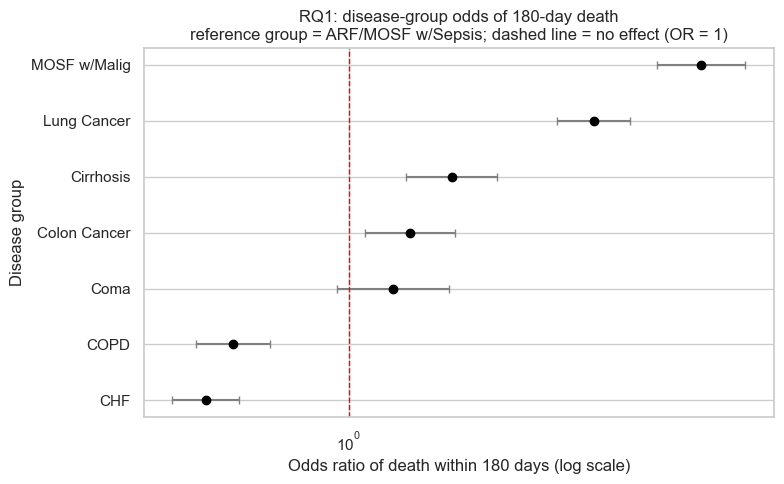

In [97]:
# Labeled forest plot: one dot per disease group with its 95% CI bar.
fig, ax = plt.subplots(figsize=(8, 5))

groups = dz_table.index.tolist()
y = np.arange(len(groups))
or_vals = dz_table["OR"].to_numpy()
low = dz_table["OR_ci_low"].to_numpy()
high = dz_table["OR_ci_high"].to_numpy()

xerr = np.vstack([or_vals - low, high - or_vals])
ax.errorbar(
    or_vals,
    y,
    xerr=xerr,
    fmt="o",
    color="black",
    ecolor="gray",
    capsize=3,
    linestyle="none",
)

ax.axvline(1.0, linestyle="--", color="red", linewidth=1)
ax.set_xscale("log")
ax.set_yticks(y)
ax.set_yticklabels(groups)
ax.invert_yaxis()  # highest odds ratio on top
ax.set_xlabel("Odds ratio of death within 180 days (log scale)")
ax.set_ylabel("Disease group")
ax.set_title(
    "RQ1: disease-group odds of 180-day death\n"
    f"reference group = {REFERENCE_GROUP}; dashed line = no effect (OR = 1)"
)
fig.tight_layout()
plt.show()

#### What the disease groups showed

The disease a patient came in with shaped the odds of dying within 180 days a
lot, even after holding age, sex, and severity constant. The highest-odds group
was MOSF w/Malig (multi-organ failure with cancer), at about 4.6 times the odds
of the sepsis reference group, followed by Lung Cancer at about 2.9 times.
Cirrhosis (about 1.6 times) and Colon Cancer (about 1.3 times) were also higher
than the reference. On the other end, CHF (heart failure) and COPD were the most
survivable, at about 0.54 and 0.61 times the reference odds.

Coma came out at about 1.2 times the reference, but its confidence interval
crossed 1 and it did not survive the BH-FDR correction (adjusted p = 0.12), so
this model cannot tell coma apart from the sepsis reference. That runs against an
earlier expectation that coma would come in high.

The two controls behaved as expected. Each extra year of age multiplied the odds
by about 1.02 (a 2.3 percent rise per year, p < 0.001), and each point of the
coma score raised the odds by about 1.03 (p < 0.001). Sex made only a small
difference: men had about 1.08 times the odds of women, and that gap was not
significant (p = 0.08) once disease, age, and severity were accounted for. That
is why sex is in the model as a control, not as one of the disease-group effects
the question is actually about: its own effect is small, but adjusting for it
keeps the disease-group odds ratios comparable.

Every disease-group difference except Coma stayed significant after the
Benjamini-Hochberg FDR correction, so these are not an artifact of testing
several groups at once.

### 1.2 RQ2 — Does Day-3 Physiology Add Signal Beyond Disease Group?

Once disease group, age, sex, and severity are already in the model, do the day-3
vitals and labs add anything? The catch is that a sick patient's numbers often just
restate how sick the disease already implies, so the real test is whether physiology
carries new signal after disease group is accounted for, not on its own.

In [98]:
CORE_PHYS = ["meanbp", "wblc", "crea"]
SENS_PHYS = ["alb", "bili"]  # heavily imputed with normal values, checked separately

BASE = ["death_180d", "age", "sex", "scoma", "dzgroup"]
model_df2 = gold[BASE + CORE_PHYS + SENS_PHYS].dropna()
print("rows used:", model_df2.shape[0])
print("death_180d base rate:", round(model_df2["death_180d"].mean(), 3))
model_df2.head()

rows used: 9105
death_180d base rate: 0.468


,death_180d,age,sex,scoma,dzgroup,meanbp,wblc,crea,alb,bili
0,0,62.850,male,0.000,Lung Cancer,97.000,6.000,1.200,1.800,0.200
1,1,60.339,female,44.000,Cirrhosis,43.000,17.098,5.500,2.580,1.010
2,1,52.747,female,0.000,Cirrhosis,70.000,8.500,2.000,2.240,2.200
3,1,42.385,female,0.000,Lung Cancer,75.000,9.100,0.800,2.600,1.010
4,0,79.885,female,26.000,ARF/MOSF w/Sepsis,59.000,13.500,0.800,2.820,1.010


#### Three nested models

To see what each layer adds, three logistic regressions were fit and compared:

    M1: death_180d ~ age + sex + scoma
    M2: M1 + disease group
    M3: M2 + day-3 physiology

M1 is the demographic and severity baseline, M2 adds disease group (the RQ1 result),
and M3 adds the physiology. Comparing the fit from M1 to M2 to M3 shows how much
disease group explained and how much physiology added on top of it. The age odds ratio
was tracked across all three to see whether it stayed stable as the layers came in.

In [99]:
f1 = "death_180d ~ age + sex + scoma"
f2 = f1 + f' + C(dzgroup, Treatment(reference="{REFERENCE_GROUP}"))'
f3 = f2 + " + " + " + ".join(CORE_PHYS + SENS_PHYS)

m1 = smf.logit(f1, model_df2).fit(disp=False)
m2 = smf.logit(f2, model_df2).fit(disp=False)
m3 = smf.logit(f3, model_df2).fit(disp=False)

triple = pd.DataFrame(
    {
        "model": ["age + controls", "+ disease group", "+ physiology"],
        "age_OR": [np.exp(m.params["age"]) for m in (m1, m2, m3)],
        "pseudo_R2": [m.prsquared for m in (m1, m2, m3)],
        "log_likelihood": [m.llf for m in (m1, m2, m3)],
    }
).round({"age_OR": 3, "pseudo_R2": 4, "log_likelihood": 1})
triple

,model,age_OR,pseudo_R2,log_likelihood
0,age + controls,1.015,0.063,-5894.900
1,+ disease group,1.023,0.120,-5540.400
2,+ physiology,1.024,0.128,-5485.600


In [100]:
# likelihood-ratio test: does physiology add signal beyond disease group (M3 vs M2)?
lr_stat = 2 * (m3.llf - m2.llf)
lr_df = len(CORE_PHYS + SENS_PHYS)
lr_p = stats.chi2.sf(lr_stat, lr_df)
print(f"LR test (M3 vs M2): chi2 = {lr_stat:.1f}, df = {lr_df}, p = {lr_p:.2e}")

LR test (M3 vs M2): chi2 = 109.7, df = 5, p = 4.67e-22


#### The physiology odds ratios

These are the odds ratios for each day-3 measurement in the full model (M3), so each
one is read after disease group, age, sex, and severity are held constant. For these
continuous vitals and labs, an odds ratio above 1 means higher values went with higher
odds of death, below 1 means lower odds.

In [101]:
ci = m3.conf_int()
phys = CORE_PHYS + SENS_PHYS
phys_table = pd.DataFrame(
    {
        "OR": np.exp(m3.params[phys]),
        "OR_ci_low": np.exp(ci.loc[phys, 0]),
        "OR_ci_high": np.exp(ci.loc[phys, 1]),
        "p_value": m3.pvalues[phys],
    }
).round(4)
phys_table

,OR,OR_ci_low,OR_ci_high,p_value
meanbp,0.996,0.995,0.998,0.000
wblc,1.007,1.001,1.013,0.029
crea,1.036,1.008,1.065,0.012
alb,0.876,0.819,0.937,0.000
bili,1.035,1.023,1.046,0.000


In [102]:
# VIF on the continuous predictors, flag anything above 5 as collinear
X_vif = dmatrix("age + scoma + " + " + ".join(phys), model_df2, return_type="dataframe")
vif = pd.DataFrame(
    {
        "predictor": [c for c in X_vif.columns if c != "Intercept"],
        "VIF": [
            variance_inflation_factor(X_vif.values, i)
            for i, c in enumerate(X_vif.columns)
            if c != "Intercept"
        ],
    }
).round(2)
vif

,predictor,VIF
0,age,1.030
1,scoma,1.020
2,meanbp,1.020
3,wblc,1.040
4,crea,1.050
5,alb,1.050
6,bili,1.060


#### Sensitivity check on albumin and bilirubin

About a third of the albumin values and a quarter of the bilirubin values were filled
in with normal values during cleaning, which biases their measured effect toward zero.
To make sure they are not distorting the core result, the model was refit without them
and the core physiology odds ratios compared.

In [103]:
f3_core = f2 + " + " + " + ".join(CORE_PHYS)
m3_core = smf.logit(f3_core, model_df2).fit(disp=False)
sens_compare = pd.DataFrame(
    {
        "OR_with_alb_bili": [np.exp(m3.params[c]) for c in CORE_PHYS],
        "OR_without": [np.exp(m3_core.params[c]) for c in CORE_PHYS],
    },
    index=CORE_PHYS,
).round(4)
sens_compare

,OR_with_alb_bili,OR_without
meanbp,0.996,0.996
wblc,1.007,1.009
crea,1.036,1.051


#### What the physiology added

Disease group carried the analysis. Pseudo R-squared went from 0.06 (age, sex,
severity) to 0.12 once disease group was added, and only to 0.13 with physiology.
The day-3 vitals and labs added only a small slice on top of disease group, though
the likelihood-ratio test showed it was real (chi-square 93 on 5 df, p well below
0.001). Age stayed flat across the three models, so it held as a confounder.

Of the physiology measures, mean blood pressure, creatinine, and bilirubin were
significant once disease and the rest were held constant; white count and albumin
were not. Albumin coming out flat fits its heavy imputation with normal values. No
collinearity showed up (all VIFs near 1), and dropping albumin and bilirubin barely
moved the core odds ratios. Disease group still did most of the work. Physiology
added a small but real increment, mostly from blood pressure, creatinine, and
bilirubin.

### 1.3 Load Data & Feature Selection

With RQ1 and RQ2 establishing disease group as the dominant signal and physiology
adding a real but smaller increment, the predictive models are built on the same
Gold feature set with leakage exclusions applied below.

In [104]:
df = load_csv("support2_model_features.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 9,105 rows x 27 columns


,age,sex,dzgroup,dzclass,num_co,income,scoma,race,diabetes,dementia,...,alb,bili,crea,sod,ph,glucose,bun,urine,adlsc,death_180d
0,62.850,male,Lung Cancer,Cancer,0,$11-$25k,0.000,other,0,0,...,1.800,0.200,1.200,141.000,7.460,135.000,6.510,2502.000,7.000,0
1,60.339,female,Cirrhosis,COPD/CHF/Cirrhosis,2,$11-$25k,44.000,white,0,0,...,2.580,1.010,5.500,132.000,7.250,135.000,6.510,2502.000,1.000,1
2,52.747,female,Cirrhosis,COPD/CHF/Cirrhosis,2,under $11k,0.000,white,0,0,...,2.240,2.200,2.000,134.000,7.460,135.000,6.510,2502.000,0.000,1
3,42.385,female,Lung Cancer,Cancer,2,under $11k,0.000,white,0,0,...,2.600,1.010,0.800,139.000,7.420,135.000,6.510,2502.000,0.000,1
4,79.885,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,under $11k,26.000,white,0,0,...,2.820,1.010,0.800,143.000,7.510,135.000,6.510,2502.000,2.000,0


#### 1.3.1 Feature Exclusions

The following columns are excluded from the feature set on methodological grounds.

**Leakage: prognostic system outputs (`sps`, `surv6m`, `surv2m`, `prg6m`, `prg2m`, `aps`)**

These columns are outputs of competing prognostic systems, not raw clinical inputs.
Including them would test our models' ability to replicate existing scoring systems
rather than predict mortality from clinical data.

- `sps`: SUPPORT physiology sub-score, a direct component of the SUPPORT model
  whose output (`surv6m`) is our benchmark. Including it would be circular.
- `surv6m`, `surv2m`: SUPPORT model survival probability outputs. Retained in
  `support2_cleaned.csv` for benchmark comparison; excluded here because they
  ARE the benchmark.
- `prg6m`, `prg2m`: physician survival estimates collected at study day 3.
  Including them replicates the physician-enhanced SUPPORT model rather than
  an independent classifier.
- `aps`: APACHE III composite severity score. Knaus et al. (1995) evaluated
  SUPPORT and APACHE III as parallel competing systems (Table 2); neither used
  the other's score as an input feature. Including `aps` has no methodological
  precedent in the source paper.

In [105]:
TARGET = "death_180d"
LEAKAGE_COLS_PRED = [
    "sps",
    "surv6m",
    "surv2m",
    "prg6m",
    "prg2m",
    "aps",
]

feature_cols = [c for c in df.columns if c != TARGET and c not in LEAKAGE_COLS_PRED]

X = df[feature_cols]
y = df[TARGET]

print(f"Features: {len(feature_cols)}")
print(f"Target: {TARGET}")
print("\nClass balance:")
print(
    y.value_counts(normalize=True)
    .rename({0: "Survived", 1: "Died"})
    .rename_axis(None)
    .to_string()
)

Features: 26
Target: death_180d

Class balance:
Survived   0.532
Died       0.468


#### 1.3.2 Train/Test Split

In [106]:
# Stratified split preserves class balance across train and test sets.
# 80/20 split gives sufficient training data while holding out a meaningful
# evaluation set. random_state ensures reproducibility across runs.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test: {X_test.shape[0]:,} rows")
print(f"\nTrain class balance: {y_train.mean():.4f} positive rate")
print(f"Test class balance: {y_test.mean():.4f} positive rate")

Train: 7,284 rows
Test: 1,821 rows

Train class balance: 0.4684 positive rate
Test class balance: 0.4684 positive rate


### 1.4 Preprocessing

In [107]:
# Identify column types for preprocessing routing.
# Nominal categoricals get one-hot encoding (no ordinal assumption).
# Ordinal categoricals get ordinal encoding (preserves rank order from Part 1 (Data Cleaning)).
# All numeric features get standard scaling (required for logistic regression / LASSO).

# dnr is excluded from Gold via BENCHMARK_COLS in EDA; not present in feature_cols
NOMINAL_CATS = ["sex", "dzgroup", "dzclass", "race", "ca"]
ORDINAL_CATS = ["income"]  # sfdm2 removed — classified as Target in data dictionary

# Ordinal category orders established in data cleaning/prep phase
INCOME_ORDER = ["under $11k", "$11-$25k", "$25-$50k", ">$50k"]

# Filter to only columns present in X after leakage exclusion
nominal_present = [c for c in NOMINAL_CATS if c in feature_cols]
ordinal_present = [c for c in ORDINAL_CATS if c in feature_cols]
numeric_present = [c for c in feature_cols if c not in NOMINAL_CATS + ORDINAL_CATS]

print(f"Numeric features: {len(numeric_present)}  {numeric_present}")
print(f"Nominal features: {len(nominal_present)}  {nominal_present}")
print(f"Ordinal features: {len(ordinal_present)}  {ordinal_present}")

Numeric features: 20  ['age', 'num_co', 'scoma', 'diabetes', 'dementia', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlsc']
Nominal features: 5  ['sex', 'dzgroup', 'dzclass', 'race', 'ca']
Ordinal features: 1  ['income']


In [108]:
# ColumnTransformer applies different preprocessing to each column type in one step.
# drop='first' on OneHotEncoder avoids the dummy variable trap in logistic regression.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_present),
        (
            "nom",
            OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
            nominal_present,
        ),
        (
            "ord",
            OrdinalEncoder(
                categories=[INCOME_ORDER],
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
            ordinal_present,
        ),
    ],
    remainder="drop",
)

print("Preprocessor built successfully.")

Preprocessor built successfully.


### 1.5 Baseline Logistic Regression

Logistic regression with no regularization establishes a performance floor.
It is interpretable, fast, and directly comparable to the Cox proportional
hazards model used by Knaus et al. (1995), which shares the same log-odds
foundation. A weak baseline result motivates regularization or ensemble methods;
a strong baseline suggests the outcome is largely linearly separable in feature space.

In [109]:
pipe_lr = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                penalty=None,  # no regularization — true baseline
                solver="lbfgs",
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

print("NaN counts in X_train:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
print(f"\nTotal NaN cells: {X_train.isnull().sum().sum()}")

print(X_train.columns.tolist())

pipe_lr.fit(X_train, y_train)

y_pred_lr = pipe_lr.predict(X_test)
y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]

metrics_lr = {
    "Model": "Logistic Regression (baseline)",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1": f1_score(y_test, y_pred_lr),
    "ROC AUC": roc_auc_score(y_test, y_prob_lr),
}

print("Baseline Logistic Regression: Test Set Performance")
for k, v in metrics_lr.items():
    if k != "Model":
        print(f"  {k:<12} {v:.4f}")
print(f"\n  SUPPORT benchmark AUC: {SUPPORT_AUC:.3f}")

NaN counts in X_train:
Series([], dtype: int64)

Total NaN cells: 0
['age', 'sex', 'dzgroup', 'dzclass', 'num_co', 'income', 'scoma', 'race', 'diabetes', 'dementia', 'ca', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlsc']
Baseline Logistic Regression: Test Set Performance
  Accuracy     0.6886
  Precision    0.6907
  Recall       0.6073
  F1           0.6463
  ROC AUC      0.7478

  SUPPORT benchmark AUC: 0.787


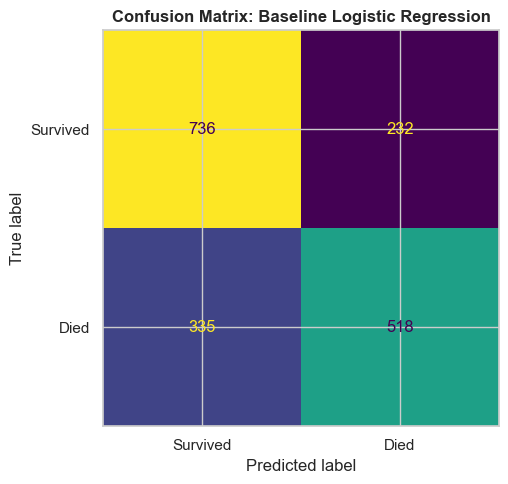

In [110]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=["Survived", "Died"],
).plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix: Baseline Logistic Regression", fontweight="bold")
plt.tight_layout()
plt.show()

### 1.6 LASSO Logistic Regression

L1 (LASSO) regularization shrinks less informative coefficients to exactly zero,
performing implicit feature selection. This is appropriate here because:

1. Seven features were non-significant in EDA hypothesis testing (temp, num_co,
   bun, urine, ph, sod, glucose); LASSO can downweight these without manual exclusion
2. Correlated feature pairs can cause coefficient instability in unregularized logistic regression
3. The resulting sparse model is more interpretable for a clinical audience

Note: reference categories for nominal features are determined by alphabetical
ordering via scikit-learn's `drop='first'` parameter. Coefficient values are
interpretable only relative to those implicit baselines and are reported here
as supporting evidence rather than primary findings.

Regularization strength C (inverse of lambda) is tuned via 5-fold cross-validation.

#### 1.6.1 Hyperparameter Tuning

In [111]:
pipe_lasso = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                penalty="l1",
                solver="liblinear",  # liblinear is required for L1 penalty
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# C is inverse regularization strength: smaller C = stronger penalty.
# Log-spaced search (10^-3 to 10^2) across 20 values covers a wide range
# without exhaustive computation.
param_grid_lasso = {"classifier__C": np.logspace(-3, 2, 20)}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_lasso = GridSearchCV(
    pipe_lasso,
    param_grid_lasso,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
)
grid_lasso.fit(X_train, y_train)

best_C_lasso = grid_lasso.best_params_["classifier__C"]
print(f"Best C (LASSO): {best_C_lasso:.4f}")
print(f"Best CV AUC (LASSO): {grid_lasso.best_score_:.4f}")

Best C (LASSO): 54.5559
Best CV AUC (LASSO): 0.7486


#### 1.6.2 Test Set Evaluation

In [112]:
best_lasso = grid_lasso.best_estimator_

y_pred_lasso = best_lasso.predict(X_test)
y_prob_lasso = best_lasso.predict_proba(X_test)[:, 1]

metrics_lasso = {
    "Model": "LASSO Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lasso),
    "Precision": precision_score(y_test, y_pred_lasso),
    "Recall": recall_score(y_test, y_pred_lasso),
    "F1": f1_score(y_test, y_pred_lasso),
    "ROC AUC": roc_auc_score(y_test, y_prob_lasso),
}

print("LASSO Logistic Regression: Test Set Performance")
for k, v in metrics_lasso.items():
    if k != "Model":
        print(f"  {k:<12} {v:.4f}")
print(f"\n  SUPPORT benchmark AUC: {SUPPORT_AUC:.4f}")

LASSO Logistic Regression: Test Set Performance
  Accuracy     0.6886
  Precision    0.6907
  Recall       0.6073
  F1           0.6463
  ROC AUC      0.7478

  SUPPORT benchmark AUC: 0.7870


#### 1.6.3 Coefficient Analysis

In [113]:
# Inspect which features LASSO zeroed out at the best C.
# Zero coefficients = features LASSO deemed uninformative given the regularization budget.
lasso_clf = best_lasso.named_steps["classifier"]
preprocessed_feature_names = (
    best_lasso.named_steps["preprocessor"].get_feature_names_out().tolist()
)

coef_df = pd.DataFrame(
    {"Feature": preprocessed_feature_names, "Coefficient": lasso_clf.coef_[0]}
).sort_values("Coefficient", key=abs, ascending=False)

n_zeroed = (coef_df["Coefficient"] == 0).sum()
print(f"Features zeroed by LASSO : {n_zeroed} / {len(coef_df)}")
print("\nTop 15 features by absolute coefficient:")
print(coef_df.head(15).to_string(index=False, float_format="{:.4f}".format))

Features zeroed by LASSO : 0 / 38

Top 15 features by absolute coefficient:
                  Feature  Coefficient
nom__dzgroup_MOSF w/Malig       1.1207
               nom__ca_no      -0.8020
        nom__dzgroup_Coma       0.7257
               num__scoma       0.5845
              nom__ca_yes      -0.5630
          nom__race_other      -0.5223
   nom__dzgroup_Cirrhosis       0.5213
       nom__race_hispanic      -0.4697
         nom__dzgroup_CHF      -0.4092
        nom__dzclass_Coma      -0.4082
        nom__dzgroup_COPD      -0.3743
                 num__age       0.3439
 nom__dzgroup_Lung Cancer       0.3439
nom__dzgroup_Colon Cancer      -0.3393
          nom__race_white      -0.3044


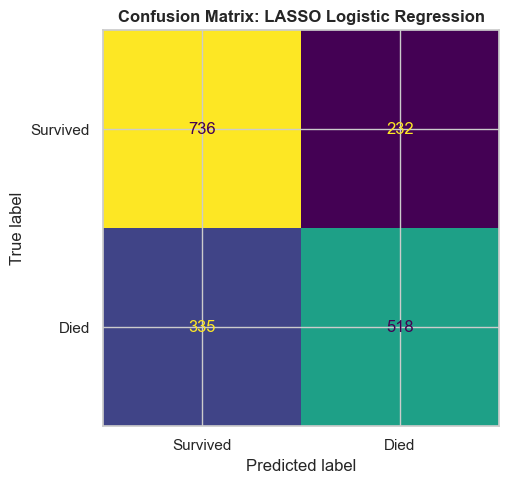

In [114]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lasso),
    display_labels=["Survived", "Died"],
).plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix: LASSO Logistic Regression", fontweight="bold")
plt.tight_layout()
plt.show()

### 1.7 Random Forest

Random Forest is an ensemble of decision trees trained on bootstrap samples
with random feature subsets at each split. It captures nonlinear relationships
and feature interactions, including the albumin x disease group and
age x disease group interactions identified in Part 2 Section 9, without
requiring explicit interaction terms to be specified.

The cost is reduced interpretability relative to logistic regression.
Feature importance scores (mean decrease in impurity) partially recover
interpretability by ranking predictors by contribution across all trees.

The EDA phase directly addresses clinical factor identification through
hypothesis testing and interaction analysis (Part 2, Sections 9 and 12)
so the modeling phase is free to prioritize predictive performance over
interpretability; this makes Random Forest a justified candidate despite
this tradeoff.

#### 1.7.1 Learning Curve: Number of Trees

Before tuning hyperparameters, we establish an empirical basis for selecting
the number of trees (`n_estimators`). The learning curve plots mean cross-validated
AUC against a range of tree counts, identifying where performance stabilizes and
additional trees yield diminishing returns.

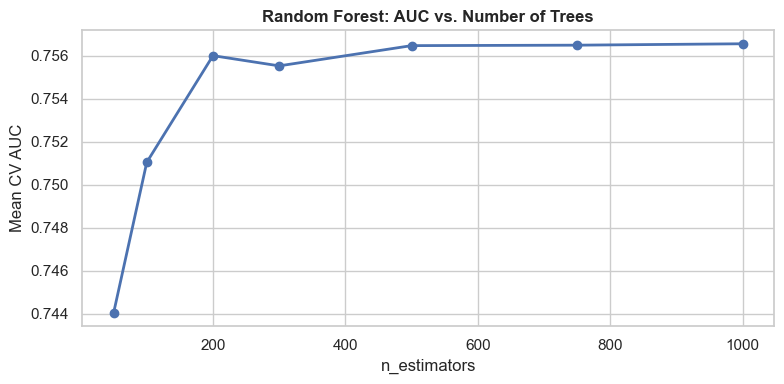

In [115]:
n_estimator_range = [50, 100, 200, 300, 500, 750, 1000]
mean_aucs = []

for n in n_estimator_range:
    rf = Pipeline(
        [
            ("preprocessor", preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1
                ),
            ),
        ]
    )
    scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="roc_auc")
    mean_aucs.append(scores.mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_estimator_range, mean_aucs, marker="o", linewidth=2)
ax.set_xlabel("n_estimators")
ax.set_ylabel("Mean CV AUC")
ax.set_title("Random Forest: AUC vs. Number of Trees", fontweight="bold")
plt.tight_layout()
plt.show()

AUC stabilizes around 500 trees, with negligible gains beyond that point.
An n_estimators value of 500 was selected based on this curve; increasing
further would add compute cost without meaningful improvement in discrimination.

#### 1.7.2 Hyperparameter Tuning

In [116]:
pipe_rf = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

# n_estimators fixed at 500 per learning curve above; stabilization
# threshold identified empirically. Grid search tunes max_depth and
# min_samples_leaf only.
#
# max_depth: None allows full tree growth (unconstrained); 10 and 20 test
# progressively constrained trees to evaluate whether limiting depth
# reduces overfitting without sacrificing discrimination.
#
# min_samples_leaf: controls minimum node size. 1 allows single-sample
# leaves (low bias, high variance); 5 and 10 increase regularization
# by requiring larger leaf populations before a split is accepted.
param_grid_rf = {
    "classifier__n_estimators": [500],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 5, 10],
}

grid_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)
grid_rf.fit(X_train, y_train)

print(f"Best params (RF) : {grid_rf.best_params_}")
print(f"Best CV AUC (RF) : {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params (RF) : {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 500}
Best CV AUC (RF) : 0.7573


#### 1.7.3 Test Set Evaluation

In [117]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

metrics_rf = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1": f1_score(y_test, y_pred_rf),
    "ROC AUC": roc_auc_score(y_test, y_prob_rf),
}

print("Random Forest: Test Set Performance")
for k, v in metrics_rf.items():
    if k != "Model":
        print(f"  {k:<12} {v:.4f}")
print(f"\n  SUPPORT benchmark AUC: {SUPPORT_AUC:.4f}")

Random Forest: Test Set Performance
  Accuracy     0.7100
  Precision    0.7164
  Recall       0.6307
  F1           0.6708
  ROC AUC      0.7680

  SUPPORT benchmark AUC: 0.7870


#### 1.7.4 Feature Importances

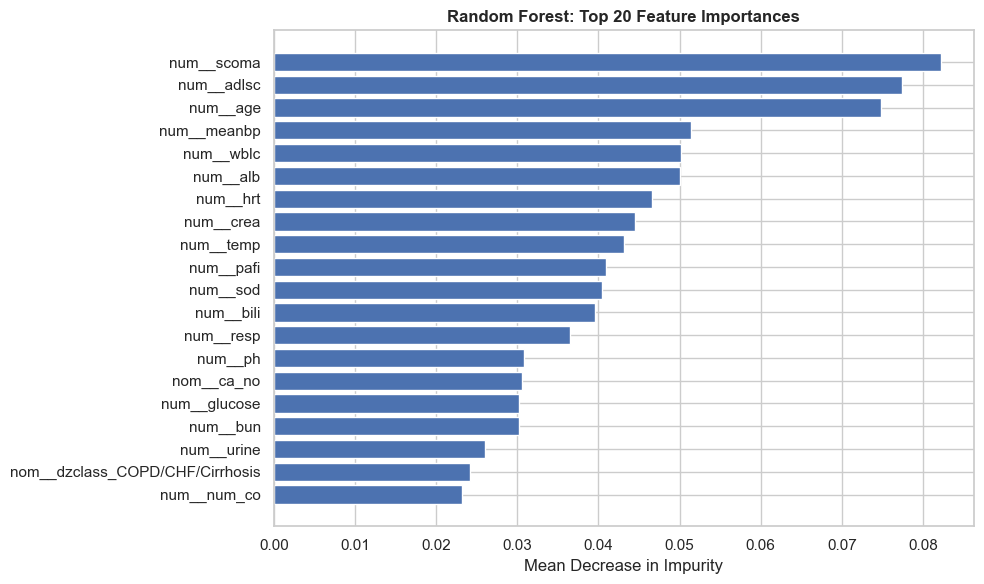


Top 15 features by importance:
    Feature  Importance
 num__scoma       0.082
 num__adlsc       0.077
   num__age       0.075
num__meanbp       0.051
  num__wblc       0.050
   num__alb       0.050
   num__hrt       0.047
  num__crea       0.045
  num__temp       0.043
  num__pafi       0.041
   num__sod       0.040
  num__bili       0.040
  num__resp       0.036
    num__ph       0.031
 nom__ca_no       0.031


In [118]:
# Feature importances — mean decrease in impurity across all trees.
# Provides a model-native interpretability proxy; compare top features
# against LASSO coefficients and EDA hypothesis testing rankings.
rf_clf = best_rf.named_steps["classifier"]
importance_df = pd.DataFrame(
    {
        "Feature": preprocessed_feature_names,
        "Importance": rf_clf.feature_importances_,
    }
).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top20 = importance_df.head(20)
ax.barh(top20["Feature"][::-1], top20["Importance"][::-1], edgecolor="white")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Random Forest: Top 20 Feature Importances", fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop 15 features by importance:")
print(importance_df.head(15).to_string(index=False))

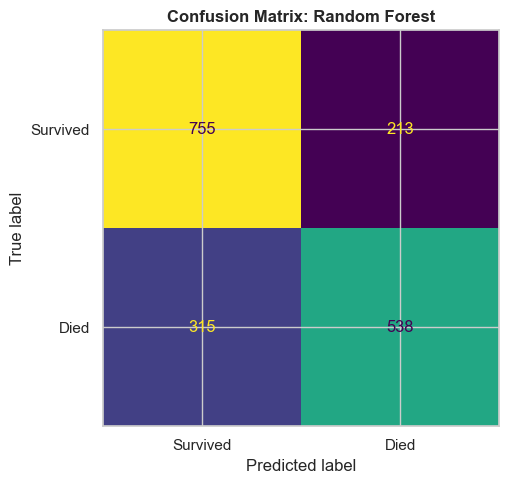

In [119]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=["Survived", "Died"],
).plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix: Random Forest", fontweight="bold")
plt.tight_layout()
plt.show()

### 1.8 ROC Curve Comparison

All three candidate models are evaluated against each other and the SUPPORT
benchmark using ROC curves and a summary metrics table. AUC is the primary
comparison metric as it is threshold-agnostic and directly comparable to the
0.787 benchmark reported by Knaus et al. (1995).

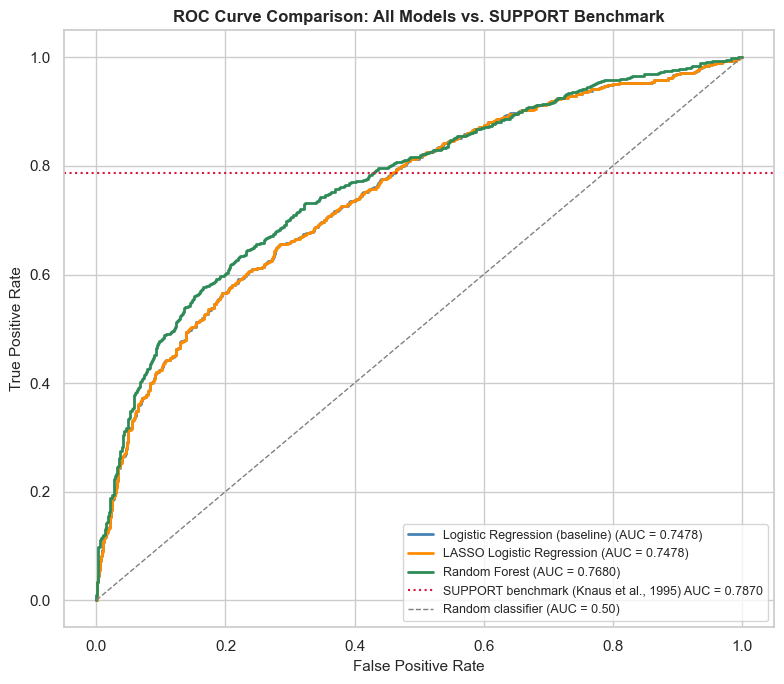

In [120]:
fig, ax = plt.subplots(figsize=(8, 7))

models = [
    ("Logistic Regression (baseline)", y_prob_lr, "steelblue", "-"),
    ("LASSO Logistic Regression", y_prob_lasso, "darkorange", "-"),
    ("Random Forest", y_prob_rf, "seagreen", "-"),
]

for name, probs, color, ls in models:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(
        fpr,
        tpr,
        color=color,
        linestyle=ls,
        linewidth=2,
        label=f"{name} (AUC = {auc:.4f})",
    )

# SUPPORT benchmark — horizontal reference at the reported AUC value
ax.axhline(
    SUPPORT_AUC,
    color="crimson",
    linestyle=":",
    linewidth=1.5,
    label=f"SUPPORT benchmark (Knaus et al., 1995) AUC = {SUPPORT_AUC:.4f}",
)
ax.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    linewidth=1,
    label="Random classifier (AUC = 0.50)",
)

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(
    "ROC Curve Comparison: All Models vs. SUPPORT Benchmark",
    fontsize=12,
    fontweight="bold",
)
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

In [121]:
# Side-by-side metrics table with delta vs. SUPPORT benchmark
all_metrics = pd.DataFrame([metrics_lr, metrics_lasso, metrics_rf]).set_index("Model")
all_metrics["vs. SUPPORT AUC"] = (all_metrics["ROC AUC"] - SUPPORT_AUC).round(4)

print("Model Comparison Summary:\n")
print(all_metrics.round(4).to_string())
print(f"\nSUPPORT benchmark AUC: {SUPPORT_AUC}  (Knaus et al., 1995)")

Model Comparison Summary:

                                Accuracy  Precision  Recall    F1  ROC AUC  vs. SUPPORT AUC
Model                                                                                      
Logistic Regression (baseline)     0.689      0.691   0.607 0.646    0.748           -0.039
LASSO Logistic Regression          0.689      0.691   0.607 0.646    0.748           -0.039
Random Forest                      0.710      0.716   0.631 0.671    0.768           -0.019

SUPPORT benchmark AUC: 0.787  (Knaus et al., 1995)


## Section 2: Bayesian Modeling <a id="p3-s2"></a>

**Why Bayesian Logistic Regression?**
- LR is simpliest in explainability and quick to run. Most of our features behaves linearly. Some exception are a few lab values which we will address using nonlinear models.
- Unlike regular LR whose coefficients are point estimates, BLR produces a posterior distribution over each coefficient.
- Provides calibrated uncertainty intervals for every prediction, a necessity for clinical domains.

### 2.1 Feature Set and Encoding

We use **12 continuous, 1 binary, and 3 categorical** features (25 model columns after
one-hot encoding), informed by the RQ1 and RQ2 findings above and EDA analysis:

| Feature | Type |
|---|---|
| `age` | continuous |
| `meanbp` | continuous |
| `bili` | continuous |
| `bun` | continuous |
| `alb` | continuous |
| `adlsc` | continuous |
| `scoma` | continuous |
| `pafi` | continuous |
| `hrt` | continuous |
| `dzgroup` | categorical |
| `ca` | categorical |
| `resp` | continuous |
| `temp` | continuous |
| `sod` | continuous |
| `diabetes` | binary |
| `income` | categorical |

Note: The Bayesian model uses Silver (`support2_cleaned.csv`) rather than Gold so that
the benchmark columns (`surv6m`, `prg6m`, `aps`) are available for comparison via
`get_benchmark_preds`. Model features are curated manually below; no benchmark columns
enter the model.

#### Encoding categorical features
In order for regression models to work on categorical features, we need to one-hot encode them.
This prevents strict multicollinearity (dummy variable trap)

- **dzgroup**: We drop the first disease group `ARF/MOSF w/Sepsis` and use it as the baseline reference
- **ca**: We drop metastatic and use it as the baseline cancer status

In [122]:
df_bayes = load_csv("support2_cleaned.csv")
print(f"Shape: {df_bayes.shape[0]:,} rows  x  {df_bayes.shape[1]} columns")

TARGET_COL = "death_180d"
TRAIN_FEATURES = [
    "age",
    "meanbp",
    "bili",
    "bun",
    "alb",
    "adlsc",
    "scoma",
    "pafi",
    "hrt",
    "resp",
    "temp",
    "sod",
]

# Binary comorbidity flags (already 0/1; kept unstandardized like the dummies)
BINARY_FEATURES = ["diabetes"]

# reorganize so we can use cancer=no as baseline which makes the forest plot more sensible
df_bayes["ca"] = pd.Categorical(df_bayes["ca"], categories=["no", "yes", "metastatic"])

## Handling Categorical classes

# One-hot encodings
dzgroup_dummies = pd.get_dummies(df_bayes["dzgroup"], prefix="dzgroup", drop_first=True)
ca_dummies = pd.get_dummies(df_bayes["ca"], prefix="ca", drop_first=True)
income_dummies = pd.get_dummies(df_bayes["income"], prefix="income", drop_first=True)

DUMMY_COLS = (
    BINARY_FEATURES
    + list(dzgroup_dummies.columns)
    + list(ca_dummies.columns)
    + list(income_dummies.columns)
)
FEATURE_NAMES = TRAIN_FEATURES + DUMMY_COLS

print("dzgroup reference level: ARF/MOSF w/Sepsis")
print("ca reference level: ca_no")
print("income reference level: $11-$25k")
print(f"Dummy/binary columns: {DUMMY_COLS}")
print(f"Total features: {len(FEATURE_NAMES)}")

df_model = pd.concat(
    [
        df_bayes[TRAIN_FEATURES + BINARY_FEATURES + [TARGET_COL]],
        dzgroup_dummies,
        ca_dummies,
        income_dummies,
    ],
    axis=1,
)
print("Class balance:")
print(df_model[TARGET_COL].value_counts().rename({0: "Survived", 1: "Died"}))

Shape: 9,105 rows  x  44 columns
dzgroup reference level: ARF/MOSF w/Sepsis
ca reference level: ca_no
income reference level: $11-$25k
Dummy/binary columns: ['diabetes', 'dzgroup_CHF', 'dzgroup_COPD', 'dzgroup_Cirrhosis', 'dzgroup_Colon Cancer', 'dzgroup_Coma', 'dzgroup_Lung Cancer', 'dzgroup_MOSF w/Malig', 'ca_yes', 'ca_metastatic', 'income_$25-$50k', 'income_>$50k', 'income_under $11k']
Total features: 25
Class balance:
death_180d
Survived    4840
Died        4265
Name: count, dtype: int64


### 2.2 Preprocessing

#### Standardizing
To make the continuous features more comparable we employ standardization.
Here we rescale our continuous features coefficients using **z-score standardized**:

$$z = \frac{x - \bar{x}}{s}$$

This centers each feature at mean 0 and rescale by a standard deviation of 1.

#### Data Splitting
Then we do a 80/20 stratified split on the dataset, where 80% is used for training and 20% for testing. We picked 80/20 instead of the better 3-way split with K-fold cross-validation as it's simpler and apt for this small project.

In [123]:
X_continuous = df_model[TRAIN_FEATURES].values
X_categorical = df_model[DUMMY_COLS].values.astype(float)
y_bayes = df_model[TARGET_COL].values

# Standardize continuous features only
scaler_bayes = StandardScaler()
X_standardized = np.column_stack(
    [scaler_bayes.fit_transform(X_continuous), X_categorical]
)
n_features = X_standardized.shape[1]

# Stratified 80/20 split
idx_all = np.arange(len(df_model))
X_train_b, X_test_b, y_train_b, y_test_b, idx_train_b, idx_test_b = train_test_split(
    X_standardized,
    y_bayes,
    idx_all,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_bayes,
)

print(f"Train: {len(y_train_b):,}  |  Test: {len(y_test_b):,}")
print(
    f"Train prevalence: {y_train_b.mean():.1%}  |  Test prevalence: {y_test_b.mean():.1%}"
)

# Descriptive stats of standardized features
feat_stats = pd.DataFrame(X_train_b, columns=FEATURE_NAMES).describe().T
feat_stats[["mean", "std", "min", "max"]]

Train: 7,284  |  Test: 1,821
Train prevalence: 46.8%  |  Test prevalence: 46.8%


,mean,std,min,max
age,-0.006,1.003,-2.861,2.450
meanbp,0.005,1.003,-2.968,4.082
bili,0.002,1.006,-0.443,13.386
bun,0.006,1.012,-0.824,5.654
alb,-0.000,1.012,-3.358,34.734
adlsc,-0.004,0.998,-0.942,2.588
scoma,0.000,1.002,-0.489,3.570
pafi,-0.001,1.003,-2.093,3.305
hrt,-0.010,1.001,-3.223,4.447
resp,0.005,1.003,-2.202,3.924


### 2.3 Prior Predictive Check

A prior represent our assumptions about the model's parameters before training.
A good prior should produce predicted probabilities spread across [0, 1]
rather than collapsing near 0 or 1.

Here we do a quick check to see if our priors are reasonable.

**Histogram shows a nice spread confirming that our features are nicely calibrated**

**Prior specification:**
- Intercept: `Normal(0, 2)`: gives a wide range, with baseline mortality probabilities between 2% ~ 98%
- Coefficients: `Normal(0, 1)`: penalize one feature from making a large impact. We assume in biology it's implausible for one lab metric to cause death.

Sampling: [betas, intercept, obs]


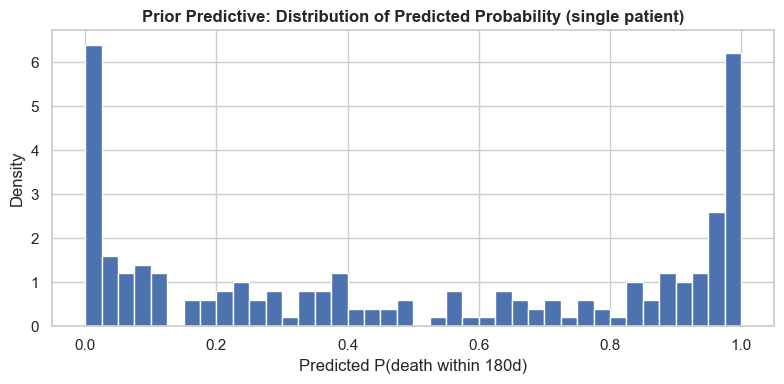

In [124]:
with pm.Model() as blr:
    X_data = pm.Data("X_data", X_train_b)

    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=2)
    betas = pm.Normal("betas", mu=0, sigma=1, shape=n_features)

    # Linear predictor + sigmoid link
    logit_p = intercept + pm.math.dot(X_data, betas)
    p = pm.Deterministic("p", pm.math.invlogit(logit_p))

    # Likelihood
    obs = pm.Bernoulli("obs", p=p, observed=y_train_b)

    prior_pred = pm.sample_prior_predictive(draws=200, random_seed=RANDOM_SEED)

prior_p = prior_pred.prior["p"].values.reshape(-1, len(y_train_b))
sample_probs = prior_p[:500, 0]  # distribution for one patient

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sample_probs, bins=40, edgecolor="white", density=True)
ax.set_title(
    "Prior Predictive: Distribution of Predicted Probability (single patient)",
    fontweight="bold",
)
ax.set_xlabel("Predicted P(death within 180d)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

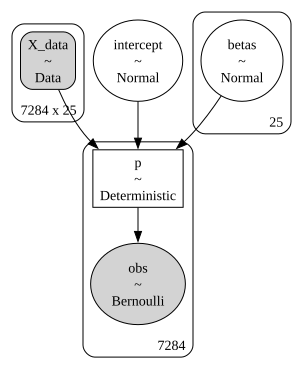

In [125]:
pm.model_to_graphviz(blr)

### 2.4 Model Training (MCMC - NUTS Sampler)

Sampling is special to Bayesian as it's done to quantify uncertainty.
Unlike gradient descent which finds a single best sets of weights, Bayesian samples a thousand sets of weights.

We use the **No-U-Turn Sampler (NUTS)**, a popular gradient-based MCMC (Markov Chain Monte Carlo) algorithm that
efficiently explores high-dimensional posterior distributions. It's the default sampler for PyMC.

**Sampling parameters:**

- `draws=1000`: posterior samples per chain
- `tune=1000`: warm-up/adaptation steps (discarded)
- `chains=4`: independent chains for convergence diagnostics
- `target_accept=0.9`: acceptance rate target (reduces divergences)

In [126]:
with blr:
    trace = pm.sample(
        draws=500,
        tune=1000,
        chains=2,
        cores=1,  # workaround for multiprocessing EOFError; set to max 4 (matching chains) if your environment supports parallel sampling
        target_accept=0.9,
        random_seed=RANDOM_SEED,
        progressbar=True,
    )
print("Sampling complete.")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [intercept, betas]


Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 19 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Sampling complete.


### 2.5 Convergence Diagnostics

**Key convergence diagnostics:**

| Metric | Good threshold | Meaning | Our Results |
|---|---|---|---|
| **R-hat** | < 1.01 | Chains converged to the same distribution | Good |
| **ESS bulk** | > 400 | Effective sample size: independent posterior draws | Good |
| **Divergences** | 0 | Physics error | Good |

In [127]:
summary = az.summary(trace, var_names=["intercept", "betas"])
summary.index = ["intercept"] + FEATURE_NAMES
diag_cols = [c for c in ["mean", "sd", "r_hat", "ess_bulk"] if c in summary.columns]
print(summary[diag_cols].to_string())
print(f"\nDivergences: {trace.sample_stats.diverging.values.sum()}")

                        mean      sd r_hat  ess_bulk
intercept             -0.389   0.074  1.00       599
age                    0.339  0.0283  1.00      1869
meanbp                -0.105   0.028  1.01      1470
bili                   0.159    0.03  1.00      1458
bun                   -0.031  0.0257  1.00      1641
alb                   -0.077  0.0297  1.00      1648
adlsc                  0.299  0.0256  1.00      1686
scoma                  0.586   0.039  1.00      1417
pafi                  -0.074  0.0283  1.01      2109
hrt                    0.103  0.0291  1.00      1839
resp                   0.057   0.027  1.00      2431
temp                  -0.055   0.029  1.00      2033
sod                   -0.043  0.0285  1.01      1862
diabetes              -0.008    0.07  1.00      1838
dzgroup_CHF           -0.469   0.086  1.00      1626
dzgroup_COPD           -0.51   0.096  1.00      1917
dzgroup_Cirrhosis      0.432    0.12  1.00      1942
dzgroup_Colon Cancer   -0.27    0.19  1.00    

### 2.6 Posterior Coefficient Analysis

The **94% Highest Density Interval (HDI)** is the Bayesian analogue of a confidence interval.
In the forest plot below:
* dot: mean of posterior distribution
* line: 94% Highest Density Interval. Effectively saying "We are confident 94% of true weights falls within this line"

**Reading the forest plot**
- If the HDI **excludes 0**: the feature has a credible effect on mortality
- Positive coefficient: higher value means higher mortality probability
- Negative coefficient: higher value means lower mortality probability

Coefficients are on **standardized** continuous features: a coefficient of 1.0 means
a 1-SD increase changes the log-odds by 1.0 (approximately 2.7x odds multiplier).

**Results Interpretation**
- `scoma`: strongest risk factor
- `ca_yes`, `ca_metastatic`: higher risk relative to the `ca_no` (no-cancer) baseline
- `dzgroup_*` coefficients are relative to the `ARF/MOSF w/Sepsis` baseline group
- `dzgroup_Coma`, `bun`, `alb`: less certain (94% interval near 0)

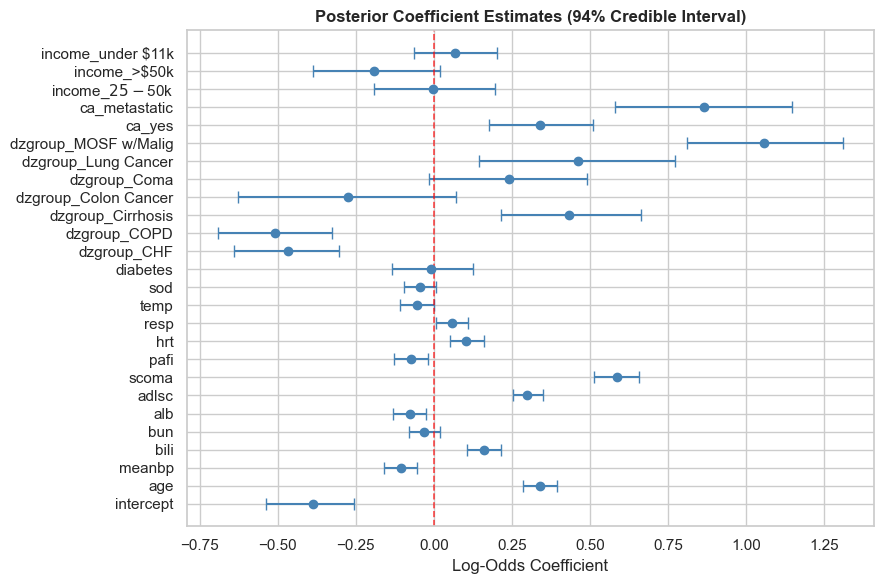

In [128]:
# Manual forest plot using posterior arrays
post_int_flat = trace.posterior["intercept"].values.flatten()
post_b_flat = trace.posterior["betas"].values.reshape(-1, n_features)

all_names = ["intercept"] + FEATURE_NAMES
means_all = [post_int_flat.mean()] + list(post_b_flat.mean(axis=0))
lower_all = [np.percentile(post_int_flat, 3)] + list(
    np.percentile(post_b_flat, 3, axis=0)
)
upper_all = [np.percentile(post_int_flat, 97)] + list(
    np.percentile(post_b_flat, 97, axis=0)
)

fig, ax = plt.subplots(figsize=(9, 6))
y_pos = range(len(all_names))
ax.errorbar(
    means_all,
    y_pos,
    xerr=[
        np.array(means_all) - np.array(lower_all),
        np.array(upper_all) - np.array(means_all),
    ],
    fmt="o",
    color="steelblue",
    ecolor="steelblue",
    capsize=4,
    markersize=6,
    elinewidth=1.5,
)
ax.axvline(0, color="red", linestyle="--", linewidth=1.2, alpha=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(all_names)
ax.set_title(
    "Posterior Coefficient Estimates (94% Credible Interval)", fontweight="bold"
)
ax.set_xlabel("Log-Odds Coefficient")
plt.tight_layout()
plt.show()

In [129]:
# Odds ratios from posterior means
post_betas = trace.posterior["betas"].values.reshape(-1, n_features)
or_mean = np.exp(post_betas.mean(axis=0))
or_lower = np.exp(np.percentile(post_betas, 3, axis=0))
or_upper = np.exp(np.percentile(post_betas, 97, axis=0))

or_df = pd.DataFrame(
    {
        "Feature": FEATURE_NAMES,
        "OR Mean": or_mean.round(3),
        "OR 5.5% ETI": or_lower.round(3),
        "OR 94.5% ETI": or_upper.round(3),
        "Direction": ["Higher risk" if v > 1 else "Lower risk" for v in or_mean],
    }
).sort_values("OR Mean", ascending=False)

print("Odds Ratios (per 1 SD change for continuous features):")
print(or_df.to_string(index=False))

Odds Ratios (per 1 SD change for continuous features):
             Feature  OR Mean  OR 5.5% ETI  OR 94.5% ETI   Direction
dzgroup_MOSF w/Malig    2.879        2.251         3.701 Higher risk
       ca_metastatic    2.377        1.787         3.141 Higher risk
               scoma    1.797        1.667         1.930 Higher risk
 dzgroup_Lung Cancer    1.587        1.154         2.163 Higher risk
   dzgroup_Cirrhosis    1.541        1.239         1.942 Higher risk
                 age    1.404        1.332         1.481 Higher risk
              ca_yes    1.404        1.193         1.664 Higher risk
               adlsc    1.348        1.289         1.415 Higher risk
        dzgroup_Coma    1.272        0.984         1.632 Higher risk
                bili    1.172        1.110         1.239 Higher risk
                 hrt    1.108        1.053         1.172 Higher risk
   income_under $11k    1.071        0.937         1.225 Higher risk
                resp    1.059        1.007      

**Note on the cancer disease groups:** the cancer-related `dzgroup` dummies (`Colon Cancer`, `Lung Cancer`, `MOSF w/Malig`) are collinear with `ca_metastatic` (those patients are all metastatic), so their coefficients are **residual** effects *given* metastatic status. Read them together with `ca_metastatic`, not in isolation.

### 2.7 Posterior Predictive Check

Now that the model has learned from the data, we ask: *can it reproduce what we observed?* This is a **Posterior Predictive Check (PPC)**. There are two checks we can run, from coarse to refined:

1. **Marginal rate**: does the simulated overall mortality rate match the observed rate? This is necessary but weak: per-patient errors can cancel out in the average.
2. **Calibration (reliability diagram)**: among patients the model assigns ~*x*% risk, do ~*x*% actually die?

For brevity we're doing a simple PPC (1).

**Result**: the simulated overall rate (~46.8%) matches the observed died:survived ratio (4265:4840).

Sampling: [obs]


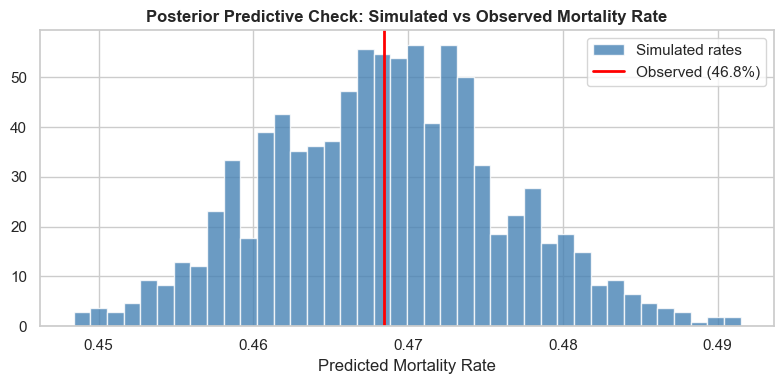

In [130]:
with blr:
    ppc = pm.sample_posterior_predictive(trace, random_seed=RANDOM_SEED)

# Compare simulated vs observed mortality rate
sim_rates = (
    ppc.posterior_predictive["obs"].values.reshape(-1, len(y_train_b)).mean(axis=1)
)
obs_rate = y_train_b.mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    sim_rates,
    bins=40,
    color="steelblue",
    edgecolor="white",
    density=True,
    alpha=0.8,
    label="Simulated rates",
)
ax.axvline(obs_rate, color="red", linewidth=2, label=f"Observed ({obs_rate:.1%})")
ax.set_title(
    "Posterior Predictive Check: Simulated vs Observed Mortality Rate",
    fontweight="bold",
)
ax.set_xlabel("Predicted Mortality Rate")
ax.legend()
plt.tight_layout()
plt.show()

### 2.8 Model Evaluation & Benchmark Comparison

We evaluate the model on the held-out test set (20% of data) using **ROC-AUC**,
and compare against the legacy SUPPORT model benchmark (`surv6m`).

**Baselines (from Part 2, Section 14):**
- SUPPORT model (`surv6m`): AUC approximately 0.787
- Physician estimate (`prg6m`): AUC approximately 0.756
- APACHE III (`aps`): AUC approximately 0.658

In [131]:
# Compute posterior predictive probabilities on the test set
post_intercept = trace.posterior["intercept"].values.flatten()
post_betas_all = trace.posterior["betas"].values.reshape(-1, n_features)

# logit_p for each test patient: shape (n_posterior_samples, n_test)
logits_test = post_intercept[:, None] + post_betas_all @ X_test_b.T
probs_test = sigmoid(logits_test)

pred_mean = probs_test.mean(axis=0)
pred_lower = np.percentile(probs_test, 3, axis=0)
pred_upper = np.percentile(probs_test, 97, axis=0)

# Standard comparison vs the legacy benchmarks
benchmark_preds = get_benchmark_preds(df_bayes, idx_test_b)
auc_bayes = roc_auc_score(y_test_b, pred_mean)
print(
    auc_table(y_test_b, {"Bayesian LR (linear)": pred_mean}, benchmark_preds).to_string(
        index=False
    )
)

               model   AUC
    SUPPORT (surv6m) 0.790
Bayesian LR (linear) 0.751
   Physician (prg6m) 0.749
    APACHE III (aps) 0.663


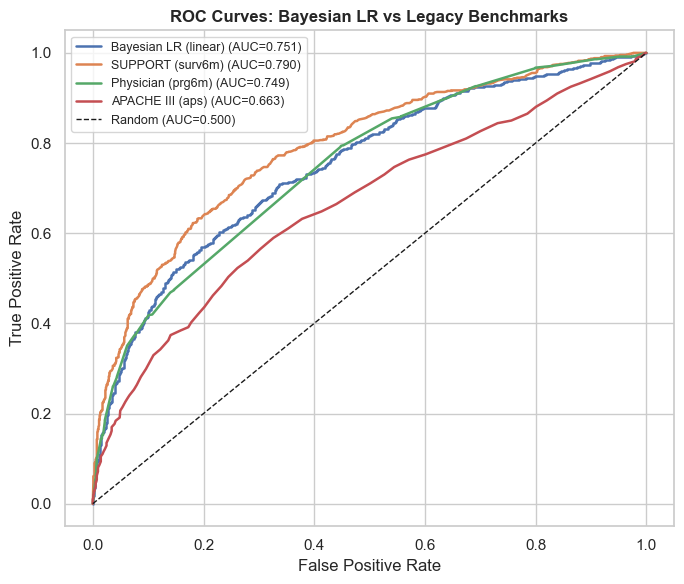

In [132]:
plot_roc(
    y_test_b,
    {"Bayesian LR (linear)": pred_mean, **benchmark_preds},
    title="ROC Curves: Bayesian LR vs Legacy Benchmarks",
)
plt.tight_layout()
plt.show()

### 2.9 Nonlinear Modeling: B-Splines

The main BLR treats every continuous feature **linearly**. But several day-3 vitals are clinically *U-shaped* in mortality (both extremes are dangerous), and the liver marker `bili` rises non-linearly.

Here we refit the model with **cubic B-splines** on the most non-linear features, keep everything else linear, and check whether it improves held-out AUC / calibration over the linear baseline.

#### 2.9.1 Which features are non-linear?

For each candidate we split patients into **low** (<=10th pct), **mid** (45-55th pct), and **high** (>=90th pct) by the feature value and compare the observed 180-day mortality in each group:

- **U-shaped**: both low and high mortality exceed the middle (extremes are deadlier than the center).
- **Monotonic**: mortality rises (or falls) steadily from low to high.

We spline the **4 most non-linear** features and leave the rest linear:

- `sod`, `temp`, `resp` — symmetric **U-shapes** (their linear coefficients are approximately 0 because the two arms cancel).
- `bili` — **monotonic, flat-then-steep** (also heavily right-skewed per EDA); included to test non-linearity beyond U-shapes.

Honorable mentions left linear: `meanbp` and `hrt` are real U's but **one-arm-dominated**, so their linear terms already capture most of the signal. `bun` is essentially flat and `alb` is cleanly monotonic-decreasing.

In [133]:
# Model-free non-linearity screen: observed mortality at low / mid / high deciles
CANDIDATES = ["sod", "temp", "resp", "bili", "meanbp", "hrt", "bun", "alb"]
rows = []
for f in CANDIDATES:
    x = df_model[f].values
    q = np.quantile(x, [0.10, 0.45, 0.55, 0.90])
    lo = y_bayes[x <= q[0]].mean()
    mid = y_bayes[(x >= q[1]) & (x <= q[2])].mean()
    hi = y_bayes[x >= q[3]].mean()
    if lo > mid and hi > mid:
        shape = "U-shape"
    elif (lo < mid < hi) or (lo > mid > hi):
        shape = "monotonic"
    else:
        shape = "mixed/flat"
    rows.append([f, lo, mid, hi, lo - mid, hi - mid, shape])

nonlin = pd.DataFrame(
    rows, columns=["feature", "lo", "mid", "hi", "lo-mid", "hi-mid", "shape"]
)
print(nonlin.to_string(index=False))

feature    lo   mid    hi  lo-mid  hi-mid     shape
    sod 0.536 0.418 0.526   0.117   0.108   U-shape
   temp 0.533 0.444 0.530   0.089   0.087   U-shape
   resp 0.482 0.438 0.535   0.044   0.097   U-shape
   bili 0.446 0.457 0.564  -0.011   0.107 monotonic
 meanbp 0.578 0.431 0.473   0.147   0.042   U-shape
    hrt 0.437 0.449 0.546  -0.012   0.097 monotonic
    bun 0.481 0.474 0.488   0.007   0.014   U-shape
    alb 0.519 0.476 0.369   0.042  -0.108 monotonic


In [134]:
# 3 U-shaped + bili (monotonic-nonlinear)
SPLINE_FEATURES = ["sod", "temp", "resp", "bili"]

spline_idx = [FEATURE_NAMES.index(f) for f in SPLINE_FEATURES]
keep = [i for i in range(n_features) if i not in spline_idx]
linear_names = [FEATURE_NAMES[i] for i in keep]
X_lin_train = X_train_b[:, keep]
X_lin_test = X_test_b[:, keep]

spline_train, spline_test, spline_info = {}, {}, {}
for f in SPLINE_FEATURES:
    xtr = df_model[f].values[idx_train_b]
    xte = df_model[f].values[idx_test_b]
    lo_b = float(df_model[f].min())
    hi_b = float(df_model[f].max())
    dm = dmatrix(
        "bs(x, df=5, degree=3, include_intercept=False, "
        "lower_bound=lo_b, upper_bound=hi_b)",
        {"x": xtr, "lo_b": lo_b, "hi_b": hi_b},
        return_type="matrix",
    )
    spline_train[f] = np.asarray(dm)
    spline_info[f] = dm.design_info
    spline_test[f] = np.asarray(build_design_matrices([dm.design_info], {"x": xte})[0])

print(f"Linear features ({len(linear_names)}): {linear_names}")
print(f"Spline features: {SPLINE_FEATURES}")
print(
    "Basis columns per spline feature: "
    f"{[spline_train[f].shape[1] for f in SPLINE_FEATURES]}"
)

Linear features (21): ['age', 'meanbp', 'bun', 'alb', 'adlsc', 'scoma', 'pafi', 'hrt', 'diabetes', 'dzgroup_CHF', 'dzgroup_COPD', 'dzgroup_Cirrhosis', 'dzgroup_Colon Cancer', 'dzgroup_Coma', 'dzgroup_Lung Cancer', 'dzgroup_MOSF w/Malig', 'ca_yes', 'ca_metastatic', 'income_$25-$50k', 'income_>$50k', 'income_under $11k']
Spline features: ['sod', 'temp', 'resp', 'bili']
Basis columns per spline feature: [6, 6, 6, 6]


In [ ]:
with pm.Model() as blr_spline:
    intercept = pm.Normal("intercept", mu=0, sigma=2)
    betas_lin = pm.Normal("betas_lin", mu=0, sigma=1, shape=X_lin_train.shape[1])
    eta = intercept + pm.math.dot(X_lin_train, betas_lin)

    # One coefficient vector per spline feature; Normal(0, 1) acts as a mild
    # smoothness prior (a random-walk prior would enforce more smoothness if needed).
    for f in SPLINE_FEATURES:
        coef = pm.Normal(f"spline_{f}", mu=0, sigma=1, shape=spline_train[f].shape[1])
        eta = eta + pm.math.dot(spline_train[f], coef)

    p = pm.Deterministic("p", pm.math.invlogit(eta))
    pm.Bernoulli("obs", p=p, observed=y_train_b)

    trace_spline = pm.sample(
        draws=500,
        tune=1000,
        chains=2,
        cores=1,  # workaround for multiprocessing EOFError; set to max 4 (matching chains) if your environment supports parallel sampling
        target_accept=0.9,
        random_seed=RANDOM_SEED,
        progressbar=True,
    )

# Convergence sanity check (same thresholds as Section 12)
sp_vars = ["intercept", "betas_lin"] + [f"spline_{f}" for f in SPLINE_FEATURES]
sp_summary = az.summary(trace_spline, var_names=sp_vars)
print(
    f"Max r_hat: {float(sp_summary['r_hat'].max()):.3f}  |  "
    f"Min ess_bulk: {float(sp_summary['ess_bulk'].min()):.0f}  |  "
    f"Divergences: {int(trace_spline.sample_stats.diverging.values.sum())}"
)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [intercept, betas_lin, spline_sod, spline_temp, spline_resp, spline_bili]


In [ ]:
# Reconstruct held-out test probabilities from the spline-model posterior
sp_intercept = trace_spline.posterior["intercept"].values.flatten()
sp_betas = trace_spline.posterior["betas_lin"].values.reshape(-1, X_lin_test.shape[1])

logits_sp = sp_intercept[:, None] + sp_betas @ X_lin_test.T
for f in SPLINE_FEATURES:
    c = trace_spline.posterior[f"spline_{f}"].values.reshape(
        -1, spline_test[f].shape[1]
    )
    logits_sp = logits_sp + c @ spline_test[f].T
probs_sp_test = sigmoid(logits_sp)
pred_sp_mean = probs_sp_test.mean(axis=0)

# Standard comparison via the shared helpers (linear baseline + spline + benchmarks)
auc_spline = roc_auc_score(y_test_b, pred_sp_mean)
model_preds = {
    "Bayesian LR (linear)": pred_mean,
    "Bayesian LR (spline)": pred_sp_mean,
}
print(auc_table(y_test_b, model_preds, benchmark_preds).to_string(index=False))
print(
    f"\nBrier  linear={brier_score(y_test_b, pred_mean):.3f}  "
    f"spline={brier_score(y_test_b, pred_sp_mean):.3f}"
)

plot_roc(
    y_test_b,
    {**model_preds, **benchmark_preds},
    title="ROC: Linear vs B-spline vs Benchmarks",
)
plt.tight_layout()
plt.show()

In [ ]:
# Partial-effect plots: the centered log-odds contribution of each spline feature,
# with its 94% credible band. This is where the U / non-linear shapes become visible.
fig, axes = plt.subplots(1, len(SPLINE_FEATURES), figsize=(4 * len(SPLINE_FEATURES), 4))
for ax, f in zip(axes, SPLINE_FEATURES):
    xtr = df_model[f].values[idx_train_b]
    grid = np.linspace(np.percentile(xtr, 1), np.percentile(xtr, 99), 100)
    Bg = np.asarray(build_design_matrices([spline_info[f]], {"x": grid})[0])
    c = trace_spline.posterior[f"spline_{f}"].values.reshape(-1, Bg.shape[1])

    contrib = Bg @ c.T  # (grid, draws)
    contrib = contrib - contrib.mean(axis=0, keepdims=True)  # center for readability
    mean = contrib.mean(axis=1)
    lo = np.percentile(contrib, 3, axis=1)
    hi = np.percentile(contrib, 97, axis=1)

    ax.fill_between(grid, lo, hi, color="steelblue", alpha=0.25)
    ax.plot(grid, mean, color="steelblue", linewidth=2)
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    # rug of the training values to show where the data (and the curve) is trustworthy
    ax.plot(xtr, np.full_like(xtr, lo.min()), "|", color="grey", alpha=0.05)
    ax.set_title(f, fontweight="bold")
    ax.set_xlabel(f"{f} (raw)")
axes[0].set_ylabel("Centered log-odds contribution")
fig.suptitle(
    "B-spline partial effects (U-shapes for sod/temp/resp; flat-then-steep for bili)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

#### 2.9.2 Interpretation

**Spline Shapes:** the partial-effect curves match the 2.9.1 screen. `sod`, `temp`, and `resp` bend into the expected **U** (risk lowest near the physiological mid-range and rising at both extremes), while `bili` is **flat at low values then climbs**, the monotonic-nonlinear shape a single linear coefficient could never express.

**Gain is modest:** AUC moved **0.751 to 0.754 (+0.003)** and Brier **0.201 to 0.200 (-0.001)**. This is expected as these four features have small marginal effects, so even modeling their shape correctly nudges overall discrimination only slightly.

**Takeaway:** Nonlinear modeling is inefficient for the current dataset and not worth the increase cost and complexity.

**Scope caveat:** `meanbp`/`hrt` were deliberately left linear (one-arm-dominated U's whose linear terms already capture most of the signal). `bun` is essentially flat and `alb` is cleanly monotonic-decreasing.

### 2.10 Interpretability: Demo With Three Example Patients

The section demonstrates the biggest advantage of using Bayesian in the clinical setting - interpretability

- **Calibrated confidence.** Every prediction is a *full posterior distribution* over
  P(death)
- **Local explainability.**:  we can look at contributions per feature and 
  see exactly which clinical findings drove that patient's risk up or down.

We illustrate both on three representative patients: a clear high-risk case, a
clear low-risk case, and the *most uncertain* borderline case.

In [ ]:
ci_width = pred_upper - pred_lower

# Pick three representative held-out patients (transparent, archetype-based selection).
died = np.where(y_test == 1)[0]
surv = np.where(y_test == 0)[0]
mid = np.where((pred_mean > 0.4) & (pred_mean < 0.6))[0]
patients = {
    "High-risk (died)": int(died[np.argmax(pred_mean[died])]),
    "Low-risk (survived)": int(surv[np.argmin(pred_mean[surv])]),
    "Borderline (most uncertain)": int(mid[np.argmax(ci_width[mid])]),
}

rows = []
for label, col in patients.items():
    r = df.iloc[idx_test[col]]
    rows.append(
        {
            "Patient": label,
            "P(death) mean": round(float(pred_mean[col]), 3),
            "94% CI": f"[{pred_lower[col]:.2f}, {pred_upper[col]:.2f}]",
            "CI width": round(float(ci_width[col]), 3),
            "Actual": "died" if y_test[col] == 1 else "survived",
            "dzclass": r["dzclass"],
            "ca": r["ca"],
            "age": round(float(r["age"])),
            "meanbp": round(float(r["meanbp"])),
            "scoma": round(float(r["scoma"])),
            "bili": round(float(r["bili"]), 1),
        }
    )
patient_df = pd.DataFrame(rows)
print("Representative patients:")
print(patient_df.to_string(index=False))

Representative patients:
                    Patient  P(death) mean       94% CI  CI width   Actual            dzclass         ca  age  meanbp  scoma   bili
           High-risk (died)          0.977 [0.97, 0.99]     0.018     died           ARF/MOSF metastatic   68      45     89  1.000
        Low-risk (survived)          0.095 [0.08, 0.12]     0.043 survived COPD/CHF/Cirrhosis         no   35     138      0  0.800
Borderline (most uncertain)          0.596 [0.50, 0.69]     0.197     died COPD/CHF/Cirrhosis         no   42      67      0 30.600


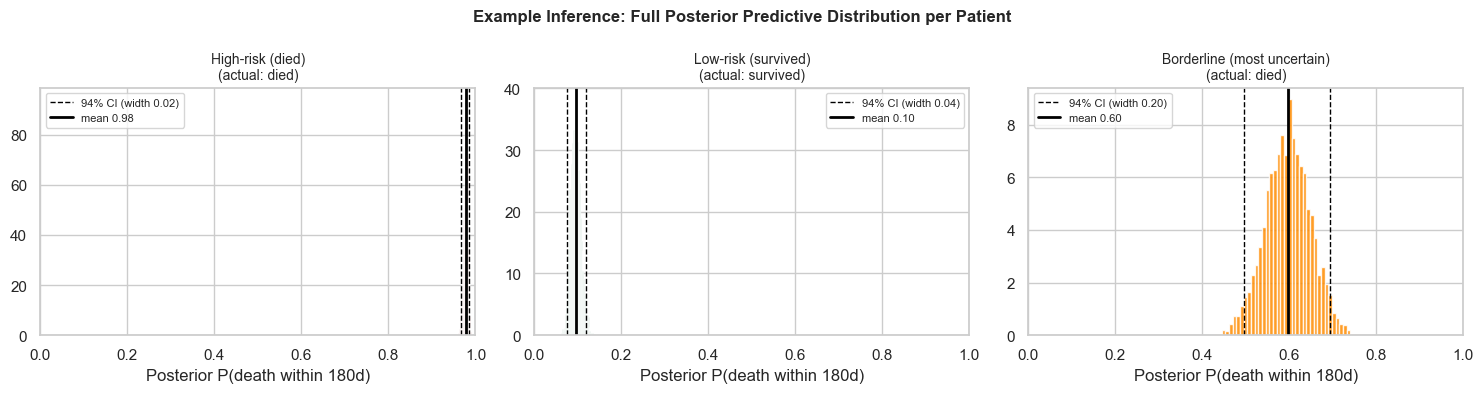

In [ ]:
# Confidence: the full posterior predictive distribution of P(death) for each patient.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {
    "High-risk (died)": "firebrick",
    "Low-risk (survived)": "seagreen",
    "Borderline (most uncertain)": "darkorange",
}
for ax, (label, col) in zip(axes, patients.items()):
    samples = probs_test[:, col]
    ax.hist(
        samples,
        bins=40,
        color=colors[label],
        edgecolor="white",
        density=True,
        alpha=0.85,
    )
    ax.axvline(pred_lower[col], color="black", linestyle="--", linewidth=1)
    ax.axvline(
        pred_upper[col],
        color="black",
        linestyle="--",
        linewidth=1,
        label=f"94% CI (width {ci_width[col]:.2f})",
    )
    ax.axvline(
        pred_mean[col], color="black", linewidth=2, label=f"mean {pred_mean[col]:.2f}"
    )
    ax.set_title(
        f"{label}\n(actual: {'died' if y_test[col] == 1 else 'survived'})", fontsize=10
    )
    ax.set_xlabel("Posterior P(death within 180d)")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
fig.suptitle(
    "Example Inference: Full Posterior Predictive Distribution per Patient",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

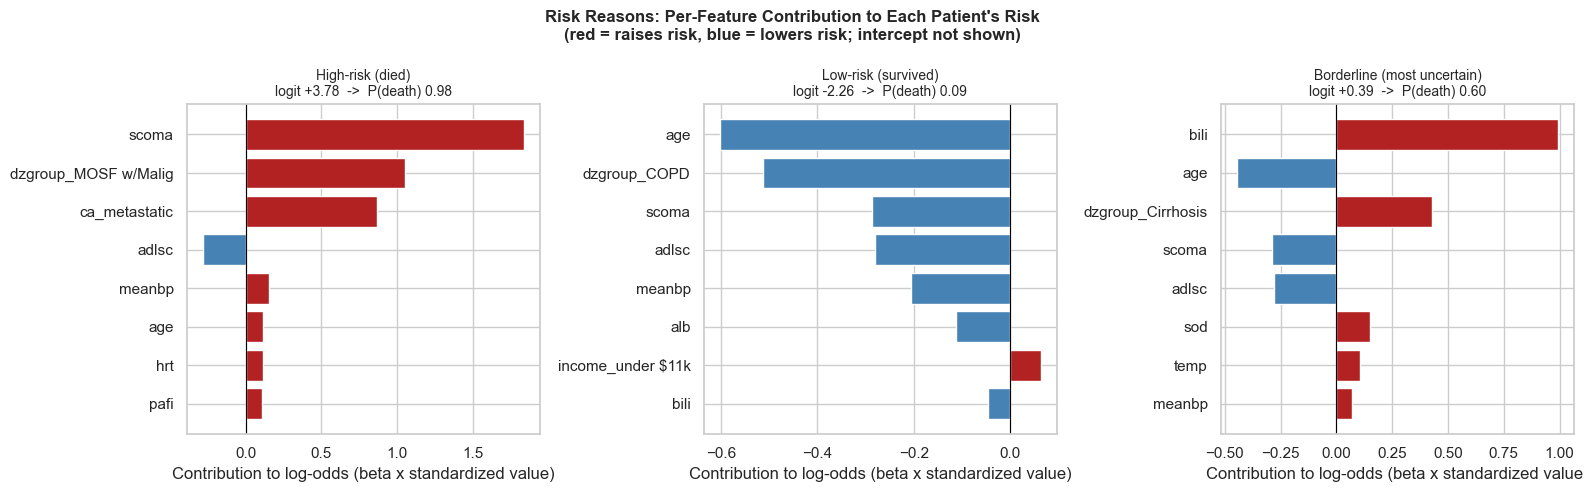

In [ ]:
# Explainability: per-prediction "reason codes" - decompose each logit into feature contributions.
beta_mean = post_b_flat.mean(axis=0)
int_mean = post_int_flat.mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (label, col) in zip(axes, patients.items()):
    contrib = beta_mean * X_test[col]
    order = np.argsort(np.abs(contrib))[::-1][:8]  # 8 largest drivers
    names = [FEATURE_NAMES[i] for i in order][::-1]
    vals = contrib[order][::-1]
    bar_colors = ["firebrick" if v > 0 else "steelblue" for v in vals]
    ax.barh(names, vals, color=bar_colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    logit = int_mean + contrib.sum()
    ax.set_title(
        f"{label}\nlogit {logit:+.2f}  ->  P(death) {sigmoid(logit):.2f}", fontsize=10
    )
    ax.set_xlabel("Contribution to log-odds (beta x standardized value)")
fig.suptitle(
    "Risk Reasons: Per-Feature Contribution to Each Patient's Risk\n"
    "(red = raises risk, blue = lowers risk; intercept not shown)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

- **The posterior predictive distribution.** The high-risk patient (deep coma, fully
  ADL-dependent) and the low-risk patient (young, no cancer, normal vitals) both get
  near-certain predictions with near zero variance. The borderline patient, lands near 50% with a wide
  interval, the model correctly identifying uncertainty." A frequentist model
  would report all three as a single probability and hide that the third is essentially a
  coin flip; the Bayesian posterior makes that uncertainty visible.

- **The Risk Reason allows prediction to be explainable.** Each bar shows how much a feature
  pushed that specific patient's log-odds up (red) or down (blue): the coma score and
  functional dependency drive the high-risk case; absence of cancer and youth protect the
  low-risk one; and for the borderline patient we see one extreme lab nearly
  cancel the protective no-cancer status.

## Section 3: Inference vs. Prediction Alignment (ML-Q3) <a id="p3-s3"></a>

This ties the two halves together. The inference side (RQ1 and RQ2) ranked variables
by how strongly they are associated with mortality (odds ratios). The prediction side
ranks them by how much they drive the random forest (feature importance). ML-Q3 lays
the two rankings side by side. Where they agree the finding is stronger; where they
disagree, that is itself worth a look.

In [ ]:
importance = pd.Series(
    best_rf.named_steps["classifier"].feature_importances_,
    index=preprocessed_feature_names,
).sort_values(ascending=False)
importance.head(10).round(4)

In [ ]:
# the shared day-3 physiology variables: inference (RQ2) vs prediction (importance)
compare_vars = ["meanbp", "wblc", "crea", "alb", "bili"]

# map raw variable names to preprocessed names (numeric features are prefixed with num__)
compare_vars_preprocessed = [f"num__{v}" for v in compare_vars]

bridge = pd.DataFrame(
    {
        "inference_OR": [phys_table.loc[v, "OR"] for v in compare_vars],
        "inference_p": [phys_table.loc[v, "p_value"] for v in compare_vars],
        "rf_importance": [
            float(importance.get(v_pre, float("nan")))
            for v_pre in compare_vars_preprocessed
        ],
    },
    index=compare_vars,
).round(4)
bridge

### Where the two views line up

The two rankings agreed only in part. With avtisst removed as a leak, the prediction
side spread its importance across age, the ADL score (adlsc), white count, coma score,
mean blood pressure, and a broad set of day-3 vitals, rather than leaning on any single
dominant variable. The inference side put disease group out front (RQ1), with physiology
adding a small increment (RQ2). Both point at overall severity and physiology mattering,
but disease group, which carried the strongest inference signal, did not dominate the
prediction importance.

Among the shared physiology variables the overlap was loose: some that were significant
in the inference model carried little random-forest importance, and one that was not
significant ranked higher, so the two lenses do not map one to one. Severity and
physiology matter in both views, but no single variable runs the table in both. An odds
ratio and a feature importance answer different questions, and that is the reason not to
treat them as the same number.